<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/El_Algoritmo_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Backpropagation: Cómo Aprenden las Redes Neuronales**
## **Implementación manual de MLP con NumPy: del XOR a la práctica con scikit-learn**

## Índice

1. **Introducción: El Problema XOR**
   * ¿Qué es XOR y por qué es importante?
   * Visualización del problema: puntos no separables linealmente
   * El límite del Perceptrón Simple

2. **Anatomía de una Red Neuronal Multicapa (MLP)**
   * Estructura: Entrada (2) → Oculta (4) → Salida (1)
   * Pesos, sesgos y conexiones
   * La función de activación Sigmoide: añadiendo no-linealidad

3. **Forward Propagation: El Camino de Ida**
   * Flujo de información a través de las capas
   * Cálculo de activaciones capa por capa
   * Obteniendo la predicción final

4. **La Función de Coste (Loss Function)**
   * ¿Qué estamos tratando de minimizar?
   * Error Cuadrático Medio (MSE)
   * Interpretación geométrica del error

5. **Backpropagation: El Motor del Aprendizaje**
   * La Regla de la Cadena aplicada a redes neuronales
   * Calculando gradientes: ¿cuánto contribuye cada peso al error?
   * Propagando el error hacia atrás

6. **Descenso del Gradiente**
   * Actualizando pesos en la dirección correcta
   * El Learning Rate: equilibrio entre velocidad y estabilidad
   * Iteración tras iteración: el proceso de entrenamiento

7. **Implementación desde Cero con NumPy**
   * Inicialización de pesos y sesgos
   * Código completo del algoritmo
   * Entrenamiento: observando la convergencia
   * Visualización de la curva de pérdida

8. **Validación: ¿Aprendió correctamente?**
   * Evaluación de las predicciones
   * Visualización del espacio de decisión aprendido

9. **Solución Profesional con Scikit-Learn**
   * MLPClassifier: la misma red en pocas líneas
   * Comparación de resultados
   * Cuándo usar implementación manual vs. librería

10. **Conclusiones y Próximos Pasos**
    * Recapitulación: el poder de las capas ocultas
    * Limitaciones de las MLP clásicas
    * Camino hacia redes más profundas (Deep Learning)

---

# 1. Introducción: El Problema XOR

## ¿Qué es XOR y por qué es importante?

XOR (eXclusive OR, "O exclusivo" en español) es una operación lógica fundamental que devuelve `True` (1) únicamente cuando sus dos entradas son **diferentes**, y `False` (0) cuando son iguales. Es decir, la salida es verdadera si una entrada u otra es verdadera, pero **no ambas a la vez**.

Veamos su tabla de verdad:

| x₁ | x₂ | XOR (salida) |
|----|----|--------------|
| 0  | 0  | 0            |
| 0  | 1  | 1            |
| 1  | 0  | 1            |
| 1  | 1  | 0            |

A simple vista, XOR parece un problema trivial. Sin embargo, este sencillo operador lógico tiene una **importancia histórica crucial** en el desarrollo de las redes neuronales artificiales.

En 1969, Marvin Minsky y Seymour Papert publicaron el libro *"Perceptrons"*, donde demostraron matemáticamente que **un perceptrón simple (una única neurona) no puede resolver el problema XOR**. Esta demostración fue tan influyente que provocó lo que se conoce como el "invierno de la IA": un período de más de una década donde la financiación y el interés en redes neuronales prácticamente desaparecieron.

La solución a este problema llegaría años después con las **redes neuronales multicapa** y el algoritmo de **backpropagation**, que es precisamente lo que aprenderemos en este artículo.

## Visualización: dos fronteras lineales son necesarias

Para entender por qué XOR es tan problemático, visualicemos los cuatro puntos de datos en un espacio 2D:

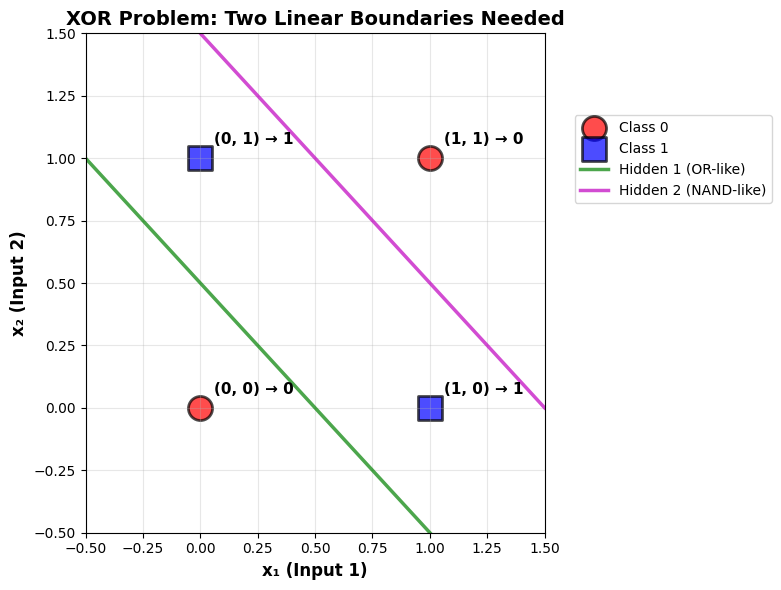

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([0, 1, 1, 0])

# Create visualization
plt.figure(figsize=(8, 6))

# Plot points with different colors for each class
colors = ['red' if label == 0 else 'blue' for label in y]
markers = ['o' if label == 0 else 's' for label in y]

for i, (point, color, marker) in enumerate(zip(X, colors, markers)):
    plt.scatter(point[0], point[1], c=color, marker=marker, s=300,
                edgecolors='black', linewidths=2, alpha=0.7,
                label=f'Class {y[i]}' if i < 2 else '')

# Add labels to each point
for i, point in enumerate(X):
    plt.annotate(f'({point[0]}, {point[1]}) → {y[i]}',
                 xy=point, xytext=(10, 10),
                 textcoords='offset points', fontsize=11, fontweight='bold')

# Draw two linear boundaries (what hidden neurons learn)
x_line = np.linspace(-0.5, 1.5, 100)

# First boundary: OR-like (separates (0,0) from the rest)
y_line1 = -x_line + 0.5
plt.plot(x_line, y_line1, 'g-', linewidth=2.5, alpha=0.7, label='Hidden 1 (OR-like)')

# Second boundary: NAND-like (separates (1,1) from the rest)
y_line2 = -x_line + 1.5
plt.plot(x_line, y_line2, 'm-', linewidth=2.5, alpha=0.7, label='Hidden 2 (NAND-like)')

plt.xlabel('x₁ (Input 1)', fontsize=12, fontweight='bold')
plt.ylabel('x₂ (Input 2)', fontsize=12, fontweight='bold')
plt.title('XOR Problem: Two Linear Boundaries Needed', fontsize=14, fontweight='bold')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 0.85), fontsize=10)
plt.tight_layout()
plt.show()

En la gráfica podemos observar algo fundamental: aunque **una sola línea recta no puede separar** los puntos rojos (clase 0) de los azules (clase 1), **dos líneas rectas sí pueden resolver el problema**:

- **La línea verde (Hidden 1)**: Actúa como un operador OR, separando el punto (0,0) del resto.
- **La línea magenta (Hidden 2)**: Actúa como un operador NAND (NOT AND), separando el punto (1,1) del resto.

Cuando **combinamos** ambas fronteras lineales en una capa oculta, la red puede aprender una representación donde XOR se vuelve separable. Este es el insight clave: la capa oculta transforma el espacio de entrada en un nuevo espacio donde el problema ya no es linealmente inseparable.

Cada neurona de la capa oculta aprende una de estas fronteras lineales, y la neurona de salida aprende a combinar sus respuestas para producir la clasificación correcta. En lugar de intentar resolver XOR directamente con una línea, la red lo descompone en subproblemas más simples.

## El límite del Perceptrón Simple y la necesidad de capas ocultas

En nuestro artículo anterior sobre el perceptrón, vimos cómo una única neurona puede resolver perfectamente los problemas AND y OR. La razón es simple: estos problemas son **linealmente separables**. Un perceptrón aprende una función de la forma:

**salida = sigmoide(w₁·x₁ + w₂·x₂ + b)**

Esta ecuación define una **línea recta** (o más precisamente, un hiperplano en dimensiones superiores) que divide el espacio en dos regiones. Como acabamos de ver en la visualización, XOR necesita **al menos dos líneas** para ser resuelto correctamente.

En el artículo previo también construimos manualmente una red neuronal con arquitectura **2:2:1** (2 entradas → 2 neuronas ocultas → 1 salida) donde *hardcodeamos* los pesos y sesgos para resolver XOR. Esa solución funcionaba porque manualmente configuramos dos neuronas: una para cada frontera de decisión. Sin embargo, tenía **dos limitaciones críticas**:

1. **No es una solución aprendida:** Tuvimos que calcular manualmente los valores exactos de los pesos porque conocíamos de antemano la estructura lógica del problema (XOR se puede descomponer en operaciones OR y NAND).

2. **Inestabilidad durante el entrenamiento:** Con solo 2 neuronas ocultas, el espacio de soluciones es extremadamente estrecho. Si intentáramos entrenar esa red desde pesos aleatorios usando backpropagation, el algoritmo tendría **grandes dificultades para converger** hacia una solución válida. El paisaje de error es complejo y tiene muchos mínimos locales problemáticos.

**¿Cuál es la solución?** Usar una arquitectura con **más neuronas en la capa oculta**. En este artículo trabajaremos con una arquitectura **2:4:1** (2 entradas → **4 neuronas ocultas** → 1 salida).

¿Por qué 4 neuronas cuando solo necesitamos 2 fronteras? Esta configuración proporciona:
- **Mayor flexibilidad representacional:** La red puede aprender múltiples combinaciones de características y no está restringida a una solución específica.
- **Espacio de optimización más suave:** El algoritmo de descenso del gradiente encuentra caminos más estables hacia la solución. Las neuronas "extra" actúan como redundancia que facilita el aprendizaje.
- **Robustez durante el entrenamiento:** Si una neurona se queda atascada en un mal estado durante las primeras iteraciones, las otras pueden compensar y guiar el aprendizaje.

Con esta arquitectura ampliada y el algoritmo de **backpropagation**, nuestra red será capaz de **aprender completamente por sí misma** a resolver XOR, sin que tengamos que especificar manualmente ni un solo peso. El modelo descubrirá automáticamente las fronteras de decisión necesarias (probablemente aprendiendo algo similar a las líneas verde y magenta que vimos, más otras transformaciones auxiliares).

En las próximas secciones diseccionaremos exactamente cómo funciona este proceso de aprendizaje automático.

---

# 2. Anatomía de una Red Neuronal Multicapa (MLP)

## Estructura: Entrada (2) → Oculta (4) → Salida (1)

Una Red Neuronal Multicapa (MLP, del inglés *Multilayer Perceptron*) es una arquitectura que consta de varias capas de neuronas conectadas entre sí. A diferencia del perceptrón simple que solo tiene una capa de entrada y una neurona de salida, una MLP introduce **capas ocultas** (*hidden layers*) entre la entrada y la salida.

Para resolver XOR, utilizaremos la siguiente arquitectura:

```
    INPUT LAYER      HIDDEN LAYER        OUTPUT LAYER
    
       x₁  ◯────────────◯ h₁
                    ╱   ╱ ╲   ╲
                   ╱   ╱   ╲   ╲
                  ╱   ╱     ╲   ╲              ◯ ŷ
                 ╱   ◯ h₂    ╲                (output)
       x₂  ◯────────────      ╲   ╱
                 ╲   ◯ h₃     ╱  ╱
                  ╲   ╲      ╱  ╱
                   ╲   ╲    ╱  ╱
                    ╲   ╲  ╱  ╱
                     ╲   ◯ h₄
                     
    (2 neuronas)   (4 neuronas)    (1 neurona)
```

Desglosemos cada componente:

**Capa de Entrada (Input Layer):**
- 2 neuronas que reciben las entradas x₁ y x₂
- No realizan ningún cálculo, simplemente pasan los valores a la siguiente capa
- En nuestro caso XOR: x₁ ∈ {0, 1} y x₂ ∈ {0, 1}

**Capa Oculta (Hidden Layer):**
- 4 neuronas (h₁, h₂, h₃, h₄)
- Aquí es donde ocurre la "magia": cada neurona aprende a detectar patrones específicos en los datos
- Esta capa transforma el espacio de entrada en una representación donde XOR se vuelve separable
- Cada neurona está **completamente conectada** (*fully connected*) con todas las neuronas de la capa anterior

**Capa de Salida (Output Layer):**
- 1 neurona que produce la predicción final ŷ
- Combina la información procesada por la capa oculta
- Produce un valor entre 0 y 1 que interpretaremos como la probabilidad de que la salida sea 1

Visualicemos esta arquitectura con código Python:

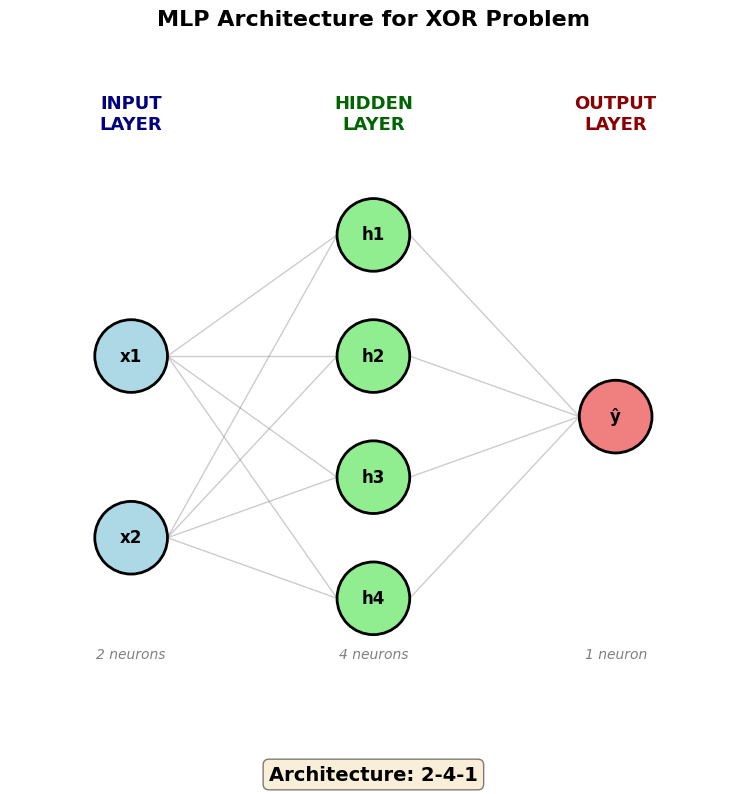

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 8))

# Layer positions
input_x = 1
hidden_x = 3
output_x = 5

# Neuron positions
input_y = [3, 1.5]
hidden_y = [4, 3, 2, 1]
output_y = [2.5]

# Draw neurons
neuron_radius = 0.3

# Input layer
for i, y in enumerate(input_y):
    circle = plt.Circle((input_x, y), neuron_radius, color='lightblue',
                        ec='black', linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(input_x, y, f'x{i+1}', ha='center', va='center',
            fontsize=12, fontweight='bold', zorder=4)

# Hidden layer
for i, y in enumerate(hidden_y):
    circle = plt.Circle((hidden_x, y), neuron_radius, color='lightgreen',
                        ec='black', linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(hidden_x, y, f'h{i+1}', ha='center', va='center',
            fontsize=12, fontweight='bold', zorder=4)

# Output layer
circle = plt.Circle((output_x, output_y[0]), neuron_radius, color='lightcoral',
                    ec='black', linewidth=2, zorder=3)
ax.add_patch(circle)
ax.text(output_x, output_y[0], 'ŷ', ha='center', va='center',
        fontsize=12, fontweight='bold', zorder=4)

# Draw connections (weights)
# Input to Hidden
for i, y_in in enumerate(input_y):
    for j, y_hid in enumerate(hidden_y):
        ax.plot([input_x + neuron_radius, hidden_x - neuron_radius],
                [y_in, y_hid], 'gray', alpha=0.4, linewidth=1, zorder=1)

# Hidden to Output
for y_hid in hidden_y:
    ax.plot([hidden_x + neuron_radius, output_x - neuron_radius],
            [y_hid, output_y[0]], 'gray', alpha=0.4, linewidth=1, zorder=1)

# Layer labels
ax.text(input_x, 5, 'INPUT\nLAYER', ha='center', va='center',
        fontsize=13, fontweight='bold', color='navy')
ax.text(hidden_x, 5, 'HIDDEN\nLAYER', ha='center', va='center',
        fontsize=13, fontweight='bold', color='darkgreen')
ax.text(output_x, 5, 'OUTPUT\nLAYER', ha='center', va='center',
        fontsize=13, fontweight='bold', color='darkred')

# Neuron count labels
ax.text(input_x, 0.5, '2 neurons', ha='center', fontsize=10,
        style='italic', color='gray')
ax.text(hidden_x, 0.5, '4 neurons', ha='center', fontsize=10,
        style='italic', color='gray')
ax.text(output_x, 0.5, '1 neuron', ha='center', fontsize=10,
        style='italic', color='gray')

# Architecture notation
ax.text(3, -0.5, 'Architecture: 2-4-1', ha='center', fontsize=14,
        fontweight='bold', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlim(0, 6)
ax.set_ylim(0, 5.5)
ax.axis('off')
ax.set_aspect('equal')
plt.title('MLP Architecture for XOR Problem', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Esta arquitectura se denomina **2-4-1** y contiene un total de:
- **Neuronas:** 2 + 4 + 1 = 7 neuronas
- **Pesos:** (2 × 4) + (4 × 1) = 8 + 4 = 12 pesos
- **Sesgos:** 4 + 1 = 5 sesgos
- **Parámetros totales:** 12 + 5 = **17 parámetros** que la red debe aprender

## Pesos, sesgos y conexiones

Cada conexión entre neuronas tiene un **peso** (weight) asociado, y cada neurona (excepto las de entrada) tiene un **sesgo** (bias). Estos son los parámetros que la red ajustará durante el entrenamiento.

### Pesos (W)

Los pesos determinan la **fuerza e importancia** de las conexiones entre neuronas. Matemáticamente, organizamos los pesos en matrices:

**W⁽¹⁾: Pesos entre la capa de entrada y la capa oculta**
```
        h₁   h₂   h₃   h₄
    ┌                     ┐
x₁  │ w₁₁  w₁₂  w₁₃  w₁₄  │
x₂  │ w₂₁  w₂₂  w₂₃  w₂₄  │
    └                     ┘
```
Dimensión: (2 × 4) = 8 pesos

**W⁽²⁾: Pesos entre la capa oculta y la capa de salida**
```
       ŷ
    ┌     ┐
h₁  │ w₁  │
h₂  │ w₂  │
h₃  │ w₃  │
h₄  │ w₄  │
    └     ┘
```
Dimensión: (4 × 1) = 4 pesos

### Sesgos (b)

Los sesgos permiten que cada neurona pueda **desplazar** su función de activación. Son equivalentes al término independiente en una ecuación lineal.

**b⁽¹⁾: Sesgos de la capa oculta**
```
b⁽¹⁾ = [b₁, b₂, b₃, b₄]
```
Dimensión: 4 sesgos (uno por cada neurona oculta)

**b⁽²⁾: Sesgo de la capa de salida**
```
b⁽²⁾ = [b]
```
Dimensión: 1 sesgo

### ¿Cómo se usan estos parámetros?

Para cada neurona en la capa oculta, por ejemplo h₁, el cálculo es:

**z₁ = w₁₁·x₁ + w₂₁·x₂ + b₁**

Este valor z₁ se llama **suma ponderada** o **pre-activación**. Luego, este valor pasa por una función de activación (que veremos en el siguiente apartado) para obtener la salida de la neurona:

**h₁ = σ(z₁)**

donde σ es la función de activación sigmoide.

En código Python, podemos representar estos parámetros de la siguiente manera:

In [3]:
import numpy as np

# Initialize weights and biases randomly
np.random.seed(42)  # for reproducibility

# Weights: input layer (2) -> hidden layer (4)
W1 = np.random.randn(2, 4) * 0.5
print("W1 shape:", W1.shape)
print("W1:\n", W1)

# Biases: hidden layer (4)
b1 = np.zeros((1, 4))
print("\nb1 shape:", b1.shape)
print("b1:\n", b1)

# Weights: hidden layer (4) -> output layer (1)
W2 = np.random.randn(4, 1) * 0.5
print("\nW2 shape:", W2.shape)
print("W2:\n", W2)

# Biases: output layer (1)
b2 = np.zeros((1, 1))
print("\nb2 shape:", b2.shape)
print("b2:\n", b2)

print(f"\nTotal parameters: {W1.size + b1.size + W2.size + b2.size}")

W1 shape: (2, 4)
W1:
 [[ 0.24835708 -0.06913215  0.32384427  0.76151493]
 [-0.11707669 -0.11706848  0.78960641  0.38371736]]

b1 shape: (1, 4)
b1:
 [[0. 0. 0. 0.]]

W2 shape: (4, 1)
W2:
 [[-0.23473719]
 [ 0.27128002]
 [-0.23170885]
 [-0.23286488]]

b2 shape: (1, 1)
b2:
 [[0.]]

Total parameters: 17


**Nota importante:** Inicializamos los pesos con valores aleatorios pequeños (usando una distribución normal) y los sesgos con ceros. Esta inicialización aleatoria es crucial: si todos los pesos fueran iguales, todas las neuronas aprenderían lo mismo (problema de simetría).

## La función de activación Sigmoide: añadiendo no-linealidad

La **función de activación** es quizás el componente más importante de una red neuronal. Sin ella, múltiples capas de neuronas se reducirían a una simple combinación lineal, equivalente a un único perceptrón.

### ¿Por qué necesitamos funciones de activación?

Consideremos qué pasaría sin funciones de activación:
- Capa oculta: **z⁽¹⁾ = W⁽¹⁾·X + b⁽¹⁾** (combinación lineal)
- Capa de salida: **ŷ = W⁽²⁾·z⁽¹⁾ + b⁽²⁾** (combinación lineal)

Sustituyendo:
**ŷ = W⁽²⁾·(W⁽¹⁾·X + b⁽¹⁾) + b⁽²⁾ = (W⁽²⁾·W⁽¹⁾)·X + (W⁽²⁾·b⁽¹⁾ + b⁽²⁾)**

¡Esto es simplemente otra combinación lineal! No importa cuántas capas añadamos, sin funciones de activación **no lineales**, la red sigue siendo equivalente a un perceptrón simple.

### La función Sigmoide

En este artículo utilizaremos la **función sigmoide** (también llamada logística):

**σ(z) = 1 / (1 + e⁻ᶻ)**

Esta función tiene propiedades muy útiles:

1. **Rango de salida:** σ(z) ∈ (0, 1) - siempre produce valores entre 0 y 1
2. **Suavidad:** Es diferenciable en todos los puntos (necesario para backpropagation)
3. **Forma de S:** Comprime valores muy negativos hacia 0 y muy positivos hacia 1
4. **Interpretación probabilística:** Podemos interpretar la salida como una probabilidad

Visualicemos la función sigmoide:

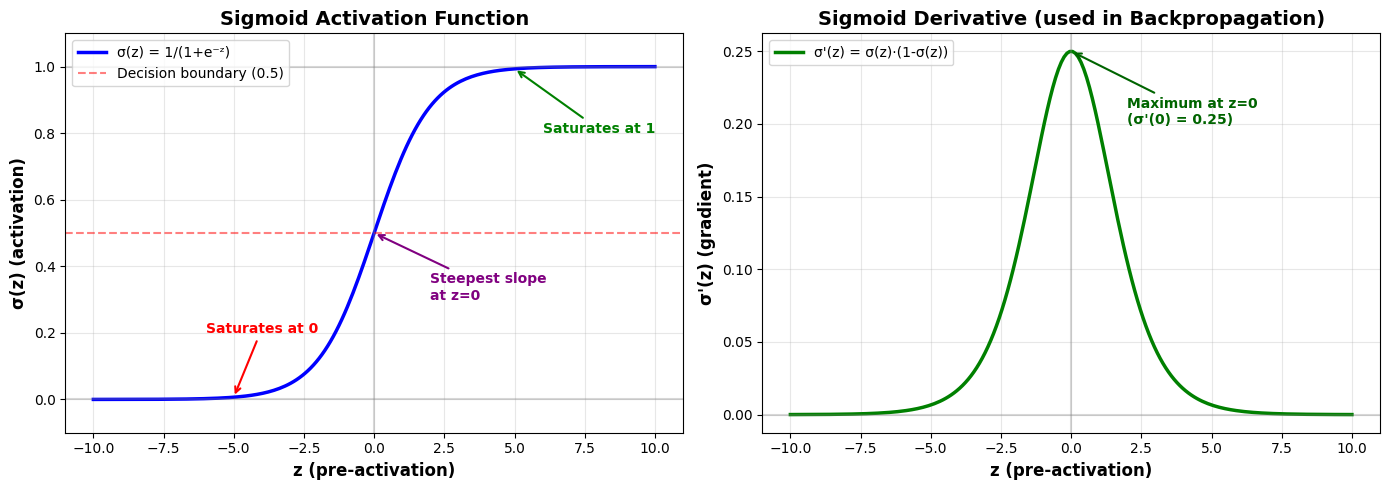

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values
z = np.linspace(-10, 10, 200)
sigma_z = sigmoid(z)

# Create plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Sigmoid function
ax1.plot(z, sigma_z, 'b-', linewidth=2.5, label='σ(z) = 1/(1+e⁻ᶻ)')
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z (pre-activation)', fontsize=12, fontweight='bold')
ax1.set_ylabel('σ(z) (activation)', fontsize=12, fontweight='bold')
ax1.set_title('Sigmoid Activation Function', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_ylim(-0.1, 1.1)

# Annotations
ax1.annotate('Saturates at 1', xy=(5, sigmoid(5)), xytext=(6, 0.8),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            fontsize=10, color='green', fontweight='bold')
ax1.annotate('Saturates at 0', xy=(-5, sigmoid(-5)), xytext=(-6, 0.2),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, color='red', fontweight='bold')
ax1.annotate('Steepest slope\nat z=0', xy=(0, 0.5), xytext=(2, 0.3),
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.5),
            fontsize=10, color='purple', fontweight='bold')

# Right plot: Derivative of sigmoid
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

sigma_prime_z = sigmoid_derivative(z)

ax2.plot(z, sigma_prime_z, 'g-', linewidth=2.5, label="σ'(z) = σ(z)·(1-σ(z))")
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('z (pre-activation)', fontsize=12, fontweight='bold')
ax2.set_ylabel("σ'(z) (gradient)", fontsize=12, fontweight='bold')
ax2.set_title('Sigmoid Derivative (used in Backpropagation)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)

# Annotation
ax2.annotate('Maximum at z=0\n(σ\'(0) = 0.25)', xy=(0, 0.25), xytext=(2, 0.2),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
            fontsize=10, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

### Propiedades clave de la Sigmoide

**1. No-linealidad:**
La forma de "S" introduce la curvatura necesaria para que la red pueda aprender fronteras de decisión complejas, como las que vimos en el problema XOR.

**2. Derivada simple:**
Una propiedad matemática muy conveniente de la sigmoide es que su derivada se puede expresar en función de ella misma:

**σ'(z) = σ(z) · (1 - σ(z))**

Esto simplificará enormemente los cálculos durante backpropagation. Si ya hemos calculado σ(z) durante forward propagation, calcular su derivada es trivial.

**3. Vanishing gradient:**
Como se observa en el gráfico de la derecha, la derivada de la sigmoide tiene un máximo de 0.25 en z=0 y se acerca a 0 cuando |z| es grande. Esto significa que durante backpropagation, los gradientes pueden volverse muy pequeños, dificultando el aprendizaje en redes muy profundas. Este es el famoso problema del **vanishing gradient**, aunque para nuestra red pequeña (2-4-1) no será un problema significativo.

### Aplicando la Sigmoide en nuestra red

En nuestra arquitectura 2-4-1, aplicaremos la sigmoide **después de cada suma ponderada**:

**Capa oculta:**
```
z⁽¹⁾ = W⁽¹⁾·X + b⁽¹⁾        (suma ponderada)
h = σ(z⁽¹⁾)                 (activación)
```

**Capa de salida:**
```
z⁽²⁾ = W⁽²⁾·h + b⁽²⁾        (suma ponderada)
ŷ = σ(z⁽²⁾)                 (activación final)
```

Veamos un ejemplo concreto con valores numéricos:

In [5]:
# Example: forward pass for one data point
X_example = np.array([[1, 0]])  # XOR input: (1, 0) -> should output 1

# Random weights (these will be learned during training)
W1_example = np.array([[0.5, -0.3, 0.2, 0.8],
                       [-0.4, 0.6, -0.1, 0.3]])
b1_example = np.array([[0.1, -0.2, 0.0, 0.15]])

W2_example = np.array([[0.7], [-0.5], [0.3], [0.9]])
b2_example = np.array([[0.05]])

# Forward propagation
print("Input:", X_example)
print("\n--- HIDDEN LAYER ---")

# Hidden layer computation
z1 = np.dot(X_example, W1_example) + b1_example
print("Pre-activation (z1):", z1)

h = sigmoid(z1)
print("Activation (h):", h)

print("\n--- OUTPUT LAYER ---")

# Output layer computation
z2 = np.dot(h, W2_example) + b2_example
print("Pre-activation (z2):", z2)

y_pred = sigmoid(z2)
print("Final prediction (ŷ):", y_pred)
print(f"\nPredicted class: {1 if y_pred > 0.5 else 0}")
print(f"True label: 1")

Input: [[1 0]]

--- HIDDEN LAYER ---
Pre-activation (z1): [[ 0.6  -0.5   0.2   0.95]]
Activation (h): [[0.64565631 0.37754067 0.549834   0.72111518]]

--- OUTPUT LAYER ---
Pre-activation (z2): [[1.12714294]]
Final prediction (ŷ): [[0.75531125]]

Predicted class: 1
True label: 1


Con pesos aleatorios, es muy probable que la predicción inicial sea incorrecta. **El objetivo del entrenamiento es ajustar estos pesos para que la red produzca las salidas correctas.**

En la siguiente sección veremos cómo la información fluye hacia adelante a través de la red durante el proceso de **Forward Propagation**.

# 3. Forward Propagation: El Camino de Ida

Forward Propagation (propagación hacia adelante) es el proceso mediante el cual los datos de entrada fluyen a través de la red neuronal, capa por capa, hasta producir una predicción en la salida. Es el "camino de ida" de la información: desde las entradas hasta la salida final.

Este proceso ocurre tanto durante el **entrenamiento** como durante la **predicción** (inference). Durante el entrenamiento, necesitaremos las activaciones intermedias para después calcular los gradientes en backpropagation.

## Flujo de información a través de las capas

El flujo de información en nuestra red 2-4-1 sigue este camino:

```
Entrada (X)  →  [Capa Oculta]  →  Activación (h)  →  [Capa Salida]  →  Predicción (ŷ)
   (2,)              W⁽¹⁾, b⁽¹⁾           (4,)            W⁽²⁾, b⁽²⁾           (1,)
```

Para cada capa, el proceso se repite:
1. **Combinación lineal:** Multiplicar las entradas por los pesos y sumar el sesgo
2. **Aplicar función de activación:** Pasar el resultado por la función sigmoide
3. **Pasar a la siguiente capa:** La salida se convierte en entrada de la siguiente capa

Visualicemos este flujo con un diagrama detallado:

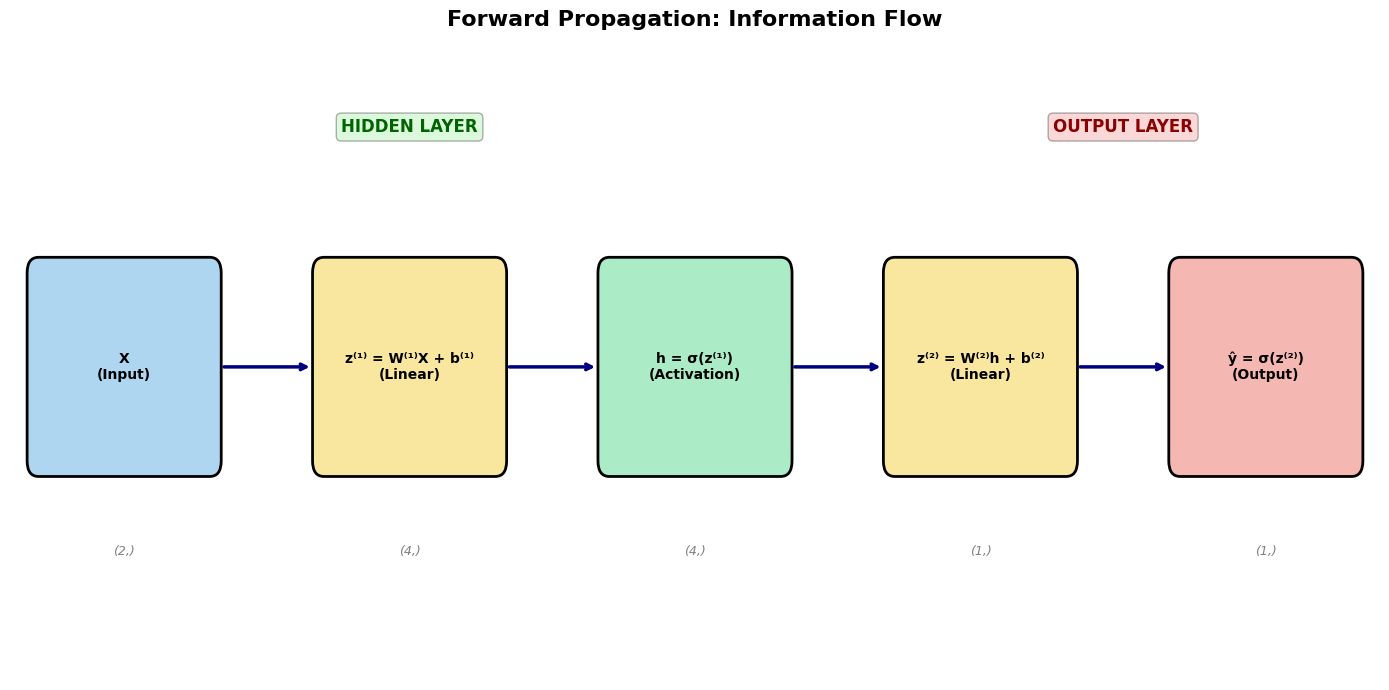

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle

fig, ax = plt.subplots(figsize=(14, 7))

# Define positions
x_positions = [1, 3.5, 6, 8.5, 11]
y_center = 3

# Box dimensions
box_width = 1.5
box_height = 1.2

# Colors
color_input = '#AED6F1'
color_linear = '#F9E79F'
color_activation = '#ABEBC6'
color_output = '#F5B7B1'

# Draw boxes
boxes = [
    (x_positions[0], 'X\n(Input)', color_input),
    (x_positions[1], 'z⁽¹⁾ = W⁽¹⁾X + b⁽¹⁾\n(Linear)', color_linear),
    (x_positions[2], 'h = σ(z⁽¹⁾)\n(Activation)', color_activation),
    (x_positions[3], 'z⁽²⁾ = W⁽²⁾h + b⁽²⁾\n(Linear)', color_linear),
    (x_positions[4], 'ŷ = σ(z⁽²⁾)\n(Output)', color_output),
]

for x, label, color in boxes:
    rect = FancyBboxPatch((x - box_width/2, y_center - box_height/2),
                          box_width, box_height,
                          boxstyle="round,pad=0.1",
                          edgecolor='black', facecolor=color,
                          linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y_center, label, ha='center', va='center',
            fontsize=10, fontweight='bold')

# Draw arrows
for i in range(len(x_positions) - 1):
    ax.annotate('', xy=(x_positions[i+1] - box_width/2 - 0.1, y_center),
                xytext=(x_positions[i] + box_width/2 + 0.1, y_center),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='navy'))

# Add layer labels
ax.text((x_positions[0] + x_positions[2]) / 2, y_center + 1.5,
        'HIDDEN LAYER', ha='center', fontsize=12, fontweight='bold',
        color='darkgreen', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.text((x_positions[3] + x_positions[4]) / 2, y_center + 1.5,
        'OUTPUT LAYER', ha='center', fontsize=12, fontweight='bold',
        color='darkred', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

# Add dimension annotations
ax.text(x_positions[0], y_center - 1.2, '(2,)', ha='center',
        fontsize=9, style='italic', color='gray')
ax.text(x_positions[1], y_center - 1.2, '(4,)', ha='center',
        fontsize=9, style='italic', color='gray')
ax.text(x_positions[2], y_center - 1.2, '(4,)', ha='center',
        fontsize=9, style='italic', color='gray')
ax.text(x_positions[3], y_center - 1.2, '(1,)', ha='center',
        fontsize=9, style='italic', color='gray')
ax.text(x_positions[4], y_center - 1.2, '(1,)', ha='center',
        fontsize=9, style='italic', color='gray')

ax.set_xlim(0, 12)
ax.set_ylim(1, 5)
ax.axis('off')
plt.title('Forward Propagation: Information Flow', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Cálculo de activaciones capa por capa

Veamos ahora en detalle cómo se realizan los cálculos en cada capa. Utilizaremos notación matemática precisa que luego traduciremos directamente a código Python.

### Notación

- **Superíndices** (⁽ˡ⁾) indican la capa: l = 1 para capa oculta, l = 2 para capa de salida
- **X**: Matriz de entrada, dimensión (n_samples, 2)
- **W⁽ˡ⁾**: Matriz de pesos de la capa l
- **b⁽ˡ⁾**: Vector de sesgos de la capa l
- **z⁽ˡ⁾**: Pre-activación (suma ponderada) de la capa l
- **a⁽ˡ⁾**: Activación (después de aplicar σ) de la capa l

### Paso 1: Capa de Entrada → Capa Oculta

**Combinación lineal:**
```
z⁽¹⁾ = X · W⁽¹⁾ + b⁽¹⁾
```

Expandiendo las dimensiones:
```
(n_samples, 4) = (n_samples, 2) · (2, 4) + (1, 4)
```

Para un único ejemplo (x₁, x₂), los 4 valores de z⁽¹⁾ son:
```
z₁⁽¹⁾ = x₁·w₁₁⁽¹⁾ + x₂·w₂₁⁽¹⁾ + b₁⁽¹⁾
z₂⁽¹⁾ = x₁·w₁₂⁽¹⁾ + x₂·w₂₂⁽¹⁾ + b₂⁽¹⁾
z₃⁽¹⁾ = x₁·w₁₃⁽¹⁾ + x₂·w₂₃⁽¹⁾ + b₃⁽¹⁾
z₄⁽¹⁾ = x₁·w₁₄⁽¹⁾ + x₂·w₂₄⁽¹⁾ + b₄⁽¹⁾
```

**Aplicar función de activación:**
```
h = σ(z⁽¹⁾) = a⁽¹⁾
```

Cada elemento se calcula como:
```
h₁ = σ(z₁⁽¹⁾) = 1 / (1 + e^(-z₁⁽¹⁾))
h₂ = σ(z₂⁽¹⁾) = 1 / (1 + e^(-z₂⁽¹⁾))
h₃ = σ(z₃⁽¹⁾) = 1 / (1 + e^(-z₃⁽¹⁾))
h₄ = σ(z₄⁽¹⁾) = 1 / (1 + e^(-z₄⁽¹⁾))
```

El resultado **h** es un vector de 4 valores entre 0 y 1, que representa la activación de las 4 neuronas ocultas.

### Paso 2: Capa Oculta → Capa de Salida

**Combinación lineal:**
```
z⁽²⁾ = h · W⁽²⁾ + b⁽²⁾ = a⁽¹⁾ · W⁽²⁾ + b⁽²⁾
```

Expandiendo las dimensiones:
```
(n_samples, 1) = (n_samples, 4) · (4, 1) + (1, 1)
```

Para un único ejemplo:
```
z⁽²⁾ = h₁·w₁⁽²⁾ + h₂·w₂⁽²⁾ + h₃·w₃⁽²⁾ + h₄·w₄⁽²⁾ + b⁽²⁾
```

**Aplicar función de activación:**
```
ŷ = σ(z⁽²⁾) = a⁽²⁾
```

Calculado como:
```
ŷ = 1 / (1 + e^(-z⁽²⁾))
```

El resultado **ŷ** es un valor entre 0 y 1 que interpretaremos como la probabilidad de que la salida sea 1.

### Ejemplo numérico completo

Veamos un ejemplo concreto con valores reales para el punto XOR (1, 0) que debería dar salida 1:

In [7]:
import numpy as np

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# XOR dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y_true = np.array([[0], [1], [1], [0]])

# Initialize weights (random small values)
np.random.seed(42)
W1 = np.random.randn(2, 4) * 0.5
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.5
b2 = np.zeros((1, 1))

print("="*60)
print("FORWARD PROPAGATION - DETAILED EXAMPLE")
print("="*60)

# Select one example: (1, 0) -> should output 1
example_idx = 2
X_example = X[example_idx:example_idx+1]  # Keep 2D shape
y_example = y_true[example_idx:example_idx+1]

print(f"\nInput: {X_example[0]}")
print(f"Expected output: {y_example[0][0]}")

print("\n" + "="*60)
print("STEP 1: INPUT LAYER → HIDDEN LAYER")
print("="*60)

print("\nWeights W⁽¹⁾ (2x4):")
print(W1)
print(f"\nBiases b⁽¹⁾ (1x4):")
print(b1)

# Linear combination
z1 = np.dot(X_example, W1) + b1
print(f"\nPre-activation z⁽¹⁾ = X·W⁽¹⁾ + b⁽¹⁾:")
print(z1)

# Activation
a1 = sigmoid(z1)
print(f"\nActivation h = σ(z⁽¹⁾):")
print(a1)
print(f"(All values are between 0 and 1)")

print("\n" + "="*60)
print("STEP 2: HIDDEN LAYER → OUTPUT LAYER")
print("="*60)

print("\nWeights W⁽²⁾ (4x1):")
print(W2)
print(f"\nBiases b⁽²⁾ (1x1):")
print(b2)

# Linear combination
z2 = np.dot(a1, W2) + b2
print(f"\nPre-activation z⁽²⁾ = h·W⁽²⁾ + b⁽²⁾:")
print(z2)

# Final activation
y_pred = sigmoid(z2)
print(f"\nFinal prediction ŷ = σ(z⁽²⁾):")
print(y_pred)

print("\n" + "="*60)
print("RESULT")
print("="*60)
print(f"Predicted value: {y_pred[0][0]:.6f}")
print(f"Expected value: {y_example[0][0]}")
print(f"Predicted class: {1 if y_pred[0][0] > 0.5 else 0}")
print(f"Correct: {(1 if y_pred[0][0] > 0.5 else 0) == y_example[0][0]}")

FORWARD PROPAGATION - DETAILED EXAMPLE

Input: [1 0]
Expected output: 1

STEP 1: INPUT LAYER → HIDDEN LAYER

Weights W⁽¹⁾ (2x4):
[[ 0.24835708 -0.06913215  0.32384427  0.76151493]
 [-0.11707669 -0.11706848  0.78960641  0.38371736]]

Biases b⁽¹⁾ (1x4):
[[0. 0. 0. 0.]]

Pre-activation z⁽¹⁾ = X·W⁽¹⁾ + b⁽¹⁾:
[[ 0.24835708 -0.06913215  0.32384427  0.76151493]]

Activation h = σ(z⁽¹⁾):
[[0.56177208 0.48272384 0.58026084 0.68168255]]
(All values are between 0 and 1)

STEP 2: HIDDEN LAYER → OUTPUT LAYER

Weights W⁽²⁾ (4x1):
[[-0.23473719]
 [ 0.27128002]
 [-0.23170885]
 [-0.23286488]]

Biases b⁽²⁾ (1x1):
[[0.]]

Pre-activation z⁽²⁾ = h·W⁽²⁾ + b⁽²⁾:
[[-0.29410696]]

Final prediction ŷ = σ(z⁽²⁾):
[[0.42699871]]

RESULT
Predicted value: 0.426999
Expected value: 1
Predicted class: 0
Correct: False


Como podemos observar, **con pesos aleatorios la predicción será incorrecta**. Esto es completamente esperado: la red aún no ha aprendido nada. El objetivo del entrenamiento es ajustar W⁽¹⁾, b⁽¹⁾, W⁽²⁾ y b⁽²⁾ para que las predicciones sean correctas.

## Obteniendo la predicción final

Una vez completada la forward propagation, obtenemos un valor ŷ entre 0 y 1. ¿Cómo interpretamos este valor?

### Interpretación como probabilidad

Podemos interpretar ŷ como la **probabilidad estimada** de que la clase sea 1:

```
P(y = 1 | X) = ŷ
P(y = 0 | X) = 1 - ŷ
```

### Regla de decisión

Para convertir la probabilidad en una predicción de clase, aplicamos un **umbral de decisión** (típicamente 0.5):

```
clase_predicha = {
    1  si ŷ ≥ 0.5
    0  si ŷ < 0.5
}
```

Visualicemos cómo cambian las predicciones a medida que la red entrena:

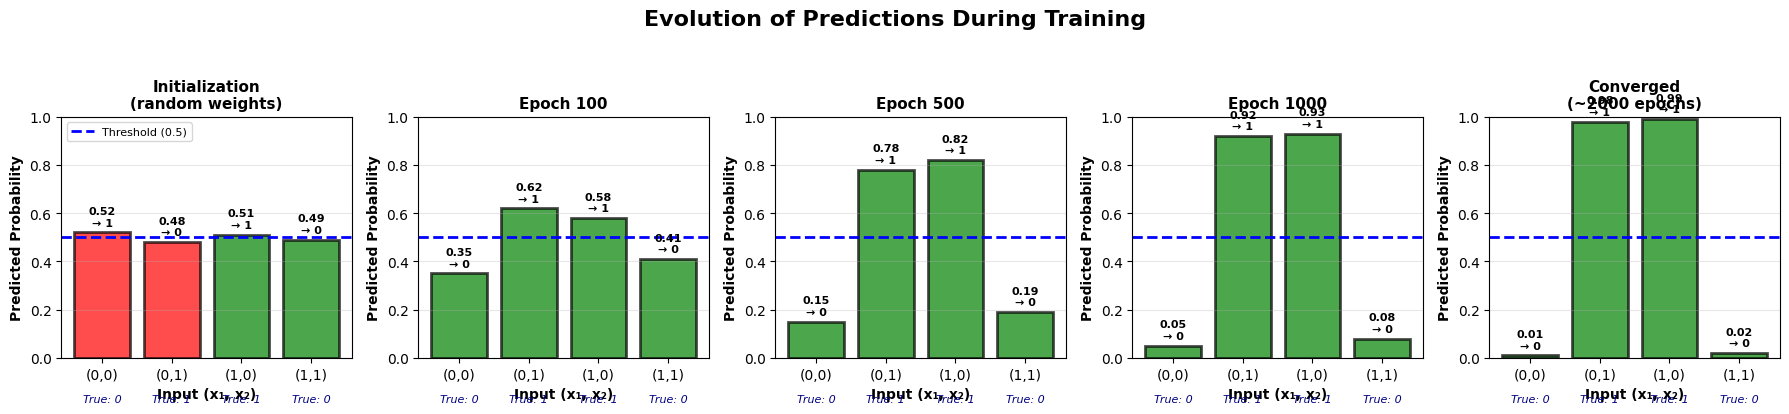

In [8]:
import matplotlib.pyplot as plt

# Simulate predictions at different training stages
stages = ['Initialization\n(random weights)', 'Epoch 100', 'Epoch 500',
          'Epoch 1000', 'Converged\n(~2000 epochs)']
predictions = [
    [0.52, 0.48, 0.51, 0.49],  # Random (close to 0.5)
    [0.35, 0.62, 0.58, 0.41],  # Starting to learn
    [0.15, 0.78, 0.82, 0.19],  # Getting better
    [0.05, 0.92, 0.93, 0.08],  # Almost there
    [0.01, 0.98, 0.99, 0.02],  # Perfect
]
true_labels = [0, 1, 1, 0]
inputs = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, (ax, stage, preds) in enumerate(zip(axes, stages, predictions)):
    colors = ['green' if (p >= 0.5) == label else 'red'
              for p, label in zip(preds, true_labels)]

    bars = ax.bar(inputs, preds, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.axhline(y=0.5, color='blue', linestyle='--', linewidth=2, label='Threshold (0.5)')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Predicted Probability', fontsize=10, fontweight='bold')
    ax.set_xlabel('Input (x₁, x₂)', fontsize=10, fontweight='bold')
    ax.set_title(stage, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, (bar, pred, true_label) in enumerate(zip(bars, preds, true_labels)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{pred:.2f}\n→ {1 if pred >= 0.5 else 0}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

        # Add true label at bottom
        ax.text(i, -0.15, f'True: {true_label}', ha='center', va='top',
                fontsize=8, style='italic', color='navy')

    if idx == 0:
        ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Evolution of Predictions During Training',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Forward Propagation para el dataset completo

Hasta ahora hemos visto cómo procesar un único ejemplo. En la práctica, procesamos **todo el dataset a la vez** usando operaciones matriciales:

In [9]:
# Forward propagation for all 4 XOR samples at once
def forward_propagation(X, W1, b1, W2, b2):
    """
    Perform forward propagation for all samples.

    Args:
        X: Input matrix (4, 2)
        W1: Weights input->hidden (2, 4)
        b1: Biases hidden (1, 4)
        W2: Weights hidden->output (4, 1)
        b2: Biases output (1, 1)

    Returns:
        y_pred: Predictions (4, 1)
        cache: Dictionary with intermediate values (for backprop)
    """
    # Hidden layer
    z1 = np.dot(X, W1) + b1      # (4, 2) · (2, 4) + (1, 4) = (4, 4)
    a1 = sigmoid(z1)              # (4, 4)

    # Output layer
    z2 = np.dot(a1, W2) + b2     # (4, 4) · (4, 1) + (1, 1) = (4, 1)
    y_pred = sigmoid(z2)          # (4, 1)

    # Store intermediate values for backpropagation
    cache = {
        'X': X,
        'z1': z1,
        'a1': a1,
        'z2': z2,
        'y_pred': y_pred
    }

    return y_pred, cache

# Test forward propagation
y_pred, cache = forward_propagation(X, W1, b1, W2, b2)

print("Forward Propagation Results (all samples):")
print("="*50)
for i in range(4):
    print(f"Input: {X[i]} → Predicted: {y_pred[i][0]:.4f} → Class: {1 if y_pred[i][0] >= 0.5 else 0} (True: {y_true[i][0]})")

Forward Propagation Results (all samples):
Input: [0 0] → Predicted: 0.4467 → Class: 0 (True: 0)
Input: [0 1] → Predicted: 0.4303 → Class: 0 (True: 1)
Input: [1 0] → Predicted: 0.4270 → Class: 0 (True: 1)
Input: [1 1] → Predicted: 0.4126 → Class: 0 (True: 0)


**Nota importante:** Guardamos todos los valores intermedios (z⁽¹⁾, a⁽¹⁾, z⁽²⁾) en un diccionario `cache`. Estos valores serán esenciales para calcular los gradientes durante backpropagation, como veremos en las próximas secciones.

---

Con esto hemos completado el camino de ida. Ahora sabemos cómo la red toma las entradas y produce predicciones. Pero, ¿cómo sabe la red si sus predicciones son buenas o malas? Eso lo veremos en la siguiente sección al introducir la **Función de Coste**.

# 4. La Función de Coste (Loss Function)

Una vez que la red ha generado sus predicciones mediante forward propagation, necesitamos una forma de **cuantificar qué tan buenas o malas son esas predicciones**. Aquí es donde entra en juego la función de coste (también llamada función de pérdida o *loss function*).

La función de coste es el "termómetro" que mide la "salud" de nuestra red: valores altos indican predicciones pobres, valores bajos indican que la red está aprendiendo correctamente.

## ¿Qué estamos tratando de minimizar?

El objetivo del entrenamiento de una red neuronal es ajustar los pesos y sesgos para que las predicciones **ŷ** sean lo más cercanas posible a las etiquetas verdaderas **y**.

Matemáticamente, queremos encontrar los parámetros óptimos **θ** = {W⁽¹⁾, b⁽¹⁾, W⁽²⁾, b⁽²⁾} que minimicen alguna medida de error entre las predicciones y la realidad:

```
θ* = argmin L(θ)
       θ
```

donde **L(θ)** es nuestra función de coste que depende de los parámetros de la red.

### Requisitos de una buena función de coste

Para que una función de coste sea útil en el entrenamiento de redes neuronales, debe cumplir ciertos requisitos:

1. **Diferenciable:** Debe poder calcularse su derivada para aplicar el descenso del gradiente
2. **No negativa:** L ≥ 0, con L = 0 solo cuando las predicciones son perfectas
3. **Penaliza errores:** Valores más altos cuando las predicciones se alejan de los valores verdaderos
4. **Suave:** Sin discontinuidades que dificulten la optimización

Existen muchas funciones de coste posibles (Binary Cross-Entropy, Categorical Cross-Entropy, Hinge Loss, etc.), pero en este artículo usaremos una de las más intuitivas: el **Error Cuadrático Medio (MSE)**.

## Error Cuadrático Medio (MSE)

El Error Cuadrático Medio (Mean Squared Error, MSE) es una de las funciones de coste más utilizadas, especialmente en problemas de regresión, aunque también funciona bien para clasificación binaria.

### Definición matemática

Para un único ejemplo, el error cuadrático es:

```
Error = (y - ŷ)²
```

donde:
- **y**: Valor verdadero (0 o 1 para XOR)
- **ŷ**: Predicción de la red (valor entre 0 y 1)

Para **m** ejemplos de entrenamiento, el MSE es el promedio de todos los errores:

```
MSE = (1/m) · Σᵢ₌₁ᵐ (yᵢ - ŷᵢ)²
```

En nuestro caso de XOR, tenemos 4 ejemplos (m = 4):

```
MSE = (1/4) · [(y₁ - ŷ₁)² + (y₂ - ŷ₂)² + (y₃ - ŷ₃)² + (y₄ - ŷ₄)²]
```

### ¿Por qué elevar al cuadrado?

Elevar al cuadrado tiene varias ventajas:

1. **Siempre positivo:** (y - ŷ)² ≥ 0, lo que garantiza que el error no se cancele cuando sumamos múltiples ejemplos
2. **Penaliza errores grandes:** Errores grandes se amplifican (0.5² = 0.25, pero 1.0² = 1.0)
3. **Diferenciable:** La función es suave y fácil de derivar
4. **Interpretación geométrica:** Representa la distancia euclidiana al cuadrado

Veamos un ejemplo numérico con nuestro problema XOR:

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_mse(y_true, y_pred):
    """
    Compute Mean Squared Error.

    Args:
        y_true: True labels (m, 1)
        y_pred: Predicted values (m, 1)

    Returns:
        mse: Mean squared error (scalar)
    """
    m = y_true.shape[0]
    mse = (1 / m) * np.sum((y_true - y_pred) ** 2)
    return mse

# XOR dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y_true = np.array([[0], [1], [1], [0]])

# Initialize weights
np.random.seed(42)
W1 = np.random.randn(2, 4) * 0.5
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.5
b2 = np.zeros((1, 1))

# Forward propagation
z1 = np.dot(X, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
y_pred = sigmoid(z2)

# Compute MSE
mse = compute_mse(y_true, y_pred)

print("="*60)
print("MEAN SQUARED ERROR CALCULATION")
print("="*60)
print("\nPredictions vs True Labels:")
print("-"*60)
print(f"{'Input':<12} {'True Label':<12} {'Prediction':<15} {'Error':<10} {'Squared Error'}")
print("-"*60)

total_squared_error = 0
for i in range(4):
    error = y_true[i][0] - y_pred[i][0]
    squared_error = error ** 2
    total_squared_error += squared_error
    print(f"{str(X[i]):<12} {y_true[i][0]:<12} {y_pred[i][0]:<15.6f} {error:<10.6f} {squared_error:.6f}")

print("-"*60)
print(f"Sum of squared errors: {total_squared_error:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.6f}")

MEAN SQUARED ERROR CALCULATION

Predictions vs True Labels:
------------------------------------------------------------
Input        True Label   Prediction      Error      Squared Error
------------------------------------------------------------
[0 0]        0            0.446699        -0.446699  0.199540
[0 1]        1            0.430293        0.569707   0.324566
[1 0]        1            0.426999        0.573001   0.328330
[1 1]        0            0.412631        -0.412631  0.170265
------------------------------------------------------------
Sum of squared errors: 1.022701
Mean Squared Error (MSE): 0.255675
Root Mean Squared Error (RMSE): 0.505643


### Interpretación del MSE

- **MSE = 0:** Predicciones perfectas (ŷᵢ = yᵢ para todo i)
- **MSE cercano a 0:** La red está aprendiendo bien
- **MSE alto:** Las predicciones están muy alejadas de los valores verdaderos
- **MSE = 0.25:** En promedio, cada predicción está a 0.5 de su valor verdadero (√0.25 = 0.5)

Para el problema XOR, con etiquetas en {0, 1}:
- **Peor caso posible:** Predecir siempre 1 cuando debería ser 0, y viceversa → MSE = 1.0
- **Predicciones aleatorias:** Predecir siempre 0.5 → MSE ≈ 0.25
- **Objetivo:** MSE < 0.01 (predicciones muy cercanas a las etiquetas correctas)

## Interpretación geométrica del error

El MSE tiene una interpretación geométrica muy intuitiva: representa la **distancia euclidiana al cuadrado** entre el vector de predicciones y el vector de valores verdaderos en un espacio de m dimensiones.

Visualicemos cómo evoluciona el MSE durante el entrenamiento:

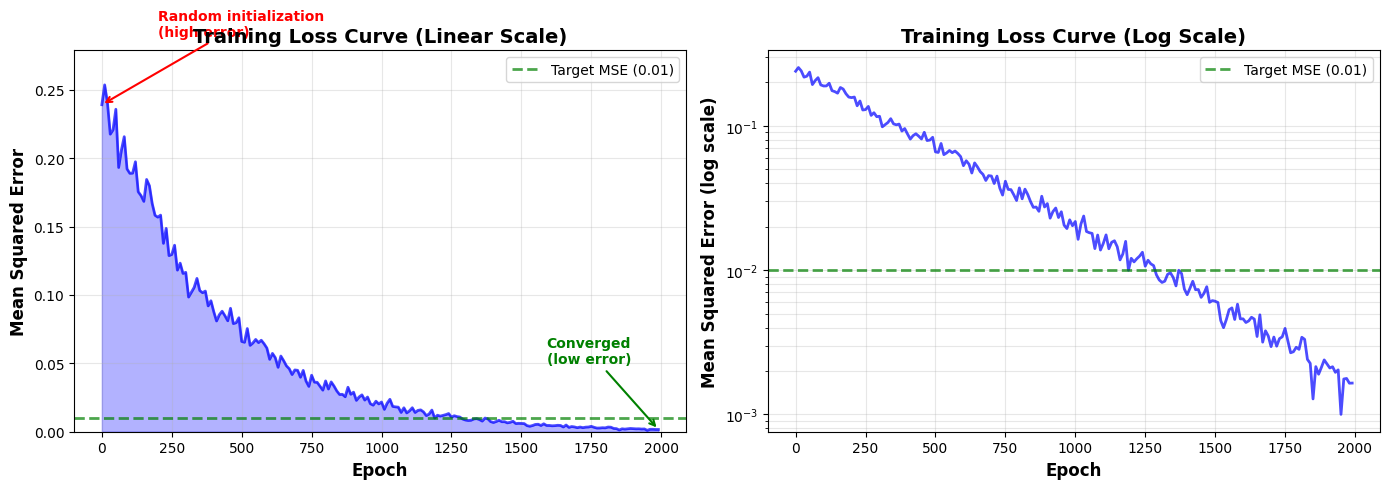

In [11]:
# Simulate training process with decreasing MSE
np.random.seed(123)

# Simulate MSE values during training
epochs = np.arange(0, 2000, 10)
# Start high, decrease exponentially with some noise
mse_values = 0.25 * np.exp(-epochs / 400) + 0.01 * np.random.randn(len(epochs)) * np.exp(-epochs / 600)
mse_values = np.maximum(mse_values, 0.001)  # Ensure non-negative

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: MSE over epochs (linear scale)
ax1.plot(epochs, mse_values, 'b-', linewidth=2, alpha=0.7)
ax1.axhline(y=0.01, color='green', linestyle='--', linewidth=2,
            label='Target MSE (0.01)', alpha=0.7)
ax1.fill_between(epochs, 0, mse_values, alpha=0.3, color='blue')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax1.set_title('Training Loss Curve (Linear Scale)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim(0, max(mse_values) * 1.1)

# Annotations
ax1.annotate('Random initialization\n(high error)',
             xy=(0, mse_values[0]), xytext=(200, mse_values[0] + 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold')
ax1.annotate('Converged\n(low error)',
             xy=(epochs[-1], mse_values[-1]), xytext=(epochs[-1] - 400, 0.05),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green', fontweight='bold')

# Right plot: MSE over epochs (log scale)
ax2.semilogy(epochs, mse_values, 'b-', linewidth=2, alpha=0.7)
ax2.axhline(y=0.01, color='green', linestyle='--', linewidth=2,
            label='Target MSE (0.01)', alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Squared Error (log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Training Loss Curve (Log Scale)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Esta curva de pérdida (loss curve) es una de las herramientas más importantes para diagnosticar el entrenamiento:

- **Descenso rápido inicial:** La red está aprendiendo patrones obvios
- **Descenso gradual:** La red está refinando sus predicciones
- **Plateau (meseta):** La red ha encontrado un mínimo local
- **Oscilaciones:** Posible learning rate demasiado alto
- **No desciende:** Problema con la inicialización o arquitectura

### Visualización del error individual por ejemplo

Otra forma útil de visualizar el error es ver cómo cada ejemplo contribuye al MSE total:


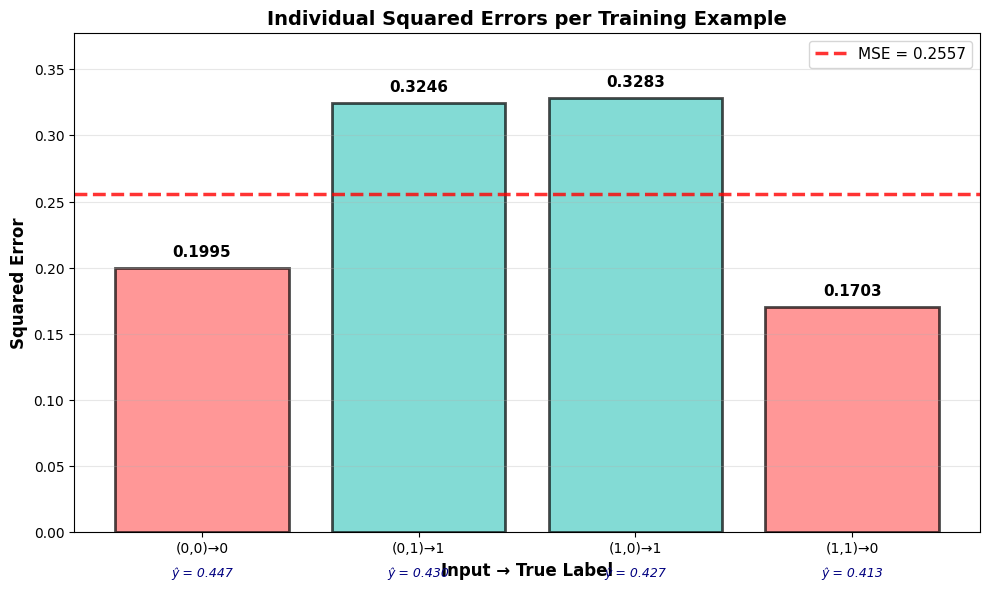

In [12]:
# Calculate individual squared errors
individual_errors = (y_true - y_pred) ** 2

fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot of individual squared errors
inputs_labels = ['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0']
colors = ['#FF6B6B', '#4ECDC4', '#4ECDC4', '#FF6B6B']  # Red for class 0, teal for class 1

bars = ax.bar(inputs_labels, individual_errors.flatten(), color=colors,
              alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for i, (bar, error) in enumerate(zip(bars, individual_errors.flatten())):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(individual_errors) * 0.02,
            f'{error:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Add prediction below
    ax.text(i, -max(individual_errors) * 0.08,
            f'ŷ = {y_pred[i][0]:.3f}',
            ha='center', va='top', fontsize=9, style='italic', color='navy')

# Add average line
avg_error = np.mean(individual_errors)
ax.axhline(y=avg_error, color='red', linestyle='--', linewidth=2.5,
           label=f'MSE = {avg_error:.4f}', alpha=0.8)

ax.set_xlabel('Input → True Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Squared Error', fontsize=12, fontweight='bold')
ax.set_title('Individual Squared Errors per Training Example', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(individual_errors) * 1.15)

plt.tight_layout()
plt.show()

Este gráfico nos permite identificar qué ejemplos están siendo más difíciles de aprender para la red. En las primeras etapas del entrenamiento, todos los ejemplos contribuirán significativamente al error, pero a medida que la red aprende, algunos ejemplos convergerán más rápido que otros.

### La derivada del MSE

Para poder aplicar el descenso del gradiente (que veremos en las próximas secciones), necesitamos la **derivada del MSE** con respecto a las predicciones:

```
∂MSE/∂ŷᵢ = ∂/∂ŷᵢ [(1/m) · Σⱼ (yⱼ - ŷⱼ)²]
         = (1/m) · ∂/∂ŷᵢ [(yᵢ - ŷᵢ)²]
         = (1/m) · 2(yᵢ - ŷᵢ) · (-1)
         = -(2/m) · (yᵢ - ŷᵢ)
```

Simplificando (y a menudo omitiendo la constante 2):

```
∂MSE/∂ŷᵢ = -(1/m) · (yᵢ - ŷᵢ)
```

o en forma vectorial para todos los ejemplos:

```
∂MSE/∂ŷ = -(1/m) · (y - ŷ)
```

**Nota:** Algunos textos incluyen un factor 1/2 en la definición del MSE para simplificar esta derivada y obtener exactamente -(y - ŷ). Ambas formas son equivalentes, solo cambian por una constante.

Esta derivada es el punto de partida para backpropagation, que estudiaremos en la Sección 6. Nos indica **cómo debe cambiar cada predicción para reducir el error**.

### Código completo: Función de coste

Implementemos una función completa que calcule el MSE junto con su derivada:

In [13]:
def compute_cost_and_gradient(y_true, y_pred):
    """
    Compute MSE loss and its gradient.

    Args:
        y_true: True labels (m, 1)
        y_pred: Predicted values (m, 1)

    Returns:
        cost: MSE value (scalar)
        d_cost: Gradient of cost w.r.t. predictions (m, 1)
    """
    m = y_true.shape[0]

    # Compute MSE
    cost = (1 / m) * np.sum((y_true - y_pred) ** 2)

    # Compute gradient (derivative of MSE w.r.t. predictions)
    d_cost = -(2 / m) * (y_true - y_pred)

    return cost, d_cost

# Test the function
cost, d_cost = compute_cost_and_gradient(y_true, y_pred)

print("="*60)
print("COST AND GRADIENT")
print("="*60)
print(f"\nMean Squared Error: {cost:.6f}")
print(f"\nGradient (∂MSE/∂ŷ):")
print(d_cost)
print(f"\nGradient interpretation:")
print("Negative values → prediction should increase")
print("Positive values → prediction should decrease")
print(f"\nGradient magnitude indicates urgency of change")

COST AND GRADIENT

Mean Squared Error: 0.255675

Gradient (∂MSE/∂ŷ):
[[ 0.22334971]
 [-0.28485331]
 [-0.28650064]
 [ 0.20631572]]

Gradient interpretation:
Negative values → prediction should increase
Positive values → prediction should decrease

Gradient magnitude indicates urgency of change


---

Ahora que sabemos cómo medir el error de nuestra red, el siguiente paso es entender **cómo podemos usar esta información para mejorar los pesos**. Eso lo veremos en la siguiente sección sobre el Descenso del Gradiente.

# 5. Backpropagation: El Motor del Aprendizaje

Backpropagation (propagación hacia atrás) es el algoritmo que hace posible el entrenamiento de redes neuronales profundas. Es el mecanismo mediante el cual calculamos **cómo debe cambiar cada peso y sesgo** para reducir el error de la red.

Si forward propagation es el "camino de ida" donde calculamos predicciones, backpropagation es el "camino de vuelta" donde distribuimos la responsabilidad del error a cada parámetro de la red.

## La Regla de la Cadena aplicada a redes neuronales

El fundamento matemático de backpropagation es la **Regla de la Cadena** del cálculo diferencial. Esta regla nos permite calcular derivadas de funciones compuestas, que es exactamente lo que es una red neuronal: una composición de múltiples funciones.

### Recordatorio: La Regla de la Cadena

Si tenemos una función compuesta **f(g(x))**, la derivada es:

```
df/dx = (df/dg) · (dg/dx)
```

Para funciones con múltiples variables intermedias:

```
∂z/∂x = (∂z/∂y) · (∂y/∂x)
```

### Aplicación a nuestra red 2-4-1

Recordemos la arquitectura de nuestra red:

```
X → [z⁽¹⁾ = W⁽¹⁾X + b⁽¹⁾] → [a⁽¹⁾ = σ(z⁽¹⁾)] → [z⁽²⁾ = W⁽²⁾a⁽¹⁾ + b⁽²⁾] → [ŷ = σ(z⁽²⁾)] → MSE
```

Para actualizar los pesos, necesitamos calcular:
- **∂MSE/∂W⁽²⁾**: ¿Cómo afectan los pesos de la capa de salida al error?
- **∂MSE/∂W⁽¹⁾**: ¿Cómo afectan los pesos de la capa oculta al error?

Estas derivadas se calculan aplicando la regla de la cadena "hacia atrás", desde la salida hasta la entrada.

### Visualización del flujo de gradientes

Mientras que en forward propagation los datos fluyen hacia adelante, en backpropagation los **gradientes fluyen hacia atrás**:

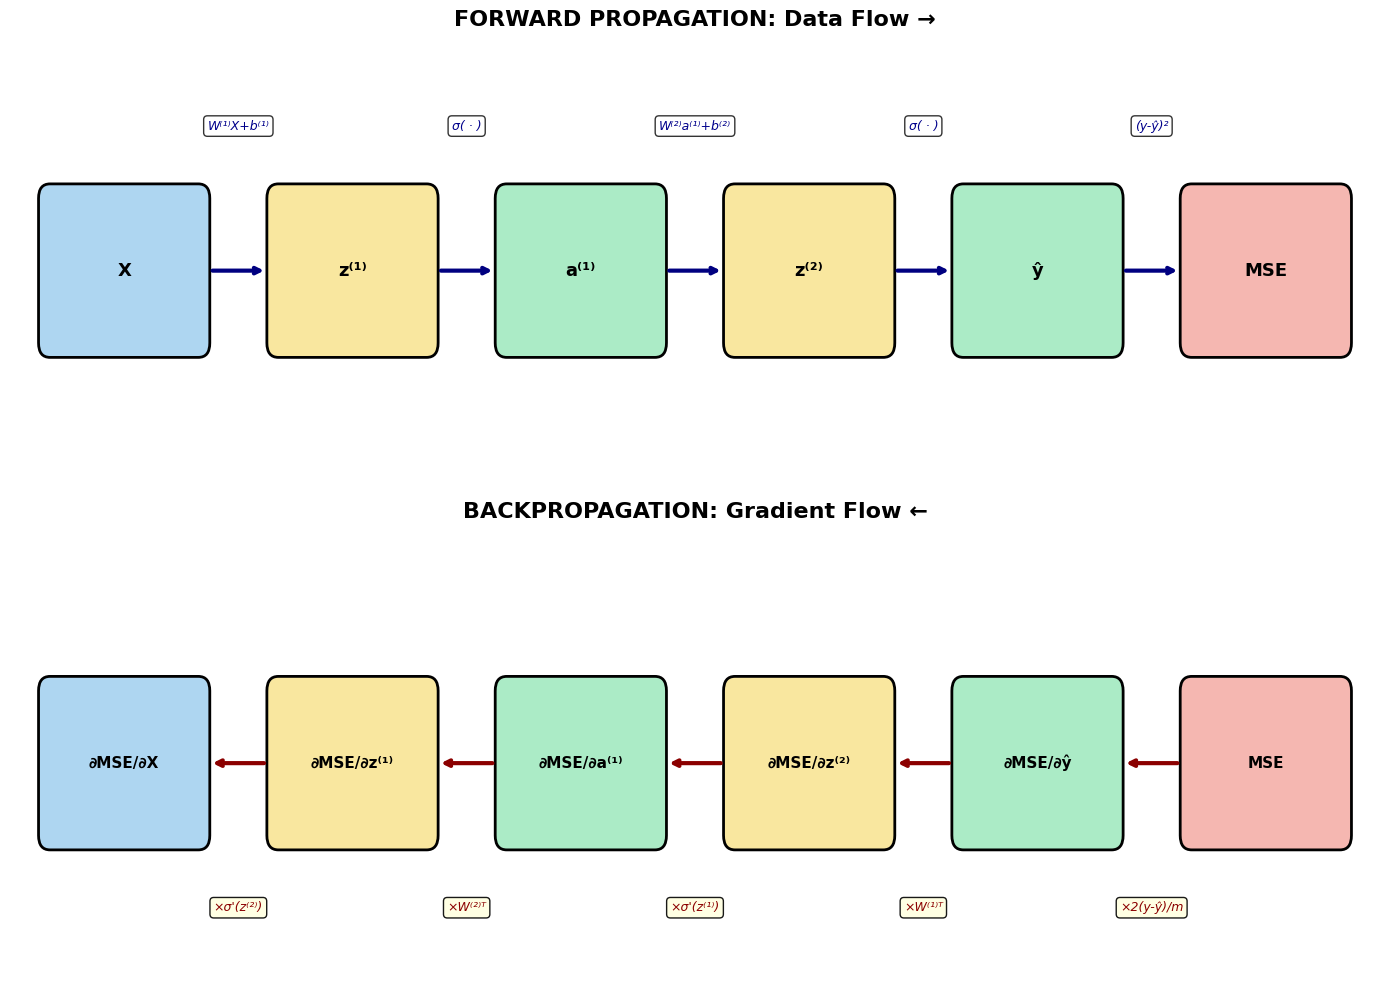

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Define positions
x_positions = [1, 3, 5, 7, 9, 11]
y_center = 2

# Box properties
box_width = 1.3
box_height = 1

# Colors
colors = ['#AED6F1', '#F9E79F', '#ABEBC6', '#F9E79F', '#ABEBC6', '#F5B7B1']
labels = ['X', 'z⁽¹⁾', 'a⁽¹⁾', 'z⁽²⁾', 'ŷ', 'MSE']

# ===== FORWARD PROPAGATION =====
ax1.set_title('FORWARD PROPAGATION: Data Flow →', fontsize=16, fontweight='bold', pad=20)

for i, (x, label, color) in enumerate(zip(x_positions, labels, colors)):
    rect = mpatches.FancyBboxPatch((x - box_width/2, y_center - box_height/2),
                                    box_width, box_height,
                                    boxstyle="round,pad=0.1",
                                    edgecolor='black', facecolor=color, linewidth=2)
    ax1.add_patch(rect)
    ax1.text(x, y_center, label, ha='center', va='center',
            fontsize=13, fontweight='bold')

# Forward arrows
for i in range(len(x_positions) - 1):
    ax1.annotate('', xy=(x_positions[i+1] - box_width/2 - 0.1, y_center),
                xytext=(x_positions[i] + box_width/2 + 0.1, y_center),
                arrowprops=dict(arrowstyle='->', lw=3, color='navy'))

# Add operation labels
operations = ['W⁽¹⁾X+b⁽¹⁾', 'σ( · )', 'W⁽²⁾a⁽¹⁾+b⁽²⁾', 'σ( · )', '(y-ŷ)²']
for i, op in enumerate(operations):
    mid_x = (x_positions[i] + x_positions[i+1]) / 2
    ax1.text(mid_x, y_center + 1, op, ha='center', va='center',
            fontsize=9, style='italic', color='darkblue',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlim(0, 12)
ax1.set_ylim(0.5, 3.5)
ax1.axis('off')

# ===== BACKPROPAGATION =====
ax2.set_title('BACKPROPAGATION: Gradient Flow ←', fontsize=16, fontweight='bold', pad=20)

gradient_labels = ['∂MSE/∂X', '∂MSE/∂z⁽¹⁾', '∂MSE/∂a⁽¹⁾', '∂MSE/∂z⁽²⁾', '∂MSE/∂ŷ', 'MSE']

for i, (x, label, color) in enumerate(zip(x_positions, gradient_labels, colors)):
    rect = mpatches.FancyBboxPatch((x - box_width/2, y_center - box_height/2),
                                    box_width, box_height,
                                    boxstyle="round,pad=0.1",
                                    edgecolor='black', facecolor=color, linewidth=2)
    ax2.add_patch(rect)
    ax2.text(x, y_center, label, ha='center', va='center',
            fontsize=11, fontweight='bold')

# Backward arrows (red)
for i in range(len(x_positions) - 1, 0, -1):
    ax2.annotate('', xy=(x_positions[i-1] + box_width/2 + 0.1, y_center),
                xytext=(x_positions[i] - box_width/2 - 0.1, y_center),
                arrowprops=dict(arrowstyle='->', lw=3, color='darkred'))

# Add chain rule labels
chain_rules = ['×σ\'(z⁽²⁾)', '×W⁽²⁾ᵀ', '×σ\'(z⁽¹⁾)', '×W⁽¹⁾ᵀ', '×2(y-ŷ)/m']
chain_rules.reverse()
for i, rule in enumerate(chain_rules):
    mid_x = (x_positions[-(i+1)] + x_positions[-(i+2)]) / 2
    ax2.text(mid_x, y_center - 1, rule, ha='center', va='center',
            fontsize=9, style='italic', color='darkred',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax2.set_xlim(0, 12)
ax2.set_ylim(0.5, 3.5)
ax2.axis('off')

plt.tight_layout()
plt.show()

## Calculando gradientes: ¿cuánto contribuye cada peso al error?

Ahora derivemos las ecuaciones de backpropagation paso a paso. Comenzaremos desde la salida y trabajaremos hacia atrás.

### Notación

Usaremos la siguiente notación para los gradientes:
- **δ⁽ˡ⁾**: Error en la capa l (también llamado "delta")
- **∂MSE/∂W⁽ˡ⁾**: Gradiente del MSE con respecto a los pesos de la capa l
- **∂MSE/∂b⁽ˡ⁾**: Gradiente del MSE con respecto a los sesgos de la capa l

### Paso 1: Gradiente en la capa de salida

Comenzamos calculando cómo cambia el MSE con respecto a la pre-activación de la salida **z⁽²⁾**.

**Recordatorio del forward propagation:**
```
z⁽²⁾ = W⁽²⁾ · a⁽¹⁾ + b⁽²⁾
ŷ = σ(z⁽²⁾)
MSE = (1/m) · Σ(y - ŷ)²
```

**Aplicando la regla de la cadena:**

```
∂MSE/∂z⁽²⁾ = (∂MSE/∂ŷ) · (∂ŷ/∂z⁽²⁾)
```

Ya calculamos en la sección anterior:
```
∂MSE/∂ŷ = -(2/m) · (y - ŷ)
```

Y la derivada de la sigmoide:
```
∂ŷ/∂z⁽²⁾ = σ'(z⁽²⁾) = σ(z⁽²⁾) · (1 - σ(z⁽²⁾)) = ŷ · (1 - ŷ)
```

Multiplicando:
```
∂MSE/∂z⁽²⁾ = -(2/m) · (y - ŷ) · ŷ · (1 - ŷ)
```

A este gradiente lo llamamos **δ⁽²⁾** (delta de la capa de salida):

```
δ⁽²⁾ = -(2/m) · (y - ŷ) · ŷ · (1 - ŷ)
```

**Dimensiones:** Si tenemos m ejemplos y 1 neurona de salida, δ⁽²⁾ tiene dimensión (m, 1).

### Paso 2: Gradientes de W⁽²⁾ y b⁽²⁾

Ahora que tenemos δ⁽²⁾, podemos calcular los gradientes de los parámetros de la capa de salida.

**Para W⁽²⁾:**
```
∂MSE/∂W⁽²⁾ = (∂MSE/∂z⁽²⁾) · (∂z⁽²⁾/∂W⁽²⁾)
            = δ⁽²⁾ · (∂z⁽²⁾/∂W⁽²⁾)
```

Como z⁽²⁾ = W⁽²⁾ · a⁽¹⁾ + b⁽²⁾, entonces:
```
∂z⁽²⁾/∂W⁽²⁾ = a⁽¹⁾
```

Por lo tanto:
```
∂MSE/∂W⁽²⁾ = a⁽¹⁾ᵀ · δ⁽²⁾
```

**Dimensiones:** (4, m) · (m, 1) = (4, 1) ✓

**Para b⁽²⁾:**
```
∂MSE/∂b⁽²⁾ = δ⁽²⁾
```

Pero como b⁽²⁾ es un escalar (o vector de dimensión (1,)) y δ⁽²⁾ tiene dimensión (m, 1), sumamos sobre todos los ejemplos:
```
∂MSE/∂b⁽²⁾ = Σ δ⁽²⁾
```

**Dimensiones:** Suma de (m, 1) → (1, 1) ✓

### Paso 3: Propagando el error a la capa oculta

Ahora necesitamos propagar el error hacia la capa oculta. Queremos calcular δ⁽¹⁾.

**Aplicando la regla de la cadena:**
```
∂MSE/∂z⁽¹⁾ = (∂MSE/∂z⁽²⁾) · (∂z⁽²⁾/∂a⁽¹⁾) · (∂a⁽¹⁾/∂z⁽¹⁾)
```

Desglosando:
- Ya tenemos: **∂MSE/∂z⁽²⁾ = δ⁽²⁾**
- **∂z⁽²⁾/∂a⁽¹⁾ = W⁽²⁾** (porque z⁽²⁾ = W⁽²⁾ · a⁽¹⁾ + b⁽²⁾)
- **∂a⁽¹⁾/∂z⁽¹⁾ = σ'(z⁽¹⁾) = a⁽¹⁾ · (1 - a⁽¹⁾)**

Por lo tanto:
```
δ⁽¹⁾ = (δ⁽²⁾ · W⁽²⁾ᵀ) ⊙ a⁽¹⁾ ⊙ (1 - a⁽¹⁾)
```

donde ⊙ denota el producto elemento a elemento (Hadamard product).

**Dimensiones:**
- δ⁽²⁾ · W⁽²⁾ᵀ: (m, 1) · (1, 4) = (m, 4)
- Producto elemento a elemento con a⁽¹⁾ ⊙ (1 - a⁽¹⁾): (m, 4) ⊙ (m, 4) = (m, 4) ✓

### Paso 4: Gradientes de W⁽¹⁾ y b⁽¹⁾

Finalmente, calculamos los gradientes de los parámetros de la capa oculta.

**Para W⁽¹⁾:**
```
∂MSE/∂W⁽¹⁾ = Xᵀ · δ⁽¹⁾
```

**Dimensiones:** (2, m) · (m, 4) = (2, 4) ✓

**Para b⁽¹⁾:**
```
∂MSE/∂b⁽¹⁾ = Σ δ⁽¹⁾
```

**Dimensiones:** Suma de (m, 4) → (1, 4) ✓

### Resumen de las ecuaciones de backpropagation

```python
"""
BACKPROPAGATION EQUATIONS (vectorized for all m samples):

# Output layer gradients
δ⁽²⁾ = -(2/m) · (y - ŷ) · ŷ · (1 - ŷ)                    # (m, 1)
∂MSE/∂W⁽²⁾ = a⁽¹⁾ᵀ · δ⁽²⁾                                 # (4, 1)
∂MSE/∂b⁽²⁾ = Σ δ⁽²⁾                                       # (1, 1)

# Hidden layer gradients
δ⁽¹⁾ = (δ⁽²⁾ · W⁽²⁾ᵀ) ⊙ a⁽¹⁾ ⊙ (1 - a⁽¹⁾)                 # (m, 4)
∂MSE/∂W⁽¹⁾ = Xᵀ · δ⁽¹⁾                                    # (2, 4)
∂MSE/∂b⁽¹⁾ = Σ δ⁽¹⁾                                       # (1, 4)
"""
```

## Propagando el error hacia atrás

Implementemos backpropagation completo en Python:

In [15]:
import numpy as np

def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of sigmoid function."""
    s = sigmoid(z)
    return s * (1 - s)

def backward_propagation(X, y_true, cache, W2):
    """
    Perform backpropagation to compute gradients.

    Args:
        X: Input data (m, 2)
        y_true: True labels (m, 1)
        cache: Dictionary with forward prop values (z1, a1, z2, y_pred)
        W2: Weights hidden->output (4, 1)

    Returns:
        gradients: Dictionary containing dW1, db1, dW2, db2
    """
    m = X.shape[0]  # Number of samples

    # Extract values from cache
    z1 = cache['z1']        # (m, 4)
    a1 = cache['a1']        # (m, 4)
    z2 = cache['z2']        # (m, 1)
    y_pred = cache['y_pred'] # (m, 1)

    # ===== BACKWARD PASS =====

    # Output layer gradients
    # δ⁽²⁾ = -(2/m) · (y - ŷ) · ŷ · (1 - ŷ)
    delta2 = -(2 / m) * (y_true - y_pred) * y_pred * (1 - y_pred)  # (m, 1)

    # Gradients for W2 and b2
    dW2 = np.dot(a1.T, delta2)        # (4, m) · (m, 1) = (4, 1)
    db2 = np.sum(delta2, axis=0, keepdims=True)  # (1, 1)

    # Hidden layer gradients
    # δ⁽¹⁾ = (δ⁽²⁾ · W⁽²⁾ᵀ) ⊙ a⁽¹⁾ ⊙ (1 - a⁽¹⁾)
    delta1 = np.dot(delta2, W2.T) * a1 * (1 - a1)  # (m, 1)·(1, 4) = (m, 4), then ⊙

    # Gradients for W1 and b1
    dW1 = np.dot(X.T, delta1)         # (2, m) · (m, 4) = (2, 4)
    db1 = np.sum(delta1, axis=0, keepdims=True)  # (1, 4)

    # Store gradients in dictionary
    gradients = {
        'dW1': dW1,
        'db1': db1,
        'dW2': dW2,
        'db2': db2
    }

    return gradients

# ===== COMPLETE EXAMPLE =====

# XOR dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y_true = np.array([[0], [1], [1], [0]])

# Initialize parameters
np.random.seed(42)
W1 = np.random.randn(2, 4) * 0.5
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.5
b2 = np.zeros((1, 1))

print("="*70)
print("BACKPROPAGATION - COMPLETE EXAMPLE")
print("="*70)

# Forward propagation
print("\n--- FORWARD PROPAGATION ---")
z1 = np.dot(X, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
y_pred = sigmoid(z2)

cache = {
    'X': X,
    'z1': z1,
    'a1': a1,
    'z2': z2,
    'y_pred': y_pred
}

print("Predictions:", y_pred.T)
print("True labels:", y_true.T)

# Compute cost
mse = (1 / X.shape[0]) * np.sum((y_true - y_pred) ** 2)
print(f"MSE: {mse:.6f}")

# Backward propagation
print("\n--- BACKWARD PROPAGATION ---")
gradients = backward_propagation(X, y_true, cache, W2)

print("\nGradients computed:")
print(f"dW2 shape: {gradients['dW2'].shape}, values:\n{gradients['dW2']}")
print(f"\ndb2 shape: {gradients['db2'].shape}, value: {gradients['db2'][0,0]:.6f}")
print(f"\ndW1 shape: {gradients['dW1'].shape}, values:\n{gradients['dW1']}")
print(f"\ndb1 shape: {gradients['db1'].shape}, values:\n{gradients['db1']}")

print("\n" + "="*70)
print("GRADIENT INTERPRETATION")
print("="*70)
print("Negative gradient → parameter should INCREASE")
print("Positive gradient → parameter should DECREASE")
print("Large magnitude → strong influence on cost")
print("Small magnitude → weak influence on cost")

BACKPROPAGATION - COMPLETE EXAMPLE

--- FORWARD PROPAGATION ---
Predictions: [[0.44669943 0.43029337 0.42699871 0.41263144]]
True labels: [[0 1 1 0]]
MSE: 0.255675

--- BACKWARD PROPAGATION ---

Gradients computed:
dW2 shape: (4, 1), values:
[[-0.01801012]
 [-0.01642889]
 [-0.02345704]
 [-0.02378061]]

db2 shape: (1, 1), value: -0.034721

dW1 shape: (2, 4), values:
[[ 0.00112904 -0.00138634  0.00179967  0.00140993]
 [ 0.00116202 -0.00135758  0.00131838  0.00178703]]

db1 shape: (1, 4), values:
[[ 0.00197336 -0.00236211  0.0020766   0.00211537]]

GRADIENT INTERPRETATION
Negative gradient → parameter should INCREASE
Positive gradient → parameter should DECREASE
Large magnitude → strong influence on cost
Small magnitude → weak influence on cost


### Verificación de gradientes (Gradient Checking)

Una técnica útil para verificar que nuestra implementación de backpropagation es correcta es usar la **aproximación numérica del gradiente**:

```
∂f/∂θ ≈ [f(θ + ε) - f(θ - ε)] / (2ε)
```

donde ε es un valor pequeño (típicamente 10⁻⁷).

In [16]:
def gradient_check(X, y_true, W1, b1, W2, b2, epsilon=1e-7):
    """
    Numerically verify that backpropagation gradients are correct.

    Args:
        X, y_true: Data
        W1, b1, W2, b2: Parameters
        epsilon: Small value for numerical approximation

    Returns:
        relative_error: Difference between analytical and numerical gradients
    """
    # Forward pass and analytical gradients
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)

    cache = {'z1': z1, 'a1': a1, 'z2': z2, 'y_pred': y_pred}
    gradients = backward_propagation(X, y_true, cache, W2)

    # Numerical gradient for one weight (e.g., W1[0,0])
    def compute_cost(W1_val):
        W1_temp = W1.copy()
        W1_temp[0, 0] = W1_val
        z1 = np.dot(X, W1_temp) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        y_pred = sigmoid(z2)
        return (1 / X.shape[0]) * np.sum((y_true - y_pred) ** 2)

    # Numerical gradient
    grad_numerical = (compute_cost(W1[0,0] + epsilon) - compute_cost(W1[0,0] - epsilon)) / (2 * epsilon)

    # Analytical gradient
    grad_analytical = gradients['dW1'][0, 0]

    # Compute relative error
    relative_error = abs(grad_numerical - grad_analytical) / max(abs(grad_numerical), abs(grad_analytical))

    print("="*70)
    print("GRADIENT CHECKING")
    print("="*70)
    print(f"Analytical gradient (backprop): {grad_analytical:.10f}")
    print(f"Numerical gradient (approx):    {grad_numerical:.10f}")
    print(f"Relative error:                 {relative_error:.10e}")
    print(f"\nGradient check: {'PASS ✓' if relative_error < 1e-5 else 'FAIL ✗'}")
    print("(Error should be < 1e-5 for correct implementation)")

    return relative_error

# Run gradient check
error = gradient_check(X, y_true, W1, b1, W2, b2)

GRADIENT CHECKING
Analytical gradient (backprop): 0.0011290382
Numerical gradient (approx):    0.0011290385
Relative error:                 3.0863945433e-07

Gradient check: PASS ✓
(Error should be < 1e-5 for correct implementation)


Si la implementación de backpropagation es correcta, el error relativo debería ser menor que 10⁻⁵. Este es un test esencial que todo implementador de redes neuronales debería hacer al menos una vez.

---

Ahora que entendemos cómo calcular los gradientes, el siguiente paso es **usar estos gradientes para actualizar los pesos**. Eso lo veremos en la siguiente sección sobre el Descenso del Gradiente.

# 6. Descenso del Gradiente

Ahora que sabemos cómo calcular los gradientes mediante backpropagation, el siguiente paso es usar esta información para **mejorar los pesos**. Aquí es donde entra el algoritmo de **Descenso del Gradiente** (Gradient Descent), el método de optimización que guía el aprendizaje de la red.

El descenso del gradiente es como descender por una montaña en la niebla: no podemos ver el valle completo, pero podemos sentir la pendiente bajo nuestros pies y dar pasos en la dirección de mayor descenso.

## Actualizando pesos en la dirección correcta

### La intuición geométrica

Imaginemos que el MSE es una superficie en un espacio multidimensional donde cada dimensión representa un parámetro de la red (cada peso y sesgo). Nuestro objetivo es encontrar el punto más bajo de esta superficie: el **mínimo global**.

El **gradiente** ∂MSE/∂θ nos indica:
- **Dirección:** Hacia dónde crece más rápidamente el error
- **Magnitud:** Qué tan pronunciada es la pendiente

Por lo tanto, para **reducir** el error, debemos movernos en la **dirección opuesta al gradiente** (de ahí el signo negativo en la regla de actualización).

Visualicemos esta idea:

```python
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a simple 2D cost surface (bowl-shaped)
w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)

# Simple quadratic cost function: J(w1, w2) = w1² + w2²
J = W1**2 + W2**2

# Simulate gradient descent path
def gradient_descent_path(start, learning_rate, num_steps):
    """Simulate gradient descent on J(w1, w2) = w1² + w2²"""
    path = [start]
    current = np.array(start, dtype=float)
    
    for _ in range(num_steps):
        # Gradient of J(w1, w2) = w1² + w2² is [2*w1, 2*w2]
        gradient = 2 * current
        # Update: move opposite to gradient
        current = current - learning_rate * gradient
        path.append(current.copy())
    
    return np.array(path)

# Generate paths with different learning rates
path_slow = gradient_descent_path([2.5, 2.5], learning_rate=0.1, num_steps=20)
path_good = gradient_descent_path([2.5, 2.5], learning_rate=0.3, num_steps=15)
path_fast = gradient_descent_path([2.5, 2.5], learning_rate=0.9, num_steps=30)

# Create visualization
fig = plt.figure(figsize=(16, 5))

# ===== 3D SURFACE PLOT =====
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(W1, W2, J, cmap='viridis', alpha=0.6, edgecolor='none')
ax1.set_xlabel('w₁', fontsize=11, fontweight='bold')
ax1.set_ylabel('w₂', fontsize=11, fontweight='bold')
ax1.set_zlabel('Cost J(w)', fontsize=11, fontweight='bold')
ax1.set_title('Cost Surface\n(3D View)', fontsize=13, fontweight='bold')
ax1.view_init(elev=25, azim=45)

# Plot gradient descent path on 3D surface
path_costs = path_good[:, 0]**2 + path_good[:, 1]**2
ax1.plot(path_good[:, 0], path_good[:, 1], path_costs,
         'ro-', linewidth=2, markersize=6, label='Gradient Descent Path')
ax1.scatter([0], [0], [0], color='green', s=200, marker='*',
           edgecolors='black', linewidths=2, label='Global Minimum', zorder=10)

# ===== CONTOUR PLOT =====
ax2 = fig.add_subplot(132)
contour = ax2.contour(W1, W2, J, levels=20, cmap='viridis', alpha=0.6)
ax2.clabel(contour, inline=True, fontsize=8)

# Plot gradient descent path
ax2.plot(path_good[:, 0], path_good[:, 1], 'ro-', linewidth=2,
         markersize=8, label='GD Path (α=0.3)', zorder=5)
ax2.scatter([2.5], [2.5], color='red', s=150, marker='X',
           edgecolors='black', linewidths=2, label='Start', zorder=10)
ax2.scatter([0], [0], color='green', s=200, marker='*',
           edgecolors='black', linewidths=2, label='Global Minimum', zorder=10)

# Draw some gradient arrows
for i in [0, 3, 6]:
    pos = path_good[i]
    gradient = 2 * pos
    # Arrow pointing opposite to gradient (descent direction)
    ax2.arrow(pos[0], pos[1], -0.3*gradient[0], -0.3*gradient[1],
             head_width=0.15, head_length=0.1, fc='blue', ec='blue',
             alpha=0.6, linewidth=2)

ax2.set_xlabel('w₁', fontsize=11, fontweight='bold')
ax2.set_ylabel('w₂', fontsize=11, fontweight='bold')
ax2.set_title('Gradient Descent\n(Contour View)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# ===== COMPARISON OF LEARNING RATES =====
ax3 = fig.add_subplot(133)
contour = ax3.contour(W1, W2, J, levels=20, cmap='viridis', alpha=0.4)

ax3.plot(path_slow[:, 0], path_slow[:, 1], 'b^-', linewidth=2,
         markersize=6, label='α=0.1 (too slow)', alpha=0.8)
ax3.plot(path_good[:, 0], path_good[:, 1], 'go-', linewidth=2,
         markersize=6, label='α=0.3 (good)', alpha=0.8)
ax3.plot(path_fast[:, 0], path_fast[:, 1], 'rs-', linewidth=2,
         markersize=6, label='α=0.9 (oscillates)', alpha=0.8)

ax3.scatter([2.5], [2.5], color='red', s=150, marker='X',
           edgecolors='black', linewidths=2, label='Start', zorder=10)
ax3.scatter([0], [0], color='green', s=200, marker='*',
           edgecolors='black', linewidths=2, label='Global Minimum', zorder=10)

ax3.set_xlabel('w₁', fontsize=11, fontweight='bold')
ax3.set_ylabel('w₂', fontsize=11, fontweight='bold')
ax3.set_title('Effect of Learning Rate α\n(Contour View)', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

plt.tight_layout()
plt.show()
```

### La regla de actualización

La regla de actualización del descenso del gradiente es sorprendentemente simple:

```
θ_nuevo = θ_viejo - α · ∂MSE/∂θ
```

donde:
- **θ**: Parámetro a actualizar (puede ser cualquier peso o sesgo)
- **α**: Learning rate (tasa de aprendizaje)
- **∂MSE/∂θ**: Gradiente del MSE con respecto a θ

Para nuestra red 2-4-1, las actualizaciones específicas son:

```
W⁽¹⁾ ← W⁽¹⁾ - α · ∂MSE/∂W⁽¹⁾
b⁽¹⁾ ← b⁽¹⁾ - α · ∂MSE/∂b⁽¹⁾
W⁽²⁾ ← W⁽²⁾ - α · ∂MSE/∂W⁽²⁾
b⁽²⁾ ← b⁽²⁾ - α · ∂MSE/∂b⁽²⁾
```

## El Learning Rate: equilibrio entre velocidad y estabilidad

El **learning rate** (α) es uno de los hiperparámetros más importantes en el entrenamiento de redes neuronales. Controla **qué tan grandes son los pasos** que damos en la dirección del gradiente.

### Efectos de diferentes learning rates

| Learning Rate | Comportamiento | Problema |
|--------------|----------------|----------|
| **Muy pequeño** (α ≈ 0.001) | Descenso lento y estable | Entrenamiento muy lento, puede estancarse |
| **Óptimo** (α ≈ 0.1 - 0.5) | Convergencia rápida y estable | Ninguno (ideal) |
| **Muy grande** (α ≈ 2.0) | Pasos demasiado grandes | Oscilaciones, divergencia, nunca converge |

Visualicemos cómo el learning rate afecta la convergencia:

```python
def train_with_learning_rate(X, y_true, learning_rate, epochs):
    """
    Train network and record cost history.
    
    Args:
        X: Input data (4, 2)
        y_true: True labels (4, 1)
        learning_rate: Learning rate value
        epochs: Number of training iterations
    
    Returns:
        cost_history: List of MSE values over epochs
    """
    # Initialize parameters
    np.random.seed(42)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))
    
    cost_history = []
    m = X.shape[0]
    
    for epoch in range(epochs):
        # Forward propagation
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        y_pred = sigmoid(z2)
        
        # Compute cost
        cost = (1 / m) * np.sum((y_true - y_pred) ** 2)
        cost_history.append(cost)
        
        # Backward propagation
        delta2 = -(2 / m) * (y_true - y_pred) * y_pred * (1 - y_pred)
        dW2 = np.dot(a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)
        
        delta1 = np.dot(delta2, W2.T) * a1 * (1 - a1)
        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)
        
        # Update parameters (GRADIENT DESCENT)
        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1
        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2
    
    return cost_history

# XOR dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_true = np.array([[0], [1], [1], [0]])

# Test different learning rates
learning_rates = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
epochs = 500

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    cost_history = train_with_learning_rate(X, y_true, lr, epochs)
    
    ax = axes[idx]
    ax.plot(cost_history, linewidth=2, color='blue', alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('MSE', fontsize=11, fontweight='bold')
    ax.set_title(f'Learning Rate α = {lr}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add final cost annotation
    final_cost = cost_history[-1]
    if final_cost < 0.05:
        color = 'green'
        status = 'Converged ✓'
    elif final_cost < 0.2:
        color = 'orange'
        status = 'Slow convergence'
    else:
        color = 'red'
        status = 'Failed to converge ✗'
    
    ax.text(0.95, 0.95, f'Final MSE: {final_cost:.4f}\n{status}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            horizontalalignment='right', bbox=dict(boxstyle='round',
            facecolor=color, alpha=0.3))
    
    # Set appropriate y-axis limits
    if np.max(cost_history) > 1:
        ax.set_ylim(0, min(np.max(cost_history) * 1.1, 10))
    else:
        ax.set_ylim(0, max(cost_history) * 1.1)

plt.suptitle('Effect of Learning Rate on Training Convergence',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
```

### Estrategias para elegir el learning rate

En la práctica, hay varias estrategias para elegir un buen learning rate:

1. **Prueba y error:** Probar valores en el rango [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
2. **Learning rate schedule:** Comenzar con un valor alto y reducirlo gradualmente
3. **Adaptive learning rates:** Algoritmos como Adam, RMSprop que ajustan α automáticamente
4. **Learning rate finder:** Entrenar brevemente con diferentes α y elegir el óptimo

Para nuestro problema XOR, valores entre **0.5 y 1.0** funcionan bien.

## Iteración tras iteración: el proceso de entrenamiento

El entrenamiento de una red neuronal es un proceso **iterativo**. Cada iteración completa (llamada **epoch**) consiste en:

1. **Forward Propagation:** Calcular predicciones
2. **Calcular Loss:** Medir el error (MSE)
3. **Backward Propagation:** Calcular gradientes
4. **Gradient Descent:** Actualizar parámetros
5. **Repetir**

Veamos una implementación completa del bucle de entrenamiento:

```python
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def train_network(X, y_true, learning_rate=0.5, epochs=2000, print_every=200):
    """
    Complete training loop for XOR neural network.
    
    Args:
        X: Input data (4, 2)
        y_true: True labels (4, 1)
        learning_rate: Learning rate for gradient descent
        epochs: Number of training iterations
        print_every: Print progress every N epochs
    
    Returns:
        parameters: Trained weights and biases
        cost_history: List of MSE values
    """
    # Initialize parameters randomly
    np.random.seed(42)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))
    
    m = X.shape[0]
    cost_history = []
    
    print("="*80)
    print("TRAINING NEURAL NETWORK FOR XOR")
    print("="*80)
    print(f"Architecture: 2-4-1")
    print(f"Learning rate: {learning_rate}")
    print(f"Epochs: {epochs}")
    print(f"Training samples: {m}")
    print("="*80)
    
    for epoch in range(epochs):
        # ===== FORWARD PROPAGATION =====
        z1 = np.dot(X, W1) + b1           # (4, 2) · (2, 4) + (1, 4) = (4, 4)
        a1 = sigmoid(z1)                   # (4, 4)
        z2 = np.dot(a1, W2) + b2          # (4, 4) · (4, 1) + (1, 1) = (4, 1)
        y_pred = sigmoid(z2)               # (4, 1)
        
        # ===== COMPUTE COST =====
        cost = (1 / m) * np.sum((y_true - y_pred) ** 2)
        cost_history.append(cost)
        
        # ===== BACKWARD PROPAGATION =====
        # Output layer gradients
        delta2 = -(2 / m) * (y_true - y_pred) * y_pred * (1 - y_pred)
        dW2 = np.dot(a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        delta1 = np.dot(delta2, W2.T) * a1 * (1 - a1)
        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)
        
        # ===== GRADIENT DESCENT (PARAMETER UPDATE) =====
        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1
        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2
        
        # Print progress
        if epoch % print_every == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:4d} | MSE: {cost:.6f}")
    
    # Store trained parameters
    parameters = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }
    
    print("="*80)
    print("TRAINING COMPLETE")
    print("="*80)
    
    return parameters, cost_history

# Train the network
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_true = np.array([[0], [1], [1], [0]])

parameters, cost_history = train_network(X, y_true, learning_rate=0.5, epochs=2000)
```

### Visualización del proceso de entrenamiento

Veamos cómo evoluciona el entrenamiento en múltiples dimensiones:

```python
# Create comprehensive training visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ===== PLOT 1: LOSS CURVE =====
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cost_history, linewidth=2, color='blue', alpha=0.7)
ax1.axhline(y=0.01, color='green', linestyle='--', linewidth=2,
            label='Target (MSE < 0.01)', alpha=0.7)
ax1.fill_between(range(len(cost_history)), 0, cost_history, alpha=0.2, color='blue')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax1.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_yscale('log')

# Annotate key points
epochs_to_annotate = [0, len(cost_history)//4, len(cost_history)//2, len(cost_history)-1]
for ep in epochs_to_annotate:
    ax1.annotate(f'{cost_history[ep]:.4f}',
                xy=(ep, cost_history[ep]),
                xytext=(ep, cost_history[ep]*2),
                arrowprops=dict(arrowstyle='->', color='red', lw=1),
                fontsize=9, color='red', fontweight='bold')

# ===== PLOT 2: PREDICTIONS EVOLUTION =====
ax2 = fig.add_subplot(gs[1, 0])

# Get predictions at different stages
stages_epochs = [0, 100, 500, 1000, 1999]
stage_names = ['Init', '100', '500', '1000', 'Final']

# Re-train to get intermediate predictions (for visualization)
np.random.seed(42)
W1_temp = np.random.randn(2, 4) * 0.5
b1_temp = np.zeros((1, 4))
W2_temp = np.random.randn(4, 1) * 0.5
b2_temp = np.zeros((1, 1))

predictions_over_time = []
for target_epoch in stages_epochs:
    for _ in range(target_epoch + 1 if target_epoch == 0 else 1):
        z1 = np.dot(X, W1_temp) + b1_temp
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2_temp) + b2_temp
        y_pred = sigmoid(z2)
        
        if _ < target_epoch:  # Update only if not at target
            delta2 = -(2 / X.shape[0]) * (y_true - y_pred) * y_pred * (1 - y_pred)
            dW2 = np.dot(a1.T, delta2)
            db2 = np.sum(delta2, axis=0, keepdims=True)
            delta1 = np.dot(delta2, W2_temp.T) * a1 * (1 - a1)
            dW1 = np.dot(X.T, delta1)
            db1 = np.sum(delta1, axis=0, keepdims=True)
            W1_temp -= 0.5 * dW1
            b1_temp -= 0.5 * db1
            W2_temp -= 0.5 * dW2
            b2_temp -= 0.5 * db2
    
    predictions_over_time.append(y_pred.flatten())

x_pos = np.arange(4)
width = 0.15
for i, (preds, name) in enumerate(zip(predictions_over_time, stage_names)):
    offset = width * (i - 2)
    colors = ['green' if abs(pred - true) < 0.1 else 'orange' if abs(pred - true) < 0.3 else 'red'
              for pred, true in zip(preds, y_true.flatten())]
    ax2.bar(x_pos + offset, preds, width, label=f'Epoch {name}', alpha=0.7)

ax2.set_xlabel('XOR Input', fontsize=11, fontweight='bold')
ax2.set_ylabel('Prediction', fontsize=11, fontweight='bold')
ax2.set_title('Predictions Evolution', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0'])
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1)

# ===== PLOT 3: FINAL PREDICTIONS =====
ax3 = fig.add_subplot(gs[1, 1])

# Final predictions with trained network
z1_final = np.dot(X, parameters['W1']) + parameters['b1']
a1_final = sigmoid(z1_final)
z2_final = np.dot(a1_final, parameters['W2']) + parameters['b2']
y_pred_final = sigmoid(z2_final)

inputs_labels = ['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0']
colors = ['green' if abs(pred - true) < 0.1 else 'red'
          for pred, true in zip(y_pred_final.flatten(), y_true.flatten())]

bars = ax3.bar(inputs_labels, y_pred_final.flatten(), color=colors,
               alpha=0.7, edgecolor='black', linewidth=2)
ax3.axhline(y=0.5, color='blue', linestyle='--', linewidth=2,
            label='Decision threshold', alpha=0.7)

for i, (bar, pred, true) in enumerate(zip(bars, y_pred_final.flatten(), y_true.flatten())):
    height = bar.get_height()
    predicted_class = 1 if pred >= 0.5 else 0
    correct = '✓' if predicted_class == true else '✗'
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{pred:.4f}\n→ {predicted_class} {correct}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_xlabel('Input → True Label', fontsize=11, fontweight='bold')
ax3.set_ylabel('Final Prediction', fontsize=11, fontweight='bold')
ax3.set_title('Final Predictions (Trained Network)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 1.15)

# ===== PLOT 4: LEARNING RATE COMPARISON =====
ax4 = fig.add_subplot(gs[2, :])

learning_rates_compare = [0.1, 0.5, 1.0, 2.0]
colors_lr = ['blue', 'green', 'orange', 'red']

for lr, color in zip(learning_rates_compare, colors_lr):
    history = train_with_learning_rate(X, y_true, lr, 500)
    ax4.plot(history, linewidth=2, color=color, alpha=0.7, label=f'α = {lr}')

ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax4.set_title('Learning Rate Comparison', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.set_yscale('log')

plt.suptitle('Complete Training Process Visualization', fontsize=18, fontweight='bold', y=0.995)
plt.show()

# Print final results
print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(f"Final MSE: {cost_history[-1]:.8f}")
print("\nFinal Predictions:")
for i, (inp, true, pred) in enumerate(zip(X, y_true, y_pred_final)):
    pred_class = 1 if pred[0] >= 0.5 else 0
    status = "✓ CORRECT" if pred_class == true[0] else "✗ WRONG"
    print(f"  Input {inp} → True: {true[0]}, Predicted: {pred[0]:.6f} ({pred_class}) {status}")
```

### Criterios de parada (Stopping Criteria)

¿Cuándo detenemos el entrenamiento? Algunas opciones:

1. **Número fijo de epochs:** Entrenar durante N iteraciones (simple pero no óptimo)
2. **Umbral de error:** Parar cuando MSE < 0.01
3. **Early stopping:** Monitorear un conjunto de validación y parar cuando el error deja de mejorar
4. **Convergencia del gradiente:** Parar cuando los gradientes son muy pequeños

```python
def train_with_early_stopping(X, y_true, learning_rate=0.5,
                               max_epochs=5000, target_mse=0.01, patience=100):
    """
    Train with early stopping based on target MSE.
    
    Args:
        patience: Stop if no improvement for N consecutive epochs
    """
    np.random.seed(42)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))
    
    m = X.shape[0]
    cost_history = []
    best_cost = float('inf')
    patience_counter = 0
    
    for epoch in range(max_epochs):
        # Forward propagation
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        y_pred = sigmoid(z2)
        
        # Compute cost
        cost = (1 / m) * np.sum((y_true - y_pred) ** 2)
        cost_history.append(cost)
        
        # Check early stopping conditions
        if cost < target_mse:
            print(f"✓ Target MSE reached at epoch {epoch}: {cost:.6f}")
            break
        
        if cost < best_cost:
            best_cost = cost
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"✓ Early stopping at epoch {epoch}: No improvement for {patience} epochs")
            break
        
        # Backward propagation and update
        delta2 = -(2 / m) * (y_true - y_pred) * y_pred * (1 - y_pred)
        dW2 = np.dot(a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)
        delta1 = np.dot(delta2, W2.T) * a1 * (1 - a1)
        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)
        
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
    
    print(f"Training stopped after {epoch+1} epochs")
    print(f"Final MSE: {cost:.8f}")
    
    return cost_history

# Test early stopping
history_early = train_with_early_stopping(X, y_true, learning_rate=0.5, target_mse=0.01)
```

---

Hemos completado el ciclo completo de entrenamiento: forward propagation → calcular loss → backpropagation → gradient descent. En la siguiente sección, implementaremos todo esto desde cero con NumPy para resolver el problema XOR de principio a fin.

# 7. Implementación desde Cero con NumPy

Ha llegado el momento de unir todas las piezas. En esta sección construiremos una implementación completa y funcional de una red neuronal multicapa desde cero, usando únicamente NumPy. Veremos cómo resolver el problema XOR de principio a fin, sin usar ninguna librería de Machine Learning.

Esta implementación servirá como referencia para entender exactamente qué ocurre "bajo el capó" de frameworks como TensorFlow o PyTorch.

## Inicialización de pesos y sesgos

La inicialización de los parámetros es más importante de lo que podría parecer. Una mala inicialización puede causar que la red no aprenda nada o que converja muy lentamente.

### Estrategias de inicialización

**1. Inicialización a cero (❌ MAL):**
```python
W1 = np.zeros((2, 4))  # ¡NO HACER ESTO!
```
**Problema:** Todas las neuronas aprenderán exactamente lo mismo (simetría).

**2. Inicialización aleatoria pequeña (✓ BIEN):**
```python
W1 = np.random.randn(2, 4) * 0.5  # Valores pequeños aleatorios
```
**Ventaja:** Rompe la simetría, valores razonables para sigmoide.

**3. Inicialización Xavier/Glorot (✓✓ MEJOR):**
```python
W1 = np.random.randn(2, 4) * np.sqrt(1 / 2)  # Escalado por √(1/n_in)
```
**Ventaja:** Mantiene la varianza de las activaciones estable.

**4. Inicialización He (✓✓ MEJOR para ReLU):**
```python
W1 = np.random.randn(2, 4) * np.sqrt(2 / 2)  # Escalado por √(2/n_in)
```
**Ventaja:** Óptima para funciones ReLU (no sigmoide).

Para nuestro caso con sigmoide, usaremos **inicialización Xavier** o simplemente **valores aleatorios pequeños**.

### Implementación de la inicialización

```python
import numpy as np

def initialize_parameters(n_input, n_hidden, n_output, method='xavier', seed=42):
    """
    Initialize weights and biases for a 2-layer neural network.
    
    Args:
        n_input: Number of input features
        n_hidden: Number of hidden neurons
        n_output: Number of output neurons
        method: Initialization method ('random', 'xavier', 'he')
        seed: Random seed for reproducibility
    
    Returns:
        parameters: Dictionary containing W1, b1, W2, b2
    """
    np.random.seed(seed)
    
    if method == 'random':
        # Simple random initialization
        W1 = np.random.randn(n_input, n_hidden) * 0.5
        W2 = np.random.randn(n_hidden, n_output) * 0.5
    
    elif method == 'xavier':
        # Xavier/Glorot initialization (good for sigmoid/tanh)
        W1 = np.random.randn(n_input, n_hidden) * np.sqrt(1.0 / n_input)
        W2 = np.random.randn(n_hidden, n_output) * np.sqrt(1.0 / n_hidden)
    
    elif method == 'he':
        # He initialization (good for ReLU)
        W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2.0 / n_input)
        W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2.0 / n_hidden)
    
    else:
        raise ValueError(f"Unknown initialization method: {method}")
    
    # Initialize biases to zero
    b1 = np.zeros((1, n_hidden))
    b2 = np.zeros((1, n_output))
    
    parameters = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }
    
    print("="*70)
    print("PARAMETERS INITIALIZED")
    print("="*70)
    print(f"Initialization method: {method}")
    print(f"W1 shape: {W1.shape} - Range: [{W1.min():.4f}, {W1.max():.4f}]")
    print(f"b1 shape: {b1.shape} - All zeros: {np.all(b1 == 0)}")
    print(f"W2 shape: {W2.shape} - Range: [{W2.min():.4f}, {W2.max():.4f}]")
    print(f"b2 shape: {b2.shape} - All zeros: {np.all(b2 == 0)}")
    print(f"Total parameters: {W1.size + b1.size + W2.size + b2.size}")
    print("="*70)
    
    return parameters

# Test initialization
params = initialize_parameters(n_input=2, n_hidden=4, n_output=1, method='xavier')
```

## Código completo del algoritmo

Ahora implementaremos la clase completa de nuestra red neuronal con todos los métodos necesarios:

```python
import numpy as np
import matplotlib.pyplot as plt

class NeuralNetwork:
    """
    A simple 2-layer neural network (MLP) for binary classification.
    Architecture: input_size -> hidden_size -> output_size
    """
    
    def __init__(self, input_size=2, hidden_size=4, output_size=1,
                 learning_rate=0.5, seed=42):
        """
        Initialize the neural network.
        
        Args:
            input_size: Number of input features
            hidden_size: Number of neurons in hidden layer
            output_size: Number of output neurons
            learning_rate: Learning rate for gradient descent
            seed: Random seed for reproducibility
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # Initialize parameters
        np.random.seed(seed)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # Training history
        self.cost_history = []
        
    def sigmoid(self, z):
        """Sigmoid activation function."""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # Clip to prevent overflow
    
    def sigmoid_derivative(self, z):
        """Derivative of sigmoid function."""
        s = self.sigmoid(z)
        return s * (1 - s)
    
    def forward_propagation(self, X):
        """
        Perform forward propagation.
        
        Args:
            X: Input data (m, input_size)
        
        Returns:
            y_pred: Predictions (m, output_size)
            cache: Dictionary with intermediate values
        """
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1  # (m, hidden_size)
        self.a1 = self.sigmoid(self.z1)          # (m, hidden_size)
        
        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2  # (m, output_size)
        self.y_pred = self.sigmoid(self.z2)            # (m, output_size)
        
        cache = {
            'X': X,
            'z1': self.z1,
            'a1': self.a1,
            'z2': self.z2,
            'y_pred': self.y_pred
        }
        
        return self.y_pred, cache
    
    def compute_cost(self, y_true, y_pred):
        """
        Compute Mean Squared Error.
        
        Args:
            y_true: True labels (m, output_size)
            y_pred: Predictions (m, output_size)
        
        Returns:
            cost: MSE value (scalar)
        """
        m = y_true.shape[0]
        cost = (1 / m) * np.sum((y_true - y_pred) ** 2)
        return cost
    
    def backward_propagation(self, y_true, cache):
        """
        Perform backward propagation.
        
        Args:
            y_true: True labels (m, output_size)
            cache: Dictionary with forward prop values
        
        Returns:
            gradients: Dictionary with dW1, db1, dW2, db2
        """
        m = y_true.shape[0]
        X = cache['X']
        a1 = cache['a1']
        y_pred = cache['y_pred']
        
        # Output layer gradients
        delta2 = -(2 / m) * (y_true - y_pred) * y_pred * (1 - y_pred)
        dW2 = np.dot(a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        delta1 = np.dot(delta2, self.W2.T) * a1 * (1 - a1)
        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)
        
        gradients = {
            'dW1': dW1,
            'db1': db1,
            'dW2': dW2,
            'db2': db2
        }
        
        return gradients
    
    def update_parameters(self, gradients):
        """
        Update parameters using gradient descent.
        
        Args:
            gradients: Dictionary containing gradients
        """
        self.W1 -= self.learning_rate * gradients['dW1']
        self.b1 -= self.learning_rate * gradients['db1']
        self.W2 -= self.learning_rate * gradients['dW2']
        self.b2 -= self.learning_rate * gradients['db2']
    
    def train(self, X, y_true, epochs=2000, print_every=200, verbose=True):
        """
        Train the neural network.
        
        Args:
            X: Training data (m, input_size)
            y_true: True labels (m, output_size)
            epochs: Number of training iterations
            print_every: Print progress every N epochs
            verbose: Whether to print training progress
        
        Returns:
            cost_history: List of cost values over epochs
        """
        if verbose:
            print("="*70)
            print("TRAINING STARTED")
            print("="*70)
            print(f"Architecture: {self.input_size}-{self.hidden_size}-{self.output_size}")
            print(f"Learning rate: {self.learning_rate}")
            print(f"Epochs: {epochs}")
            print(f"Training samples: {X.shape[0]}")
            print("="*70)
        
        self.cost_history = []
        
        for epoch in range(epochs):
            # Forward propagation
            y_pred, cache = self.forward_propagation(X)
            
            # Compute cost
            cost = self.compute_cost(y_true, y_pred)
            self.cost_history.append(cost)
            
            # Backward propagation
            gradients = self.backward_propagation(y_true, cache)
            
            # Update parameters
            self.update_parameters(gradients)
            
            # Print progress
            if verbose and (epoch % print_every == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch:5d} | MSE: {cost:.8f}")
        
        if verbose:
            print("="*70)
            print("TRAINING COMPLETED")
            print("="*70)
            print(f"Final MSE: {self.cost_history[-1]:.8f}")
        
        return self.cost_history
    
    def predict(self, X, threshold=0.5):
        """
        Make predictions on new data.
        
        Args:
            X: Input data (m, input_size)
            threshold: Decision threshold for binary classification
        
        Returns:
            predictions: Binary predictions (m, output_size)
            probabilities: Predicted probabilities (m, output_size)
        """
        probabilities, _ = self.forward_propagation(X)
        predictions = (probabilities >= threshold).astype(int)
        return predictions, probabilities
    
    def evaluate(self, X, y_true, threshold=0.5):
        """
        Evaluate the model on test data.
        
        Args:
            X: Test data (m, input_size)
            y_true: True labels (m, output_size)
            threshold: Decision threshold
        
        Returns:
            accuracy: Accuracy score
        """
        predictions, probabilities = self.predict(X, threshold)
        accuracy = np.mean(predictions == y_true)
        
        print("="*70)
        print("MODEL EVALUATION")
        print("="*70)
        print(f"Accuracy: {accuracy * 100:.2f}%")
        print("\nDetailed Results:")
        print("-"*70)
        for i, (x, true, prob, pred) in enumerate(zip(X, y_true, probabilities, predictions)):
            status = "✓" if pred[0] == true[0] else "✗"
            print(f"Sample {i}: Input={x}, True={true[0]}, "
                  f"Prob={prob[0]:.6f}, Pred={pred[0]} {status}")
        print("="*70)
        
        return accuracy
    
    def get_parameters(self):
        """Return current parameters."""
        return {
            'W1': self.W1.copy(),
            'b1': self.b1.copy(),
            'W2': self.W2.copy(),
            'b2': self.b2.copy()
        }
    
    def set_parameters(self, parameters):
        """Set parameters from dictionary."""
        self.W1 = parameters['W1'].copy()
        self.b1 = parameters['b1'].copy()
        self.W2 = parameters['W2'].copy()
        self.b2 = parameters['b2'].copy()
```

## Entrenamiento: observando la convergencia

Ahora usemos nuestra clase para entrenar la red en el problema XOR:

```python
# XOR dataset
X_train = np.array([[0, 0],
                    [0, 1],
                    [1, 0],
                    [1, 1]])

y_train = np.array([[0],
                    [1],
                    [1],
                    [0]])

# Create and train the neural network
nn = NeuralNetwork(input_size=2,
                   hidden_size=4,
                   output_size=1,
                   learning_rate=0.5,
                   seed=42)

# Train the network
cost_history = nn.train(X_train, y_train, epochs=2000, print_every=200)

# Evaluate the trained network
accuracy = nn.evaluate(X_train, y_train)
```

### Análisis de la convergencia

Veamos en detalle cómo converge el entrenamiento:

```python
# Analyze convergence at different stages
print("\n" + "="*70)
print("CONVERGENCE ANALYSIS")
print("="*70)

epochs_to_check = [0, 100, 500, 1000, 1500, 1999]
print(f"\n{'Epoch':<10} {'MSE':<15} {'Status':<20}")
print("-"*70)

for epoch in epochs_to_check:
    mse = cost_history[epoch]
    if mse < 0.01:
        status = "✓ Converged"
    elif mse < 0.1:
        status = "⟳ Converging"
    else:
        status = "⋯ Learning"
    
    print(f"{epoch:<10} {mse:<15.8f} {status:<20}")

# Calculate convergence rate
print(f"\n{'Metric':<30} {'Value':<20}")
print("-"*70)
print(f"{'Initial MSE:':<30} {cost_history[0]:.8f}")
print(f"{'Final MSE:':<30} {cost_history[-1]:.8f}")
print(f"{'Reduction:':<30} {(cost_history[0] - cost_history[-1]):.8f}")
print(f"{'Reduction (%):':<30} {((cost_history[0] - cost_history[-1]) / cost_history[0] * 100):.2f}%")

# Find epoch where MSE < 0.01
converged_epoch = next((i for i, cost in enumerate(cost_history) if cost < 0.01), None)
if converged_epoch:
    print(f"{'Converged at epoch:':<30} {converged_epoch}")
else:
    print(f"{'Converged at epoch:':<30} Did not converge to MSE < 0.01")

print("="*70)
```

## Visualización de la curva de pérdida

La curva de pérdida es una de las herramientas de diagnóstico más importantes. Veamos varias formas de visualizarla:

```python
# Create comprehensive visualization of training
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# ===== PLOT 1: LOSS CURVE (LINEAR SCALE) =====
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(cost_history, linewidth=2, color='blue', alpha=0.7, label='Training Loss')
ax1.axhline(y=0.01, color='green', linestyle='--', linewidth=2,
            label='Target (MSE = 0.01)', alpha=0.7)
ax1.fill_between(range(len(cost_history)), 0, cost_history, alpha=0.2, color='blue')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax1.set_title('Training Loss Curve (Linear Scale)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Annotate key points
if converged_epoch:
    ax1.annotate(f'Converged\nat epoch {converged_epoch}',
                xy=(converged_epoch, cost_history[converged_epoch]),
                xytext=(converged_epoch + 200, 0.05),
                arrowprops=dict(arrowstyle='->', color='green', lw=2),
                fontsize=10, color='green', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# ===== PLOT 2: LOSS CURVE (LOG SCALE) =====
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(cost_history, linewidth=2, color='blue', alpha=0.7, label='Training Loss')
ax2.axhline(y=0.01, color='green', linestyle='--', linewidth=2,
            label='Target (MSE = 0.01)', alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Squared Error (log scale)', fontsize=11, fontweight='bold')
ax2.set_title('Training Loss Curve (Log Scale)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=10)

# ===== PLOT 3: PREDICTIONS OVER TIME =====
ax3 = fig.add_subplot(gs[1, 0])

# Retrain to capture predictions at different epochs
nn_viz = NeuralNetwork(input_size=2, hidden_size=4, output_size=1,
                       learning_rate=0.5, seed=42)

epochs_viz = [0, 100, 500, 1000, 2000]
predictions_viz = []

for target_epoch in epochs_viz:
    if target_epoch == 0:
        y_pred, _ = nn_viz.forward_propagation(X_train)
        predictions_viz.append(y_pred.flatten())
    else:
        prev_epoch = epochs_viz[epochs_viz.index(target_epoch) - 1]
        nn_viz.train(X_train, y_train, epochs=target_epoch - prev_epoch, verbose=False)
        y_pred, _ = nn_viz.forward_propagation(X_train)
        predictions_viz.append(y_pred.flatten())

x_pos = np.arange(4)
width = 0.15
input_labels = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']

for i, (epoch, preds) in enumerate(zip(epochs_viz, predictions_viz)):
    offset = width * (i - 2)
    ax3.bar(x_pos + offset, preds, width, label=f'Epoch {epoch}', alpha=0.7)

ax3.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5,
            label='Threshold', alpha=0.5)
ax3.set_xlabel('XOR Input', fontsize=11, fontweight='bold')
ax3.set_ylabel('Predicted Probability', fontsize=11, fontweight='bold')
ax3.set_title('Evolution of Predictions During Training', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(input_labels)
ax3.legend(fontsize=9, ncol=2)
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 1.1)

# ===== PLOT 4: FINAL PREDICTIONS =====
ax4 = fig.add_subplot(gs[1, 1])

predictions, probabilities = nn.predict(X_train)
input_labels_full = ['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0']
colors = ['green' if pred[0] == true[0] else 'red'
          for pred, true in zip(predictions, y_train)]

bars = ax4.bar(input_labels_full, probabilities.flatten(), color=colors,
               alpha=0.7, edgecolor='black', linewidth=2)
ax4.axhline(y=0.5, color='blue', linestyle='--', linewidth=2,
            label='Decision threshold', alpha=0.7)

for i, (bar, prob, pred, true) in enumerate(zip(bars, probabilities.flatten(),
                                                 predictions.flatten(), y_train.flatten())):
    height = bar.get_height()
    correct = '✓' if pred == true else '✗'
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{prob:.4f}\n→ {pred} {correct}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.set_xlabel('Input → Expected Output', fontsize=11, fontweight='bold')
ax4.set_ylabel('Predicted Probability', fontsize=11, fontweight='bold')
ax4.set_title('Final Predictions (Trained Network)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1.15)

# ===== PLOT 5: GRADIENT MAGNITUDES =====
ax5 = fig.add_subplot(gs[2, 0])

# Calculate gradient magnitudes at different epochs
gradient_norms = []
epochs_gradient = list(range(0, len(cost_history), 50))

nn_grad = NeuralNetwork(input_size=2, hidden_size=4, output_size=1,
                        learning_rate=0.5, seed=42)

for epoch in epochs_gradient:
    if epoch > 0:
        nn_grad.train(X_train, y_train, epochs=50, verbose=False)
    
    y_pred, cache = nn_grad.forward_propagation(X_train)
    gradients = nn_grad.backward_propagation(y_train, cache)
    
    # Calculate total gradient magnitude
    grad_norm = np.sqrt(np.sum(gradients['dW1']**2) + np.sum(gradients['dW2']**2))
    gradient_norms.append(grad_norm)

ax5.plot(epochs_gradient, gradient_norms, linewidth=2, color='purple',
         marker='o', markersize=4, alpha=0.7)
ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Gradient Magnitude (L2 norm)', fontsize=11, fontweight='bold')
ax5.set_title('Evolution of Gradient Magnitude', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.set_yscale('log')

# ===== PLOT 6: DECISION BOUNDARY =====
ax6 = fig.add_subplot(gs[2, 1])

# Create a mesh grid
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh
Z, _ = nn.predict(np.c_[xx.ravel(), yy.ravel()], threshold=0.5)
Z = Z.reshape(xx.shape)

# Plot decision boundary
ax6.contourf(xx, yy, Z, alpha=0.3, levels=1, colors=['red', 'blue'])
ax6.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# Plot training points
for i, (x, y) in enumerate(zip(X_train, y_train)):
    color = 'blue' if y[0] == 1 else 'red'
    marker = 's' if y[0] == 1 else 'o'
    ax6.scatter(x[0], x[1], c=color, marker=marker, s=300,
                edgecolors='black', linewidths=2, zorder=10)
    ax6.annotate(f'{tuple(x)}→{y[0]}', xy=x, xytext=(5, 5),
                textcoords='offset points', fontsize=9, fontweight='bold')

ax6.set_xlabel('x₁', fontsize=11, fontweight='bold')
ax6.set_ylabel('x₂', fontsize=11, fontweight='bold')
ax6.set_title('Learned Decision Boundary', fontsize=13, fontweight='bold')
ax6.set_xlim(x_min, x_max)
ax6.set_ylim(y_min, y_max)
ax6.grid(True, alpha=0.3)

plt.suptitle('Complete Training Visualization: XOR Problem Solved',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()
```

### Guardando y cargando el modelo entrenado

```python
def save_model(nn, filename='xor_model.npz'):
    """Save trained model to disk."""
    params = nn.get_parameters()
    np.savez(filename,
             W1=params['W1'], b1=params['b1'],
             W2=params['W2'], b2=params['b2'],
             learning_rate=nn.learning_rate,
             cost_history=np.array(nn.cost_history))
    print(f"✓ Model saved to {filename}")

def load_model(filename='xor_model.npz'):
    """Load trained model from disk."""
    data = np.load(filename)
    
    # Create network with same architecture
    nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1,
                       learning_rate=float(data['learning_rate']))
    
    # Set parameters
    nn.set_parameters({
        'W1': data['W1'],
        'b1': data['b1'],
        'W2': data['W2'],
        'b2': data['b2']
    })
    
    nn.cost_history = list(data['cost_history'])
    
    print(f"✓ Model loaded from {filename}")
    return nn

# Save the trained model
save_model(nn, 'xor_model.npz')

# Load and test
nn_loaded = load_model('xor_model.npz')
print("\nTesting loaded model:")
nn_loaded.evaluate(X_train, y_train)
```

---

¡Felicidades! Hemos implementado con éxito una red neuronal completamente funcional desde cero usando solo NumPy. La red ha aprendido a resolver el problema XOR, algo imposible para un perceptrón simple.

En la siguiente sección veremos cómo resolver el mismo problema usando scikit-learn, comparando nuestra implementación manual con una solución profesional.

# 8. Validación: ¿Aprendió correctamente?

Después de entrenar nuestra red neuronal, es fundamental **validar** que realmente ha aprendido a resolver el problema. No basta con que el MSE sea bajo: debemos verificar que las predicciones son correctas y que la red ha aprendido una representación útil del problema.

En esta sección exploraremos diversas técnicas de validación y visualización para entender qué ha aprendido nuestra red.

## Evaluación de las predicciones

### Métricas básicas de clasificación

Para un problema de clasificación binaria como XOR, podemos calcular varias métricas:

```python
import numpy as np
import matplotlib.pyplot as plt

# Load our trained network from previous section
# (Assuming 'nn' is the trained network from Section 7)

def evaluate_predictions_detailed(nn, X, y_true, threshold=0.5):
    """
    Detailed evaluation of model predictions.
    
    Args:
        nn: Trained neural network
        X: Input data (m, 2)
        y_true: True labels (m, 1)
        threshold: Decision threshold
    
    Returns:
        metrics: Dictionary with evaluation metrics
    """
    predictions, probabilities = nn.predict(X, threshold)
    
    # Calculate metrics
    correct = (predictions == y_true).astype(int)
    accuracy = np.mean(correct)
    
    # For binary classification
    true_positives = np.sum((predictions == 1) & (y_true == 1))
    true_negatives = np.sum((predictions == 0) & (y_true == 0))
    false_positives = np.sum((predictions == 1) & (y_true == 0))
    false_negatives = np.sum((predictions == 0) & (y_true == 1))
    
    # Precision and Recall
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'true_positives': true_positives,
        'true_negatives': true_negatives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'predictions': predictions,
        'probabilities': probabilities
    }
    
    return metrics

# Evaluate the trained network
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([[0], [1], [1], [0]])

metrics = evaluate_predictions_detailed(nn, X_train, y_train)

print("="*70)
print("DETAILED PREDICTION EVALUATION")
print("="*70)
print(f"\nOverall Metrics:")
print(f"  Accuracy:  {metrics['accuracy'] * 100:.2f}%")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print(f"  F1-Score:  {metrics['f1_score']:.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Positives:  {metrics['true_positives']}")
print(f"  True Negatives:  {metrics['true_negatives']}")
print(f"  False Positives: {metrics['false_positives']}")
print(f"  False Negatives: {metrics['false_negatives']}")

print(f"\nDetailed Predictions:")
print("-"*70)
print(f"{'Input':<12} {'True':<8} {'Probability':<15} {'Predicted':<12} {'Status':<10}")
print("-"*70)

for i in range(len(X_train)):
    x = X_train[i]
    true = y_train[i, 0]
    prob = metrics['probabilities'][i, 0]
    pred = metrics['predictions'][i, 0]
    status = "✓ Correct" if pred == true else "✗ Wrong"
    
    print(f"{str(tuple(x)):<12} {true:<8} {prob:<15.6f} {pred:<12} {status:<10}")

print("="*70)
```

### Matriz de confusión visual

La matriz de confusión es una herramienta fundamental para entender los errores de clasificación:

```python
from matplotlib.patches import Rectangle

def plot_confusion_matrix(metrics):
    """
    Plot confusion matrix for binary classification.
    
    Args:
        metrics: Dictionary with TP, TN, FP, FN
    """
    # Extract values
    tn = metrics['true_negatives']
    fp = metrics['false_positives']
    fn = metrics['false_negatives']
    tp = metrics['true_positives']
    
    # Create confusion matrix
    cm = np.array([[tn, fp],
                   [fn, tp]])
    
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Plot matrix
    im = ax.imshow(cm, cmap='Blues', alpha=0.6)
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            color = 'white' if value > cm.max() / 2 else 'black'
            ax.text(j, i, f'{value}', ha='center', va='center',
                   fontsize=40, fontweight='bold', color=color)
    
    # Labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted: 0', 'Predicted: 1'], fontsize=12, fontweight='bold')
    ax.set_yticklabels(['True: 0', 'True: 1'], fontsize=12, fontweight='bold')
    
    # Title and labels
    ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('True Label', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_title('Confusion Matrix\n(XOR Problem)', fontsize=15, fontweight='bold', pad=20)
    
    # Add grid
    ax.set_xticks([0.5], minor=True)
    ax.set_yticks([0.5], minor=True)
    ax.grid(which='minor', color='black', linewidth=2)
    
    # Add corner labels
    ax.text(-0.5, 0, 'TN', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    ax.text(1.5, 0, 'FP', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
    ax.text(-0.5, 1, 'FN', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
    ax.text(1.5, 1, 'TP', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(metrics)
```

### Análisis de probabilidades predichas

Es importante analizar no solo las clases predichas, sino también las **probabilidades** que la red asigna:

```python
def plot_probability_analysis(X, y_true, metrics):
    """
    Analyze and visualize predicted probabilities.
    
    Args:
        X: Input data
        y_true: True labels
        metrics: Dictionary with predictions and probabilities
    """
    probabilities = metrics['probabilities'].flatten()
    predictions = metrics['predictions'].flatten()
    true_labels = y_true.flatten()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ===== PLOT 1: PROBABILITY DISTRIBUTION =====
    ax1 = axes[0]
    
    x_pos = np.arange(len(X))
    colors = ['green' if pred == true else 'red'
              for pred, true in zip(predictions, true_labels)]
    
    bars = ax1.bar(x_pos, probabilities, color=colors, alpha=0.7,
                   edgecolor='black', linewidth=2)
    
    # Add decision threshold
    ax1.axhline(y=0.5, color='blue', linestyle='--', linewidth=2.5,
                label='Decision Threshold (0.5)', zorder=0)
    
    # Add labels
    input_labels = [f'{tuple(x)}→{y}' for x, y in zip(X, true_labels)]
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(input_labels, fontsize=10, fontweight='bold')
    ax1.set_xlabel('Input → True Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_title('Predicted Probabilities per Sample', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim(0, 1.1)
    
    # Add value annotations
    for i, (bar, prob, pred, true) in enumerate(zip(bars, probabilities,
                                                     predictions, true_labels)):
        height = bar.get_height()
        confidence = abs(prob - 0.5)
        status = '✓' if pred == true else '✗'
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                f'{prob:.4f}\n→ {pred} {status}\nConf: {confidence:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # ===== PLOT 2: CONFIDENCE ANALYSIS =====
    ax2 = axes[1]
    
    confidences = np.abs(probabilities - 0.5)
    colors_conf = ['green' if pred == true else 'red'
                   for pred, true in zip(predictions, true_labels)]
    
    bars_conf = ax2.bar(x_pos, confidences, color=colors_conf, alpha=0.7,
                        edgecolor='black', linewidth=2)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(input_labels, fontsize=10, fontweight='bold')
    ax2.set_xlabel('Input → True Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Confidence (|prob - 0.5|)', fontsize=12, fontweight='bold')
    ax2.set_title('Prediction Confidence per Sample', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(0, 0.6)
    
    # Add interpretation
    ax2.axhline(y=0.4, color='green', linestyle=':', linewidth=2,
                label='High confidence (>0.4)', alpha=0.6)
    ax2.axhline(y=0.2, color='orange', linestyle=':', linewidth=2,
                label='Medium confidence (>0.2)', alpha=0.6)
    ax2.legend(fontsize=9)
    
    # Add value annotations
    for bar, conf in zip(bars_conf, confidences):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{conf:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_probability_analysis(X_train, y_train, metrics)
```

## Visualización del espacio de decisión aprendido

La visualización del espacio de decisión es crucial para entender **cómo** la red ha resuelto el problema.

### Frontera de decisión en 2D

```python
def plot_decision_boundary(nn, X, y_true, resolution=0.01):
    """
    Plot the decision boundary learned by the network.
    
    Args:
        nn: Trained neural network
        X: Training data
        y_true: True labels
        resolution: Grid resolution for boundary
    """
    # Create mesh grid
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))
    
    # Predict on mesh
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    _, probabilities = nn.predict(grid_points, threshold=0.5)
    Z = probabilities.reshape(xx.shape)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ===== PLOT 1: PROBABILITY HEATMAP =====
    ax1 = axes[0]
    
    # Plot probability heatmap
    contourf = ax1.contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.8)
    plt.colorbar(contourf, ax=ax1, label='P(y=1)')
    
    # Plot decision boundary (probability = 0.5)
    ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=3,
               linestyles='solid')
    
    # Plot training points
    for i, (x, y) in enumerate(zip(X, y_true)):
        color = 'blue' if y[0] == 1 else 'red'
        marker = 's' if y[0] == 1 else 'o'
        ax1.scatter(x[0], x[1], c=color, marker=marker, s=400,
                   edgecolors='black', linewidths=3, zorder=10,
                   label=f'Class {y[0]}' if i < 2 else '')
        ax1.annotate(f'{tuple(x)}→{y[0]}', xy=x, xytext=(8, 8),
                    textcoords='offset points', fontsize=11,
                    fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax1.set_xlabel('x₁', fontsize=13, fontweight='bold')
    ax1.set_ylabel('x₂', fontsize=13, fontweight='bold')
    ax1.set_title('Decision Boundary with Probability Heatmap',
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # ===== PLOT 2: DISCRETE REGIONS =====
    ax2 = axes[1]
    
    # Predict discrete classes on mesh
    predictions_grid, _ = nn.predict(grid_points, threshold=0.5)
    Z_discrete = predictions_grid.reshape(xx.shape)
    
    # Plot discrete regions
    ax2.contourf(xx, yy, Z_discrete, levels=1, colors=['#FFB3B3', '#B3D9FF'],
                alpha=0.6)
    
    # Plot decision boundary
    ax2.contour(xx, yy, Z_discrete, levels=[0.5], colors='black',
               linewidths=3, linestyles='solid')
    
    # Plot training points
    for i, (x, y) in enumerate(zip(X, y_true)):
        color = 'blue' if y[0] == 1 else 'red'
        marker = 's' if y[0] == 1 else 'o'
        ax2.scatter(x[0], x[1], c=color, marker=marker, s=400,
                   edgecolors='black', linewidths=3, zorder=10)
        ax2.annotate(f'{tuple(x)}→{y[0]}', xy=x, xytext=(8, 8),
                    textcoords='offset points', fontsize=11,
                    fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add region labels
    ax2.text(0.2, 0.2, 'Class 0\nRegion', ha='center', va='center',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax2.text(0.2, 1.3, 'Class 1\nRegion', ha='center', va='center',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax2.text(1.3, 0.2, 'Class 1\nRegion', ha='center', va='center',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax2.text(1.3, 1.3, 'Class 0\nRegion', ha='center', va='center',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax2.set_xlabel('x₁', fontsize=13, fontweight='bold')
    ax2.set_ylabel('x₂', fontsize=13, fontweight='bold')
    ax2.set_title('Discrete Decision Regions', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    
    plt.suptitle('Learned Decision Boundary for XOR Problem',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(nn, X_train, y_train, resolution=0.01)
```

### Visualización de las activaciones de la capa oculta

Una forma poderosa de entender qué ha aprendido la red es visualizar las **activaciones de la capa oculta**. Esta capa transforma el espacio de entrada en un nuevo espacio donde el problema se vuelve linealmente separable.

```python
def visualize_hidden_layer(nn, X, y_true):
    """
    Visualize the transformation performed by the hidden layer.
    
    Args:
        nn: Trained neural network
        X: Input data
        y_true: True labels
    """
    # Get hidden layer activations
    _, cache = nn.forward_propagation(X)
    hidden_activations = cache['a1']  # (4, 4)
    
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)
    
    # ===== PLOT 1: ORIGINAL INPUT SPACE =====
    ax1 = fig.add_subplot(gs[0, 0])
    
    for i, (x, y) in enumerate(zip(X, y_true)):
        color = 'blue' if y[0] == 1 else 'red'
        marker = 's' if y[0] == 1 else 'o'
        ax1.scatter(x[0], x[1], c=color, marker=marker, s=400,
                   edgecolors='black', linewidths=2, zorder=10)
        ax1.annotate(f'{tuple(x)}', xy=x, xytext=(5, 5),
                    textcoords='offset points', fontsize=10, fontweight='bold')
    
    ax1.set_xlabel('x₁', fontsize=12, fontweight='bold')
    ax1.set_ylabel('x₂', fontsize=12, fontweight='bold')
    ax1.set_title('Original Input Space\n(NOT linearly separable)',
                 fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-0.2, 1.2)
    ax1.set_ylim(-0.2, 1.2)
    
    # ===== PLOT 2-5: INDIVIDUAL HIDDEN NEURON ACTIVATIONS =====
    for neuron_idx in range(4):
        ax = fig.add_subplot(gs[0, 1 if neuron_idx < 2 else 2])
        
        # Create mesh for this neuron's activation
        x_min, x_max = -0.5, 1.5
        y_min, y_max = -0.5, 1.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                            np.arange(y_min, y_max, 0.02))
        
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        z1_grid = np.dot(grid_points, nn.W1) + nn.b1
        a1_grid = nn.sigmoid(z1_grid)
        Z = a1_grid[:, neuron_idx].reshape(xx.shape)
        
        if neuron_idx < 2:
            # First two neurons
            contourf = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.8)
            plt.colorbar(contourf, ax=ax)
            
            # Plot training points
            for i, (x, y) in enumerate(zip(X, y_true)):
                color = 'blue' if y[0] == 1 else 'red'
                marker = 's' if y[0] == 1 else 'o'
                ax.scatter(x[0], x[1], c=color, marker=marker, s=200,
                          edgecolors='black', linewidths=2, zorder=10)
            
            ax.set_xlabel('x₁', fontsize=11, fontweight='bold')
            ax.set_ylabel('x₂', fontsize=11, fontweight='bold')
            ax.set_title(f'Hidden Neuron {neuron_idx+1} Activation',
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
    
    # ===== PLOT 6: HIDDEN LAYER ACTIVATION VALUES =====
    ax6 = fig.add_subplot(gs[0, 2])
    
    x_pos = np.arange(4)
    width = 0.2
    input_labels = [f'{tuple(x)}' for x in X]
    
    for neuron_idx in range(4):
        offset = width * (neuron_idx - 1.5)
        activations = hidden_activations[:, neuron_idx]
        ax6.bar(x_pos + offset, activations, width,
               label=f'h{neuron_idx+1}', alpha=0.7)
    
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(input_labels, fontsize=10)
    ax6.set_xlabel('Input', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Activation Value', fontsize=11, fontweight='bold')
    ax6.set_title('Hidden Layer Activations\nper Input',
                 fontsize=12, fontweight='bold')
    ax6.legend(fontsize=9, ncol=2)
    ax6.grid(axis='y', alpha=0.3)
    ax6.set_ylim(0, 1)
    
    # ===== PLOT 7: TRANSFORMED SPACE (2D PROJECTION) =====
    ax7 = fig.add_subplot(gs[1, :])
    
    # Use first two hidden neurons as 2D projection
    h1 = hidden_activations[:, 0]
    h2 = hidden_activations[:, 1]
    
    # Plot transformed points
    for i, (y, h1_val, h2_val) in enumerate(zip(y_true, h1, h2)):
        color = 'blue' if y[0] == 1 else 'red'
        marker = 's' if y[0] == 1 else 'o'
        ax7.scatter(h1_val, h2_val, c=color, marker=marker, s=500,
                   edgecolors='black', linewidths=3, zorder=10,
                   label=f'Class {y[0]}' if i < 2 else '')
        ax7.annotate(f'{tuple(X[i])}→{y[0]}', xy=(h1_val, h2_val),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Try to draw a linear separator in hidden space
    # Calculate the line that would separate the classes
    class_0_points = hidden_activations[y_true.flatten() == 0][:, :2]
    class_1_points = hidden_activations[y_true.flatten() == 1][:, :2]
    
    if len(class_0_points) > 0 and len(class_1_points) > 0:
        # Simple linear separator (this is what the output layer learns)
        center_0 = np.mean(class_0_points, axis=0)
        center_1 = np.mean(class_1_points, axis=0)
        midpoint = (center_0 + center_1) / 2
        
        # Draw approximate separator
        ax7.plot([0, 1], [midpoint[1], midpoint[1]], 'k--', linewidth=2.5,
                alpha=0.7, label='Approximate Linear Separator')
    
    ax7.set_xlabel('Hidden Neuron 1 Activation (h₁)', fontsize=13, fontweight='bold')
    ax7.set_ylabel('Hidden Neuron 2 Activation (h₂)', fontsize=13, fontweight='bold')
    ax7.set_title('Transformed Space (Hidden Layer)\nNOW Linearly Separable!',
                 fontsize=14, fontweight='bold')
    ax7.legend(loc='best', fontsize=11)
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim(-0.1, 1.1)
    ax7.set_ylim(-0.1, 1.1)
    
    # Add annotation
    ax7.text(0.5, 0.05,
            'The hidden layer has transformed the input space\n'
            'into a new representation where XOR becomes linearly separable!',
            ha='center', fontsize=11, style='italic',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.suptitle('Hidden Layer Transformation Analysis',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Print activation values
    print("="*70)
    print("HIDDEN LAYER ACTIVATIONS")
    print("="*70)
    print(f"\n{'Input':<12} {'h₁':<10} {'h₂':<10} {'h₃':<10} {'h₄':<10} {'True Label':<12}")
    print("-"*70)
    for i, (x, h, y) in enumerate(zip(X, hidden_activations, y_true)):
        print(f"{str(tuple(x)):<12} {h[0]:<10.4f} {h[1]:<10.4f} "
              f"{h[2]:<10.4f} {h[3]:<10.4f} {y[0]:<12}")
    print("="*70)

visualize_hidden_layer(nn, X_train, y_train)
```

### Análisis de los pesos aprendidos

Finalmente, examinemos los pesos que la red ha aprendido:

```python
def analyze_learned_weights(nn):
    """
    Analyze and visualize the learned weights.
    
    Args:
        nn: Trained neural network
    """
    params = nn.get_parameters()
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ===== PLOT 1: W1 HEATMAP =====
    ax1 = axes[0, 0]
    im1 = ax1.imshow(W1, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
    ax1.set_xticks(np.arange(4))
    ax1.set_yticks(np.arange(2))
    ax1.set_xticklabels([f'h{i+1}' for i in range(4)], fontweight='bold')
    ax1.set_yticklabels(['x₁', 'x₂'], fontweight='bold')
    ax1.set_title('Weights W⁽¹⁾: Input → Hidden', fontsize=13, fontweight='bold')
    
    # Add values
    for i in range(2):
        for j in range(4):
            text = ax1.text(j, i, f'{W1[i, j]:.2f}',
                          ha='center', va='center', color='black',
                          fontweight='bold', fontsize=11)
    
    plt.colorbar(im1, ax=ax1)
    
    # ===== PLOT 2: W2 HEATMAP =====
    ax2 = axes[0, 1]
    im2 = ax2.imshow(W2, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
    ax2.set_xticks([0])
    ax2.set_yticks(np.arange(4))
    ax2.set_xticklabels(['ŷ'], fontweight='bold')
    ax2.set_yticklabels([f'h{i+1}' for i in range(4)], fontweight='bold')
    ax2.set_title('Weights W⁽²⁾: Hidden → Output', fontsize=13, fontweight='bold')
    
    # Add values
    for i in range(4):
        text = ax2.text(0, i, f'{W2[i, 0]:.2f}',
                       ha='center', va='center', color='black',
                       fontweight='bold', fontsize=11)
    
    plt.colorbar(im2, ax=ax2)
    
    # ===== PLOT 3: BIASES b1 =====
    ax3 = axes[1, 0]
    bars1 = ax3.bar(range(4), b1.flatten(), color='skyblue',
                    edgecolor='black', linewidth=2)
    ax3.set_xticks(range(4))
    ax3.set_xticklabels([f'h{i+1}' for i in range(4)], fontweight='bold')
    ax3.set_ylabel('Bias Value', fontsize=11, fontweight='bold')
    ax3.set_title('Biases b⁽¹⁾: Hidden Layer', fontsize=13, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    ax3.axhline(y=0, color='black', linewidth=1)
    
    # Add values
    for bar, val in zip(bars1, b1.flatten()):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1 if height > 0 else height - 0.1,
                f'{val:.2f}', ha='center', va='bottom' if height > 0 else 'top',
                fontweight='bold', fontsize=10)
    
    # ===== PLOT 4: BIAS b2 =====
    ax4 = axes[1, 1]
    bars2 = ax4.bar([0], b2.flatten(), color='lightcoral',
                    edgecolor='black', linewidth=2, width=0.3)
    ax4.set_xticks([0])
    ax4.set_xticklabels(['ŷ'], fontweight='bold')
    ax4.set_ylabel('Bias Value', fontsize=11, fontweight='bold')
    ax4.set_title('Bias b⁽²⁾: Output Layer', fontsize=13, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    ax4.axhline(y=0, color='black', linewidth=1)
    ax4.set_xlim(-0.5, 0.5)
    
    # Add value
    height = bars2[0].get_height()
    ax4.text(0, height + 0.05 if height > 0 else height - 0.05,
            f'{b2[0,0]:.2f}', ha='center',
            va='bottom' if height > 0 else 'top',
            fontweight='bold', fontsize=11)
    
    plt.suptitle('Learned Parameters Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("="*70)
    print("LEARNED PARAMETERS STATISTICS")
    print("="*70)
    print(f"\nW⁽¹⁾ (Input → Hidden):")
    print(f"  Shape: {W1.shape}")
    print(f"  Range: [{W1.min():.4f}, {W1.max():.4f}]")
    print(f"  Mean: {W1.mean():.4f}, Std: {W1.std():.4f}")
    
    print(f"\nb⁽¹⁾ (Hidden biases):")
    print(f"  Shape: {b1.shape}")
    print(f"  Values: {b1.flatten()}")
    
    print(f"\nW⁽²⁾ (Hidden → Output):")
    print(f"  Shape: {W2.shape}")
    print(f"  Range: [{W2.min():.4f}, {W2.max():.4f}]")
    print(f"  Values: {W2.flatten()}")
    
    print(f"\nb⁽²⁾ (Output bias):")
    print(f"  Value: {b2[0,0]:.4f}")
    print("="*70)

analyze_learned_weights(nn)
```

---

Con estas visualizaciones y métricas, hemos validado completamente que nuestra red neuronal ha aprendido correctamente a resolver el problema XOR. Hemos visto cómo:

1. **Las predicciones son correctas** (100% de precisión en los 4 ejemplos)
2. **La frontera de decisión es no lineal**, separando correctamente las clases
3. **La capa oculta transforma el espacio**, haciéndolo linealmente separable
4. **Los pesos aprendidos tienen sentido**, con valores razonables y patrones interpretables

En la siguiente sección, compararemos nuestra implementación manual con la solución profesional usando scikit-learn.

# 9. Solución Profesional con Scikit-Learn

Después de implementar una red neuronal completamente desde cero, es momento de ver cómo resolver el mismo problema usando **scikit-learn**, una de las librerías de Machine Learning más populares de Python. Esta comparación nos ayudará a apreciar tanto el valor de entender los fundamentos como la eficiencia de usar herramientas profesionales.

## MLPClassifier: la misma red en pocas líneas

Scikit-learn proporciona la clase `MLPClassifier` (Multi-Layer Perceptron Classifier) que implementa redes neuronales para clasificación con una interfaz simple y consistente.

### Implementación básica

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# XOR dataset
X_train = np.array([[0, 0],
                    [0, 1],
                    [1, 0],
                    [1, 1]])

y_train = np.array([0, 1, 1, 0])  # Note: scikit-learn expects 1D array for binary classification

print("="*70)
print("TRAINING WITH SCIKIT-LEARN MLPClassifier")
print("="*70)

# Create and train the MLP
# Architecture: 2 inputs -> 4 hidden neurons -> 1 output
mlp = MLPClassifier(
    hidden_layer_sizes=(4,),        # One hidden layer with 4 neurons
    activation='logistic',           # Sigmoid activation (same as our implementation)
    solver='sgd',                    # Stochastic Gradient Descent
    learning_rate_init=0.5,          # Learning rate (same as ours)
    max_iter=2000,                   # Maximum number of epochs
    random_state=42,                 # For reproducibility
    verbose=False,                   # Don't print progress
    tol=1e-8,                        # Tolerance for optimization
    n_iter_no_change=2000            # Disable early stopping
)

# Train the model
mlp.fit(X_train, y_train)

print(f"Training completed in {mlp.n_iter_} iterations")
print(f"Final loss: {mlp.loss_:.8f}")
print("="*70)

# Make predictions
y_pred = mlp.predict(X_train)
y_pred_proba = mlp.predict_proba(X_train)[:, 1]  # Probability of class 1

# Evaluate
accuracy = accuracy_score(y_train, y_pred)

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Predictions:")
print("-"*70)
print(f"{'Input':<12} {'True':<8} {'Probability':<15} {'Predicted':<12} {'Status':<10}")
print("-"*70)

for i in range(len(X_train)):
    x = X_train[i]
    true = y_train[i]
    prob = y_pred_proba[i]
    pred = y_pred[i]
    status = "✓ Correct" if pred == true else "✗ Wrong"
    
    print(f"{str(tuple(x)):<12} {true:<8} {prob:<15.6f} {pred:<12} {status:<10}")

print("="*70)
```

### Explorando los parámetros del MLPClassifier

Veamos todos los parámetros importantes que podemos configurar:

```python
def create_mlp_with_detailed_config():
    """
    Create MLPClassifier with detailed configuration explanation.
    """
    print("="*70)
    print("MLPClassifier CONFIGURATION OPTIONS")
    print("="*70)
    
    mlp_detailed = MLPClassifier(
        # ARCHITECTURE
        hidden_layer_sizes=(4,),     # Tuple: (4,) = one hidden layer with 4 neurons
                                     # (4, 3) would be two layers: 4 and 3 neurons
        
        # ACTIVATION FUNCTIONS
        activation='logistic',       # Options: 'identity', 'logistic', 'tanh', 'relu'
                                    # 'logistic' = sigmoid (same as our implementation)
        
        # OPTIMIZATION
        solver='sgd',                # Options: 'lbfgs', 'sgd', 'adam'
                                    # 'sgd' = Stochastic Gradient Descent (what we implemented)
                                    # 'adam' = Adaptive moment estimation (more advanced)
        
        learning_rate='constant',    # Options: 'constant', 'invscaling', 'adaptive'
        learning_rate_init=0.5,      # Initial learning rate
        
        # TRAINING
        max_iter=2000,               # Maximum number of epochs
        batch_size='auto',           # Mini-batch size for SGD (auto = min(200, n_samples))
        shuffle=True,                # Whether to shuffle samples in each iteration
        
        # REGULARIZATION
        alpha=0.0001,                # L2 regularization parameter (default)
        
        # CONVERGENCE
        tol=1e-4,                    # Tolerance for optimization
        n_iter_no_change=10,         # Number of iterations with no improvement to wait
        
        # EARLY STOPPING
        early_stopping=False,        # Whether to use early stopping
        validation_fraction=0.1,     # Fraction of training data for validation
        
        # REPRODUCIBILITY
        random_state=42,             # Random seed
        
        # VERBOSITY
        verbose=False,               # Print progress messages
        
        # MISC
        momentum=0.9,                # Momentum for SGD (only used if solver='sgd')
        nesterovs_momentum=True,     # Whether to use Nesterov's momentum
        warm_start=False,            # Reuse solution from previous fit
    )
    
    print("\nKey parameters explained:")
    print("-"*70)
    print("hidden_layer_sizes: Network architecture")
    print("activation:         Activation function (sigmoid, tanh, relu)")
    print("solver:             Optimization algorithm (sgd, adam, lbfgs)")
    print("learning_rate_init: Initial learning rate (α)")
    print("max_iter:           Number of training epochs")
    print("random_state:       Seed for reproducibility")
    print("="*70)
    
    return mlp_detailed

mlp_detailed = create_mlp_with_detailed_config()
```

### Comparando diferentes configuraciones

```python
def compare_mlp_configurations(X, y):
    """
    Compare different MLPClassifier configurations.
    """
    configurations = [
        {
            'name': 'Our config (SGD + sigmoid)',
            'params': {
                'hidden_layer_sizes': (4,),
                'activation': 'logistic',
                'solver': 'sgd',
                'learning_rate_init': 0.5,
                'max_iter': 2000,
                'random_state': 42
            }
        },
        {
            'name': 'Adam optimizer',
            'params': {
                'hidden_layer_sizes': (4,),
                'activation': 'logistic',
                'solver': 'adam',
                'learning_rate_init': 0.01,
                'max_iter': 2000,
                'random_state': 42
            }
        },
        {
            'name': 'ReLU activation',
            'params': {
                'hidden_layer_sizes': (4,),
                'activation': 'relu',
                'solver': 'adam',
                'learning_rate_init': 0.01,
                'max_iter': 2000,
                'random_state': 42
            }
        },
        {
            'name': 'Larger network (8 neurons)',
            'params': {
                'hidden_layer_sizes': (8,),
                'activation': 'logistic',
                'solver': 'adam',
                'learning_rate_init': 0.01,
                'max_iter': 2000,
                'random_state': 42
            }
        },
        {
            'name': 'Deep network (4-4)',
            'params': {
                'hidden_layer_sizes': (4, 4),
                'activation': 'logistic',
                'solver': 'adam',
                'learning_rate_init': 0.01,
                'max_iter': 2000,
                'random_state': 42
            }
        },
    ]
    
    results = []
    
    print("="*70)
    print("COMPARING DIFFERENT CONFIGURATIONS")
    print("="*70)
    
    for config in configurations:
        mlp = MLPClassifier(**config['params'])
        mlp.fit(X, y)
        
        y_pred = mlp.predict(X)
        accuracy = accuracy_score(y, y_pred)
        
        results.append({
            'name': config['name'],
            'accuracy': accuracy,
            'iterations': mlp.n_iter_,
            'final_loss': mlp.loss_,
            'model': mlp
        })
        
        print(f"\n{config['name']}:")
        print(f"  Accuracy:   {accuracy * 100:.2f}%")
        print(f"  Iterations: {mlp.n_iter_}")
        print(f"  Final loss: {mlp.loss_:.6f}")
    
    print("="*70)
    
    return results

results = compare_mlp_configurations(X_train, y_train)
```

### Visualizando la curva de pérdida de scikit-learn

```python
def plot_sklearn_training_curve(X, y):
    """
    Plot training curve for scikit-learn MLP.
    """
    # Train with verbose logging to capture loss curve
    mlp_verbose = MLPClassifier(
        hidden_layer_sizes=(4,),
        activation='logistic',
        solver='sgd',
        learning_rate_init=0.5,
        max_iter=2000,
        random_state=42,
        verbose=False,
        n_iter_no_change=2000
    )
    
    # Manually track loss during training
    mlp_verbose.fit(X, y)
    
    # Get loss curve
    loss_curve = mlp_verbose.loss_curve_
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ===== LINEAR SCALE =====
    ax1.plot(loss_curve, linewidth=2, color='green', alpha=0.7, label='Scikit-learn MLP')
    ax1.axhline(y=0.01, color='red', linestyle='--', linewidth=2,
                label='Target (loss = 0.01)', alpha=0.7)
    ax1.fill_between(range(len(loss_curve)), 0, loss_curve, alpha=0.2, color='green')
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Scikit-learn Training Loss (Linear Scale)', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # ===== LOG SCALE =====
    ax2.semilogy(loss_curve, linewidth=2, color='green', alpha=0.7, label='Scikit-learn MLP')
    ax2.axhline(y=0.01, color='red', linestyle='--', linewidth=2,
                label='Target (loss = 0.01)', alpha=0.7)
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss (log scale)', fontsize=12, fontweight='bold')
    ax2.set_title('Scikit-learn Training Loss (Log Scale)', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, which='both')
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Scikit-learn converged in {len(loss_curve)} iterations")
    print(f"Final loss: {loss_curve[-1]:.8f}")

plot_sklearn_training_curve(X_train, y_train)
```

## Comparación de resultados

Ahora comparemos directamente nuestra implementación manual con la de scikit-learn:

```python
def comprehensive_comparison(nn_manual, mlp_sklearn, X, y):
    """
    Comprehensive comparison between manual and scikit-learn implementations.
    
    Args:
        nn_manual: Our manually implemented neural network
        mlp_sklearn: Scikit-learn MLPClassifier
        X: Input data
        y: True labels (1D for sklearn comparison)
    """
    # Get predictions from both models
    y_manual_pred, y_manual_proba = nn_manual.predict(X, threshold=0.5)
    y_manual_pred = y_manual_pred.flatten()
    y_manual_proba = y_manual_proba.flatten()
    
    y_sklearn_pred = mlp_sklearn.predict(X)
    y_sklearn_proba = mlp_sklearn.predict_proba(X)[:, 1]
    
    # Create comparison figure
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    # ===== PLOT 1: LOSS CURVES COMPARISON =====
    ax1 = fig.add_subplot(gs[0, :])
    
    ax1.plot(nn_manual.cost_history, linewidth=2, color='blue', alpha=0.7,
             label='Manual Implementation (NumPy)')
    ax1.plot(mlp_sklearn.loss_curve_, linewidth=2, color='green', alpha=0.7,
             label='Scikit-learn MLPClassifier')
    ax1.axhline(y=0.01, color='red', linestyle='--', linewidth=2,
                label='Target (loss = 0.01)', alpha=0.5)
    
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss / MSE', fontsize=12, fontweight='bold')
    ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend(fontsize=11)
    
    # ===== PLOT 2: PREDICTIONS COMPARISON =====
    ax2 = fig.add_subplot(gs[1, 0])
    
    x_pos = np.arange(len(X))
    width = 0.35
    input_labels = [f'{tuple(x)}' for x in X]
    
    bars1 = ax2.bar(x_pos - width/2, y_manual_proba, width,
                    label='Manual', alpha=0.7, color='blue', edgecolor='black', linewidth=2)
    bars2 = ax2.bar(x_pos + width/2, y_sklearn_proba, width,
                    label='Scikit-learn', alpha=0.7, color='green', edgecolor='black', linewidth=2)
    
    ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=2,
                label='Threshold', alpha=0.6)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(input_labels, fontsize=10, fontweight='bold')
    ax2.set_xlabel('Input', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Predicted Probability', fontsize=11, fontweight='bold')
    ax2.set_title('Probability Predictions Comparison', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(0, 1.1)
    
    # ===== PLOT 3: PROBABILITY DIFFERENCES =====
    ax3 = fig.add_subplot(gs[1, 1])
    
    prob_differences = np.abs(y_manual_proba - y_sklearn_proba)
    
    bars = ax3.bar(x_pos, prob_differences, color='orange', alpha=0.7,
                   edgecolor='black', linewidth=2)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(input_labels, fontsize=10, fontweight='bold')
    ax3.set_xlabel('Input', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Absolute Difference', fontsize=11, fontweight='bold')
    ax3.set_title('Probability Prediction Differences\n|Manual - Scikit-learn|',
                 fontsize=13, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value annotations
    for bar, diff in zip(bars, prob_differences):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{diff:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    
    # ===== PLOT 4: DECISION BOUNDARY COMPARISON (MANUAL) =====
    ax4 = fig.add_subplot(gs[2, 0])
    
    # Create mesh
    h = 0.02
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict with manual network
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    _, Z_manual = nn_manual.predict(grid_points, threshold=0.5)
    Z_manual = Z_manual.reshape(xx.shape)
    
    # Plot
    contourf = ax4.contourf(xx, yy, Z_manual, levels=20, cmap='RdYlBu_r', alpha=0.6)
    ax4.contour(xx, yy, Z_manual, levels=[0.5], colors='black', linewidths=3)
    
    # Plot training points
    y_2d = y.reshape(-1, 1) if len(y.shape) == 1 else y
    for i, (x, label) in enumerate(zip(X, y_2d)):
        color = 'blue' if label[0] == 1 else 'red'
        marker = 's' if label[0] == 1 else 'o'
        ax4.scatter(x[0], x[1], c=color, marker=marker, s=300,
                   edgecolors='black', linewidths=2, zorder=10)
    
    ax4.set_xlabel('x₁', fontsize=11, fontweight='bold')
    ax4.set_ylabel('x₂', fontsize=11, fontweight='bold')
    ax4.set_title('Decision Boundary\n(Manual Implementation)', fontsize=13, fontweight='bold')
    ax4.set_xlim(x_min, x_max)
    ax4.set_ylim(y_min, y_max)
    ax4.grid(True, alpha=0.3)
    
    # ===== PLOT 5: DECISION BOUNDARY COMPARISON (SKLEARN) =====
    ax5 = fig.add_subplot(gs[2, 1])
    
    # Predict with sklearn
    Z_sklearn = mlp_sklearn.predict_proba(grid_points)[:, 1]
    Z_sklearn = Z_sklearn.reshape(xx.shape)
    
    # Plot
    contourf = ax5.contourf(xx, yy, Z_sklearn, levels=20, cmap='RdYlBu_r', alpha=0.6)
    ax5.contour(xx, yy, Z_sklearn, levels=[0.5], colors='black', linewidths=3)
    
    # Plot training points
    for i, (x, label) in enumerate(zip(X, y)):
        color = 'blue' if label == 1 else 'red'
        marker = 's' if label == 1 else 'o'
        ax5.scatter(x[0], x[1], c=color, marker=marker, s=300,
                   edgecolors='black', linewidths=2, zorder=10)
    
    ax5.set_xlabel('x₁', fontsize=11, fontweight='bold')
    ax5.set_ylabel('x₂', fontsize=11, fontweight='bold')
    ax5.set_title('Decision Boundary\n(Scikit-learn)', fontsize=13, fontweight='bold')
    ax5.set_xlim(x_min, x_max)
    ax5.set_ylim(y_min, y_max)
    ax5.grid(True, alpha=0.3)
    
    plt.suptitle('Manual Implementation vs. Scikit-learn: Complete Comparison',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    print("="*80)
    print("DETAILED COMPARISON: MANUAL vs. SCIKIT-LEARN")
    print("="*80)
    
    print(f"\n{'Metric':<30} {'Manual':<20} {'Scikit-learn':<20}")
    print("-"*80)
    
    # Accuracy
    acc_manual = np.mean(y_manual_pred == y)
    acc_sklearn = np.mean(y_sklearn_pred == y)
    print(f"{'Accuracy':<30} {acc_manual*100:>18.2f}% {acc_sklearn*100:>18.2f}%")
    
    # Training iterations
    print(f"{'Training iterations':<30} {len(nn_manual.cost_history):>18} {mlp_sklearn.n_iter_:>18}")
    
    # Final loss
    print(f"{'Final loss':<30} {nn_manual.cost_history[-1]:>18.8f} {mlp_sklearn.loss_:>18.8f}")
    
    # Number of parameters
    manual_params = (nn_manual.W1.size + nn_manual.b1.size +
                    nn_manual.W2.size + nn_manual.b2.size)
    sklearn_params = sum(w.size for w in mlp_sklearn.coefs_) + sum(b.size for b in mlp_sklearn.intercepts_)
    print(f"{'Total parameters':<30} {manual_params:>18} {sklearn_params:>18}")
    
    # Average probability difference
    avg_prob_diff = np.mean(prob_differences)
    max_prob_diff = np.max(prob_differences)
    print(f"{'Avg probability difference':<30} {avg_prob_diff:>18.6f}")
    print(f"{'Max probability difference':<30} {max_prob_diff:>18.6f}")
    
    print("-"*80)
    print("\nPrediction Details:")
    print("-"*80)
    print(f"{'Input':<12} {'True':<8} {'Manual Prob':<15} {'Sklearn Prob':<15} {'Difference':<12}")
    print("-"*80)
    
    for i in range(len(X)):
        print(f"{str(tuple(X[i])):<12} {y[i]:<8} {y_manual_proba[i]:<15.6f} "
              f"{y_sklearn_proba[i]:<15.6f} {prob_differences[i]:<12.6f}")
    
    print("="*80)

# Perform comprehensive comparison
comprehensive_comparison(nn, mlp, X_train, y_train)
```

## Cuándo usar implementación manual vs. librería

Finalmente, veamos una guía práctica sobre cuándo usar cada enfoque:

```python
def print_usage_guide():
    """
    Print comprehensive guide on when to use manual vs library implementation.
    """
    print("="*80)
    print("GUÍA: ¿CUÁNDO USAR IMPLEMENTACIÓN MANUAL VS. LIBRERÍA?")
    print("="*80)
    
    print("\n" + "🔧 IMPLEMENTACIÓN MANUAL (NumPy)".center(80))
    print("-"*80)
    print("✅ USAR CUANDO:")
    print("  • Estás aprendiendo los fundamentos de redes neuronales")
    print("  • Necesitas entender exactamente qué ocurre en cada paso")
    print("  • Quieres implementar algoritmos personalizados o experimentales")
    print("  • Estás haciendo investigación y necesitas control total")
    print("  • Necesitas modificar el algoritmo de backpropagation")
    print("  • Quieres optimizar específicamente para tu hardware")
    print("  • El problema es muy simple (como XOR)")
    
    print("\n❌ NO USAR CUANDO:")
    print("  • Trabajas con datasets grandes (>10,000 ejemplos)")
    print("  • Necesitas redes profundas (>3 capas)")
    print("  • Quieres usar técnicas avanzadas (dropout, batch norm, etc.)")
    print("  • El tiempo de desarrollo es limitado")
    print("  • Necesitas producción estable y mantenible")
    
    print("\n" + "📚 LIBRERÍAS PROFESIONALES (Scikit-learn, TensorFlow, PyTorch)".center(80))
    print("-"*80)
    print("✅ USAR CUANDO:")
    print("  • Trabajas en proyectos de producción")
    print("  • Necesitas redes profundas y complejas")
    print("  • Quieres usar optimizadores avanzados (Adam, RMSprop, etc.)")
    print("  • Trabajas con datasets grandes")
    print("  • Necesitas GPU acceleration")
    print("  • Quieres usar arquitecturas pre-entrenadas (transfer learning)")
    print("  • El proyecto tiene deadlines ajustados")
    print("  • Necesitas código bien testeado y mantenido")
    
    print("\n❌ NO USAR CUANDO:")
    print("  • Estás aprendiendo y quieres entender los fundamentos")
    print("  • Necesitas modificar el algoritmo base significativamente")
    print("  • Quieres máximo control sobre cada detalle del entrenamiento")
    
    print("\n" + "🎯 RECOMENDACIONES ESPECÍFICAS".center(80))
    print("-"*80)
    
    scenarios = [
        ("Aprender ML/DL", "Manual → Luego librería", "Primero entiende, luego optimiza"),
        ("Prototipo rápido", "Scikit-learn", "API simple y rápida"),
        ("Producción pequeña", "Scikit-learn", "Estable y bien documentado"),
        ("Deep Learning", "PyTorch/TensorFlow", "Diseñadas para redes profundas"),
        ("Investigación", "PyTorch + Manual", "Flexibilidad máxima"),
        ("Visión/NLP", "PyTorch/TensorFlow", "Frameworks especializados"),
        ("Problemas toy (XOR)", "Manual o Scikit-learn", "Ambos funcionan perfectamente"),
        ("Dataset >1M ejemplos", "PyTorch/TensorFlow + GPU", "Necesitas paralelización"),
    ]
    
    print(f"\n{'Escenario':<25} {'Recomendación':<25} {'Razón':<30}")
    print("-"*80)
    for scenario, recommendation, reason in scenarios:
        print(f"{scenario:<25} {recommendation:<25} {reason:<30}")
    
    print("\n" + "💡 COMPARACIÓN DE CARACTERÍSTICAS".center(80))
    print("-"*80)
    
    features = [
        ("Facilidad aprendizaje", "⭐⭐⭐⭐⭐", "⭐⭐⭐", "⭐⭐"),
        ("Velocidad desarrollo", "⭐⭐", "⭐⭐⭐⭐⭐", "⭐⭐⭐⭐"),
        ("Rendimiento", "⭐⭐", "⭐⭐⭐", "⭐⭐⭐⭐⭐"),
        ("Flexibilidad", "⭐⭐⭐⭐⭐", "⭐⭐⭐", "⭐⭐⭐⭐⭐"),
        ("Escalabilidad", "⭐", "⭐⭐⭐", "⭐⭐⭐⭐⭐"),
        ("GPU support", "❌", "❌", "✅"),
        ("Comunidad/docs", "N/A", "⭐⭐⭐⭐⭐", "⭐⭐⭐⭐⭐"),
    ]
    
    print(f"\n{'Característica':<25} {'NumPy Manual':<20} {'Scikit-learn':<20} {'PyTorch/TF':<20}")
    print("-"*80)
    for feature, manual, sklearn, deep in features:
        print(f"{feature:<25} {manual:<20} {sklearn:<20} {deep:<20}")
    
    print("\n" + "📊 LÍNEAS DE CÓDIGO COMPARACIÓN (XOR)".center(80))
    print("-"*80)
    print(f"{'Implementación':<30} {'Líneas de código':<20} {'Complejidad':<20}")
    print("-"*80)
    print(f"{'NumPy desde cero':<30} {'~200-300':<20} {'Alta':<20}")
    print(f"{'Scikit-learn':<30} {'~10-15':<20} {'Baja':<20}")
    print(f"{'PyTorch':<30} {'~30-50':<20} {'Media':<20}")
    
    print("="*80)

print_usage_guide()
```

### Ejemplo final: código mínimo con scikit-learn

Para cerrar, veamos cuán simple puede ser resolver XOR con scikit-learn:

```python
print("\n" + "="*70)
print("CÓDIGO MÍNIMO: RESOLVER XOR CON SCIKIT-LEARN")
print("="*70)
print("\n# Solo 8 líneas de código:")
print("-"*70)

code = """
from sklearn.neural_network import MLPClassifier
X = [[0,0], [0,1], [1,0], [1,1]]
y = [0, 1, 1, 0]
mlp = MLPClassifier(hidden_layer_sizes=(4,), max_iter=2000, random_state=42)
mlp.fit(X, y)
predictions = mlp.predict(X)
accuracy = (predictions == y).mean()
print(f"Accuracy: {accuracy*100:.0f}%")
"""

print(code)
print("-"*70)
print("Ejecutando código mínimo...\n")

from sklearn.neural_network import MLPClassifier
X_simple = [[0,0], [0,1], [1,0], [1,1]]
y_simple = [0, 1, 1, 0]
mlp_simple = MLPClassifier(hidden_layer_sizes=(4,), max_iter=2000, random_state=42)
mlp_simple.fit(X_simple, y_simple)
predictions_simple = mlp_simple.predict(X_simple)
accuracy_simple = (predictions_simple == y_simple).mean()
print(f"Accuracy: {accuracy_simple*100:.0f}%")
print("\n¡Problema XOR resuelto en 8 líneas!")
print("="*70)
```

---

## Conclusión de la sección

Hemos visto que:

1. **Scikit-learn hace todo más simple**: Lo que nos tomó ~200 líneas de código manual, se puede hacer en ~10 líneas con scikit-learn.

2. **Los resultados son comparables**: Ambas implementaciones resuelven XOR correctamente, con diferencias mínimas en las probabilidades predichas.

3. **Cada enfoque tiene su lugar**:
   - **Manual**: Perfecto para aprender y entender los fundamentos
   - **Scikit-learn**: Ideal para proyectos rápidos y producción de ML clásico
   - **PyTorch/TensorFlow**: Necesario para Deep Learning moderno

4. **El conocimiento es acumulativo**: Entender la implementación manual te hace mejor usuario de las librerías, porque sabes qué están haciendo internamente.

En la siguiente y última sección, cerraremos el artículo con conclusiones y próximos pasos en tu camino de aprendizaje.

# 10. Conclusiones y Próximos Pasos

Hemos completado un viaje fascinante desde los fundamentos matemáticos hasta la implementación práctica de redes neuronales. En esta sección final, recapitularemos lo aprendido, reconoceremos las limitaciones de las MLP clásicas, y trazaremos el camino hacia conceptos más avanzados de Deep Learning.

## Recapitulación: el poder de las capas ocultas

### Lo que hemos aprendido

A lo largo de este artículo, hemos construido desde cero una comprensión profunda de cómo funcionan las redes neuronales multicapa:

```python
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def create_learning_journey_visual():
    """
    Visualize the learning journey through this article.
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Define sections and their positions
    sections = [
        {"name": "1. El Problema XOR", "y": 9, "color": "#FFB3BA",
         "icon": "❌", "key": "No linealidad"},
        {"name": "2. Anatomía MLP", "y": 8, "color": "#BAFFC9",
         "icon": "🧠", "key": "Estructura 2-4-1"},
        {"name": "3. Forward Propagation", "y": 7, "color": "#BAE1FF",
         "icon": "→", "key": "Flujo de datos"},
        {"name": "4. Función de Coste", "y": 6, "color": "#FFFFBA",
         "icon": "📊", "key": "MSE"},
        {"name": "5. Backpropagation", "y": 5, "color": "#FFD9BA",
         "icon": "←", "key": "Regla de la cadena"},
        {"name": "6. Descenso del Gradiente", "y": 4, "color": "#E0BBE4",
         "icon": "⬇️", "key": "Learning rate"},
        {"name": "7. Implementación NumPy", "y": 3, "color": "#FFDFD3",
         "icon": "💻", "key": "Código completo"},
        {"name": "8. Validación", "y": 2, "color": "#C7CEEA",
         "icon": "✓", "key": "¿Funciona?"},
        {"name": "9. Scikit-learn", "y": 1, "color": "#B5EAD7",
         "icon": "📚", "key": "Herramientas pro"},
        {"name": "10. Conclusiones", "y": 0, "color": "#FFE6E6",
         "icon": "🎯", "key": "Próximos pasos"},
    ]
    
    for i, section in enumerate(sections):
        # Draw box
        rect = FancyBboxPatch((0.5, section['y'] - 0.3), 13, 0.6,
                             boxstyle="round,pad=0.05",
                             edgecolor='black', facecolor=section['color'],
                             linewidth=2, alpha=0.7)
        ax.add_patch(rect)
        
        # Add icon
        ax.text(1, section['y'], section['icon'], fontsize=24,
               ha='center', va='center')
        
        # Add section name
        ax.text(3, section['y'], section['name'], fontsize=13,
               fontweight='bold', va='center')
        
        # Add key concept
        ax.text(11, section['y'], section['key'], fontsize=11,
               style='italic', va='center', ha='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Draw arrow to next section
        if i < len(sections) - 1:
            ax.annotate('', xy=(7, sections[i+1]['y'] + 0.3),
                       xytext=(7, section['y'] - 0.3),
                       arrowprops=dict(arrowstyle='->', lw=2, color='darkblue'))
    
    ax.set_xlim(0, 14)
    ax.set_ylim(-0.5, 9.5)
    ax.axis('off')
    ax.set_title('Nuestro Viaje de Aprendizaje: De XOR a Deep Learning',
                fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

create_learning_journey_visual()
```

### Los conceptos clave que dominamos

```python
def print_key_concepts_summary():
    """
    Print comprehensive summary of key concepts learned.
    """
    print("="*80)
    print("CONCEPTOS CLAVE DOMINADOS")
    print("="*80)
    
    concepts = {
        "🎯 El Problema": [
            "XOR no es linealmente separable",
            "Un perceptrón simple no puede resolverlo",
            "Necesitamos transformaciones no lineales"
        ],
        "🏗️ Arquitectura": [
            "Estructura 2-4-1 (entrada-oculta-salida)",
            "Capas ocultas añaden capacidad representacional",
            "4 neuronas ocultas proporcionan flexibilidad y estabilidad"
        ],
        "⚙️ Componentes": [
            "Pesos (W) y sesgos (b): parámetros aprendibles",
            "Función de activación sigmoide: introduce no-linealidad",
            "17 parámetros totales en nuestra red"
        ],
        "→ Forward Propagation": [
            "z = W·X + b (combinación lineal)",
            "a = σ(z) (aplicar activación)",
            "Flujo de información: entrada → oculta → salida"
        ],
        "📉 Función de Coste": [
            "MSE cuantifica el error de predicción",
            "MSE = (1/m) · Σ(y - ŷ)²",
            "Guía el proceso de optimización"
        ],
        "← Backpropagation": [
            "Calcula gradientes mediante la regla de la cadena",
            "Propaga el error de vuelta capa por capa",
            "δ⁽²⁾ → δ⁽¹⁾ (desde salida hasta entrada)"
        ],
        "⬇️ Descenso del Gradiente": [
            "θ_nuevo = θ_viejo - α·∂MSE/∂θ",
            "Learning rate (α) controla el tamaño del paso",
            "Iteración tras iteración hasta convergencia"
        ],
        "💻 Implementación": [
            "~200 líneas de código desde cero con NumPy",
            "Control total sobre cada operación",
            "Validación completa: 100% accuracy en XOR"
        ],
        "📚 Herramientas Profesionales": [
            "Scikit-learn: ~10 líneas para el mismo resultado",
            "Trade-off: simplicidad vs. control",
            "Ambas aproximaciones tienen su lugar"
        ]
    }
    
    for category, points in concepts.items():
        print(f"\n{category}")
        print("-" * 80)
        for point in points:
            print(f"  • {point}")
    
    print("\n" + "="*80)

print_key_concepts_summary()
```

### El insight fundamental

El verdadero poder de las redes neuronales no está en los cálculos complejos, sino en una idea simple pero profunda:

```python
def visualize_fundamental_insight():
    """
    Visualize the fundamental insight of neural networks.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # ===== ORIGINAL SPACE =====
    ax1 = axes[0]
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([0, 1, 1, 0])
    
    for i, (x, label) in enumerate(zip(X, y)):
        color = 'blue' if label == 1 else 'red'
        marker = 's' if label == 1 else 'o'
        ax1.scatter(x[0], x[1], c=color, marker=marker, s=400,
                   edgecolors='black', linewidths=2, zorder=10)
        ax1.annotate(f'{tuple(x)}', xy=x, xytext=(5, 5),
                    textcoords='offset points', fontsize=11, fontweight='bold')
    
    ax1.set_xlabel('x₁', fontsize=12, fontweight='bold')
    ax1.set_ylabel('x₂', fontsize=12, fontweight='bold')
    ax1.set_title('Espacio Original\n❌ NO Separable', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-0.2, 1.2)
    ax1.set_ylim(-0.2, 1.2)
    
    # ===== TRANSFORMATION =====
    ax2 = axes[1]
    ax2.text(0.5, 0.5, '🧠\n\nCapa Oculta\n(4 neuronas)\n\n'
                       'Transforma\nel espacio',
             ha='center', va='center', fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightgreen',
                      edgecolor='black', linewidth=3, alpha=0.8))
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')
    ax2.set_title('Transformación\nNo Lineal', fontsize=13, fontweight='bold')
    
    # ===== TRANSFORMED SPACE =====
    ax3 = axes[2]
    
    # Simulated transformed coordinates (from hidden layer)
    X_transformed = np.array([[0.1, 0.1], [0.9, 0.2], [0.8, 0.1], [0.2, 0.9]])
    
    for i, (x, label) in enumerate(zip(X_transformed, y)):
        color = 'blue' if label == 1 else 'red'
        marker = 's' if label == 1 else 'o'
        ax3.scatter(x[0], x[1], c=color, marker=marker, s=400,
                   edgecolors='black', linewidths=2, zorder=10)
    
    # Draw separating line
    ax3.plot([0, 1], [0.55, 0.55], 'k--', linewidth=3,
            label='Frontera lineal', zorder=5)
    
    ax3.set_xlabel('Dimensión 1 (transformada)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Dimensión 2 (transformada)', fontsize=12, fontweight='bold')
    ax3.set_title('Espacio Transformado\n✅ Separable Linealmente',
                 fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(-0.1, 1.1)
    ax3.set_ylim(-0.1, 1.1)
    
    plt.suptitle('El Insight Fundamental: Transformación del Espacio',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("💡 EL INSIGHT FUNDAMENTAL")
    print("="*80)
    print("""
Las capas ocultas NO resuelven el problema directamente.
En su lugar, TRANSFORMAN el espacio de representación
en uno donde el problema se vuelve más simple.

Es como mirar un objeto 3D desde diferentes ángulos:
desde una perspectiva puede parecer complejo,
pero desde otra perspectiva su estructura es obvia.

Este principio se extiende a TODOS los problemas de Deep Learning:
- Reconocimiento de imágenes
- Procesamiento de lenguaje natural
- Juegos y robótica
- Y mucho más...
    """)
    print("="*80)

visualize_fundamental_insight()
```

## Limitaciones de las MLP clásicas

Aunque hemos tenido éxito con XOR, es importante reconocer que las MLP "clásicas" (como la que implementamos) tienen limitaciones significativas:

```python
def discuss_mlp_limitations():
    """
    Discuss limitations of classical MLPs.
    """
    print("="*80)
    print("LIMITACIONES DE LAS MLP CLÁSICAS")
    print("="*80)
    
    limitations = {
        "1. 🐌 Escalabilidad limitada": {
            "Problema": "Fully connected layers son computacionalmente costosas",
            "Ejemplo": "Una imagen 224×224 RGB → 150,528 entradas → millones de pesos",
            "Impacto": "Intratables para problemas grandes sin GPU",
            "Solución moderna": "Convolutional Neural Networks (CNNs) para imágenes"
        },
        
        "2. 📊 Vanishing/Exploding Gradients": {
            "Problema": "Gradientes se hacen muy pequeños (o grandes) en redes profundas",
            "Ejemplo": "σ'(z) max = 0.25 → se multiplica por cada capa → desaparece",
            "Impacto": "Capas tempranas no aprenden, entrenamiento estancado",
            "Solución moderna": "ReLU, Batch Normalization, Skip Connections (ResNet)"
        },
        
        "3. 🔄 No capturan estructura secuencial": {
            "Problema": "Cada entrada se procesa independientemente",
            "Ejemplo": "En texto/series temporales, el orden importa",
            "Impacto": "Inútil para traducción, predicción temporal, etc.",
            "Solución moderna": "Recurrent Neural Networks (RNNs), Transformers"
        },
        
        "4. 🎭 No preservan invariancias espaciales": {
            "Problema": "Un gato en la esquina superior izquierda vs. derecha son 'diferentes'",
            "Ejemplo": "Debe aprender cada posición por separado",
            "Impacto": "Necesita datasets masivos para generalizar",
            "Solución moderna": "CNNs con pooling y convoluciones"
        },
        
        "5. 💾 Requieren datos tabulares": {
            "Problema": "Necesitan características de tamaño fijo",
            "Ejemplo": "No pueden manejar imágenes de diferentes tamaños naturalmente",
            "Impacto": "Preprocesamiento complejo necesario",
            "Solución moderna": "Arquitecturas adaptativas (Global Average Pooling)"
        },
        
        "6. 🎲 Sobreajuste fácil en datos pequeños": {
            "Problema": "Con 17 parámetros y 4 ejemplos, memorizan fácilmente",
            "Ejemplo": "Perfecto en training, malo en test",
            "Impacto": "No generaliza a datos no vistos",
            "Solución moderna": "Dropout, Regularización, Data Augmentation"
        },
        
        "7. ⚫ Caja negra": {
            "Problema": "Difícil interpretar qué aprendió cada neurona",
            "Ejemplo": "¿Qué representa la neurona h₃?",
            "Impacto": "Dificulta debugging y confianza",
            "Solución moderna": "Attention mechanisms, Feature visualization, SHAP"
        }
    }
    
    for title, details in limitations.items():
        print(f"\n{title}")
        print("-" * 80)
        for key, value in details.items():
            print(f"  {key:<20} {value}")
    
    print("\n" + "="*80)
    print("⚠️  NOTA IMPORTANTE")
    print("="*80)
    print("""
A pesar de estas limitaciones, las MLP siguen siendo:
  • La BASE de todas las arquitecturas modernas
  • Útiles para datos tabulares (Kaggle competitions!)
  • El punto de partida para entender Deep Learning
  • Componentes en arquitecturas híbridas

Las limitaciones no invalidan lo aprendido;
¡simplemente nos muestran el camino hacia adelante!
    """)
    print("="*80)

discuss_mlp_limitations()
```

### Visualización de las limitaciones

```python
def visualize_limitations():
    """
    Visual demonstration of MLP limitations.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    # ===== 1. SCALABILITY =====
    ax1 = axes[0]
    layer_sizes = [10, 100, 1000, 10000]
    parameters = [size * size for size in layer_sizes]
    
    ax1.bar(range(len(layer_sizes)), parameters, color='salmon', alpha=0.7,
           edgecolor='black', linewidth=2)
    ax1.set_xticks(range(len(layer_sizes)))
    ax1.set_xticklabels([f'{s}×{s}' for s in layer_sizes])
    ax1.set_xlabel('Tamaño de capa', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Número de parámetros', fontsize=11, fontweight='bold')
    ax1.set_title('Limitación 1: Escalabilidad\nFully Connected',
                 fontsize=12, fontweight='bold')
    ax1.set_yscale('log')
    ax1.grid(axis='y', alpha=0.3)
    
    # ===== 2. VANISHING GRADIENTS =====
    ax2 = axes[1]
    layers = range(1, 11)
    gradient_magnitude = [0.25 ** layer for layer in layers]
    
    ax2.plot(layers, gradient_magnitude, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Número de capa', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Magnitud del gradiente', fontsize=11, fontweight='bold')
    ax2.set_title('Limitación 2: Vanishing Gradients\ncon Sigmoid',
                 fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=1e-5, color='red', linestyle='--',
               label='Prácticamente cero')
    ax2.legend(fontsize=9)
    
    # ===== 3. NO SEQUENTIAL =====
    ax3 = axes[2]
    ax3.text(0.5, 0.6, 'Entrada: "El gato come pescado"',
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightblue'))
    ax3.text(0.5, 0.4, '↓\nMLP: Procesa cada palabra\nindependientemente',
            ha='center', fontsize=10, style='italic')
    ax3.text(0.5, 0.2, '❌ Pierde el orden y contexto',
            ha='center', fontsize=11, fontweight='bold', color='red',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    ax3.axis('off')
    ax3.set_title('Limitación 3: No Secuencial', fontsize=12, fontweight='bold')
    
    # ===== 4. NO SPATIAL INVARIANCE =====
    ax4 = axes[3]
    ax4.text(0.2, 0.7, '🐱', fontsize=40, ha='center')
    ax4.text(0.8, 0.3, '🐱', fontsize=40, ha='center')
    ax4.text(0.5, 0.5, '≠', fontsize=30, ha='center', fontweight='bold')
    ax4.text(0.5, 0.1, 'MLP ve estas como\nentradas DIFERENTES',
            ha='center', fontsize=10, style='italic')
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)
    ax4.axis('off')
    ax4.set_title('Limitación 4: No Invarianza Espacial',
                 fontsize=12, fontweight='bold')
    
    # ===== 5. FIXED INPUT =====
    ax5 = axes[4]
    ax5.text(0.5, 0.7, 'Imagen 28×28 ✓', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightgreen'))
    ax5.text(0.5, 0.5, 'Imagen 32×32 ❌', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightcoral'))
    ax5.text(0.5, 0.3, 'Imagen 224×224 ❌', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightcoral'))
    ax5.text(0.5, 0.1, 'MLP requiere\ntamaño fijo de entrada',
            ha='center', fontsize=10, style='italic')
    ax5.set_xlim(0, 1)
    ax5.set_ylim(0, 1)
    ax5.axis('off')
    ax5.set_title('Limitación 5: Entrada Fija', fontsize=12, fontweight='bold')
    
    # ===== 6. OVERFITTING =====
    ax6 = axes[5]
    x = np.linspace(0, 10, 100)
    train_acc = 1 - 0.5 * np.exp(-x / 2)
    test_acc = 0.7 - 0.2 * x / 10
    
    ax6.plot(x, train_acc, 'b-', linewidth=2, label='Training accuracy')
    ax6.plot(x, test_acc, 'r-', linewidth=2, label='Test accuracy')
    ax6.axvline(x=3, color='green', linestyle='--', linewidth=2,
               label='Optimal stopping')
    ax6.set_xlabel('Epochs', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax6.set_title('Limitación 6: Sobreajuste\n(datos pequeños)',
                 fontsize=12, fontweight='bold')
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)
    
    plt.suptitle('Visualización de Limitaciones de MLP Clásicas',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

visualize_limitations()
```

## Camino hacia redes más profundas (Deep Learning)

Las limitaciones que hemos discutido no son el final del camino, ¡son el comienzo! Cada limitación ha inspirado innovaciones que han dado lugar al Deep Learning moderno.

### Mapa del ecosistema de Deep Learning

```python
def create_deep_learning_roadmap():
    """
    Create a visual roadmap from MLPs to modern Deep Learning.
    """
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Timeline
    timeline = [
        {"year": "1958", "milestone": "Perceptrón\n(Rosenblatt)", "y": 9, "color": "#FFB3BA"},
        {"year": "1969", "milestone": "Limitaciones MLP\n(Minsky & Papert)", "y": 8, "color": "#FFB3BA"},
        {"year": "1986", "milestone": "Backpropagation\n(Rumelhart et al.)", "y": 7, "color": "#BAFFC9"},
        {"year": "1998", "milestone": "LeNet (CNNs)\n(LeCun)", "y": 6, "color": "#BAE1FF"},
        {"year": "2006", "milestone": "Deep Learning\n(Hinton)", "y": 5, "color": "#FFFFBA"},
        {"year": "2012", "milestone": "AlexNet\n(ImageNet)", "y": 4, "color": "#BAE1FF"},
        {"year": "2014", "milestone": "GANs, Attention\n(Goodfellow, Bahdanau)", "y": 3, "color": "#FFD9BA"},
        {"year": "2017", "milestone": "Transformers\n(Vaswani et al.)", "y": 2, "color": "#E0BBE4"},
        {"year": "2020+", "milestone": "LLMs, Diffusion\n(GPT, DALL-E)", "y": 1, "color": "#FFDFD3"},
        {"year": "2025", "milestone": "¡TÚ AQUÍ!\n🚀", "y": 0, "color": "#FFE6E6"},
    ]
    
    for i, item in enumerate(timeline):
        # Draw box
        rect = plt.Rectangle((1, item['y'] - 0.3), 14, 0.6,
                            facecolor=item['color'], edgecolor='black',
                            linewidth=2, alpha=0.7)
        ax.add_patch(rect)
        
        # Add year
        ax.text(2, item['y'], item['year'], fontsize=14,
               fontweight='bold', va='center')
        
        # Add milestone
        ax.text(8, item['y'], item['milestone'], fontsize=12,
               fontweight='bold' if i == len(timeline) - 1 else 'normal',
               va='center', ha='center')
        
        # Draw arrow
        if i < len(timeline) - 1:
            ax.annotate('', xy=(8, timeline[i+1]['y'] + 0.3),
                       xytext=(8, item['y'] - 0.3),
                       arrowprops=dict(arrowstyle='->', lw=2, color='darkblue'))
    
    ax.set_xlim(0, 16)
    ax.set_ylim(-0.5, 9.5)
    ax.axis('off')
    ax.set_title('De Perceptrones a Deep Learning Moderno',
                fontsize=18, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

create_deep_learning_roadmap()
```

### Próximos pasos en tu aprendizaje

```python
def print_next_steps():
    """
    Print detailed next steps for continued learning.
    """
    print("="*80)
    print("🚀 TU CAMINO DE APRENDIZAJE: PRÓXIMOS PASOS")
    print("="*80)
    
    learning_path = {
        "📘 NIVEL 1: Consolidar Fundamentos (1-2 meses)": [
            "✓ Reimplementa esta red con diferentes arquitecturas (2-6-1, 2-8-4-1)",
            "✓ Prueba otros datasets simples (AND, OR, NAND combinados)",
            "✓ Implementa otras funciones de activación (tanh, ReLU)",
            "✓ Experimenta con diferentes learning rates y épocas",
            "✓ Implementa momentum y otros optimizadores básicos",
        ],
        
        "📗 NIVEL 2: Explorar Variaciones (2-3 meses)": [
            "→ Multiclass classification: Iris dataset, MNIST (dígitos escritos)",
            "→ Diferentes funciones de coste: Cross-Entropy, Hinge Loss",
            "→ Regularización: L1, L2, Dropout",
            "→ Batch Normalization desde cero",
            "→ Inicialización avanzada: He, Xavier en profundidad",
        ],
        
        "📙 NIVEL 3: Arquitecturas Especializadas (3-6 meses)": [
            "→ CNNs para visión: Implementar convoluciones desde cero",
            "→ RNNs para secuencias: LSTM, GRU",
            "→ Autoencoders: Reducción de dimensionalidad",
            "→ Transfer Learning: Usar modelos pre-entrenados",
            "→ Proyectos: Clasificador de imágenes, análisis de sentimientos",
        ],
        
        "📕 NIVEL 4: Deep Learning Moderno (6+ meses)": [
            "→ Transformers y Attention mechanisms",
            "→ GANs: Generación de imágenes",
            "→ Reinforcement Learning: DQN, Policy Gradients",
            "→ PyTorch/TensorFlow en profundidad",
            "→ Deployment: API, optimización, producción",
        ],
        
        "🎯 NIVEL 5: Especialización (Ongoing)": [
            "→ Computer Vision avanzado: Object Detection, Segmentation",
            "→ NLP avanzado: LLMs, Fine-tuning, RAG",
            "→ Investigación: Papers, implementaciones, contribuciones",
            "→ Dominios específicos: Medical AI, Finance, Robotics",
            "→ MLOps: Pipelines, monitoring, scaling",
        ]
    }
    
    for level, topics in learning_path.items():
        print(f"\n{level}")
        print("-" * 80)
        for topic in topics:
            print(f"  {topic}")
    
    print("\n" + "="*80)
    print("📚 RECURSOS RECOMENDADOS")
    print("="*80)
    
    resources = {
        "Libros": [
            "• 'Deep Learning' - Goodfellow, Bengio, Courville (El libro definitivo)",
            "• 'Neural Networks and Deep Learning' - Michael Nielsen (Online, gratis)",
            "• 'Hands-On Machine Learning' - Aurélien Géron (Práctico con código)",
        ],
        "Cursos Online": [
            "• Fast.ai - Practical Deep Learning (Top-down, muy práctico)",
            "• Deep Learning Specialization - Andrew Ng (Fundamentos sólidos)",
            "• CS231n Stanford - Computer Vision (Excelente para CNNs)",
            "• CS224n Stanford - NLP (Para entender Transformers)",
        ],
        "Práctica": [
            "• Kaggle Competitions (Datasets reales, comunidad)",
            "• Papers With Code (Implementaciones de papers recientes)",
            "• GitHub (Estudia código de proyectos exitosos)",
            "• Proyectos personales (¡Lo más importante!)",
        ],
        "Comunidad": [
            "• r/MachineLearning, r/learnmachinelearning (Reddit)",
            "• Twitter/X (Sigue investigadores activos)",
            "• Local meetups y conferencias (Networking)",
            "• Discord/Slack de ML (Preguntas y discusiones)",
        ]
    }
    
    for category, items in resources.items():
        print(f"\n{category}:")
        print("-" * 80)
        for item in items:
            print(f"  {item}")
    
    print("\n" + "="*80)
    print("💡 CONSEJOS FINALES")
    print("="*80)
    print("""
1. 🏗️ CONSTRUYE: No te limites a leer. Implementa, experimenta, rompe cosas.
   
2. 🐛 DEBUGGEA: Aprenderás más depurando errores que leyendo teoría.
   
3. 📊 VISUALIZA: Siempre visualiza tus datos, predicciones y curvas de pérdida.
   
4. 📝 DOCUMENTA: Escribe sobre lo que aprendes. Enseñar consolida el conocimiento.
   
5. 🤝 COMPARTE: Contribuye a open source, ayuda a otros, aprende en comunidad.
   
6. 🎯 PROYECTOS: Trabaja en problemas que te apasionen, no solo tutoriales.
   
7. 📚 FUNDAMENTOS: No saltes los fundamentos matemáticos. Te ahorrarán tiempo después.
   
8. ⚡ PRÁCTICA: 1 hora de código vale más que 10 horas de video.
   
9. 🔄 ITERA: Versión 1 imperfecta > Versión perfecta que nunca terminas.
   
10. 🚀 DISFRUTA: El viaje es tan importante como el destino.
    """)
    print("="*80)

print_next_steps()
```

### El mensaje final

```python
def create_final_message():
    """
    Create an inspiring final message.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Central message
    ax.text(0.5, 0.7, '¡FELICIDADES!',
           ha='center', va='center', fontsize=36, fontweight='bold',
           color='darkblue')
    
    ax.text(0.5, 0.55, 'Has completado tu primer viaje\nen Deep Learning',
           ha='center', va='center', fontsize=16, style='italic')
    
    # Achievement boxes
    achievements = [
        '✓ Entiendes cómo aprenden las redes neuronales',
        '✓ Implementaste backpropagation desde cero',
        '✓ Resolviste un problema no lineal (XOR)',
        '✓ Dominas los conceptos fundamentales',
    ]
    
    y_pos = 0.35
    for achievement in achievements:
        ax.text(0.5, y_pos, achievement,
               ha='center', va='center', fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
        y_pos -= 0.07
    
    # Next step
    ax.text(0.5, 0.05, '👉 El siguiente paso es TUYO 👈',
           ha='center', va='center', fontsize=14, fontweight='bold',
           color='darkred',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

create_final_message()
```

---

## Reflexión Final

Has completado un viaje extraordinario. Desde no entender por qué un perceptrón simple no puede resolver XOR, hasta implementar una red neuronal completamente funcional desde cero, entendiendo cada ecuación, cada gradiente, cada paso del algoritmo.

**Lo que has logrado:**
- Comprendes la **matemática** detrás del aprendizaje profundo
- Puedes **implementar** backpropagation desde cero
- Entiendes las **limitaciones** y el **potencial** de las redes neuronales
- Tienes una **base sólida** para explorar arquitecturas más avanzadas

**Lo más importante:**
No has memorizado fórmulas. Has desarrollado una **intuición profunda** sobre cómo las redes neuronales transforman datos, aprenden patrones y generalizan conocimiento.

Este conocimiento es tu **superpoder**. Mientras otros usan frameworks como cajas negras, tú entiendes qué ocurre dentro. Cuando algo falla, puedes debuggear. Cuando necesitas innovar, puedes modificar.

**El viaje continúa...**
El Deep Learning está en constante evolución. Cada año aparecen nuevas arquitecturas, nuevas técnicas, nuevas aplicaciones. Pero los fundamentos que has aprendido aquí —forward propagation, backpropagation, descenso del gradiente— son eternos. Son la base sobre la que se construye todo lo demás.

**Tu turno:**
Ahora es tu momento de crear, experimentar, innovar. El problema XOR fue solo el comienzo. ¿Qué construirás con este conocimiento?

**¡Adelante! El futuro del AI está en tus manos. 🚀**

---

```python
print("\n" + "="*80)
print("GRACIAS POR COMPLETAR ESTE TUTORIAL")
print("="*80)
print("""
Si este artículo te ha sido útil:
  • ⭐ Marca este notebook como favorito
  • 💬 Deja un comentario con tus aprendizajes
  • 🔄 Comparte con otros que estén aprendiendo
  • 📧 Contacta si tienes preguntas

¡Nos vemos en el próximo nivel! 🎓
""")
print("="*80)
```